## Training Metrics

In [1]:
# --- Notebook cell: robust loading + plots (matplotlib only) -----------------
from __future__ import annotations
from pathlib import Path
import json
import math
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------ Loading --------------------------------------
def load_histories(
    history_dir: str | Path,
    model_key: str = "cae",
) -> List[Tuple[pd.DataFrame, Dict[str, Any], Path]]:
    """Load CSV/JSON training histories robustly.

    - For general models: normalises to ['epoch','train_loss','val_loss'].
    - For VAE: additionally preserves ['val_recon','val_kl','beta_current','lr'].
    """
    history_dir = Path(history_dir)
    results: List[Tuple[pd.DataFrame, Dict[str, Any], Path]] = []

    patterns = [f"{model_key}_*.csv", f"*{model_key}*.csv"]
    candidates = set()
    for pat in patterns:
        candidates |= set(history_dir.glob(pat))

    print(f"candidates: {candidates}")

    for csv_path in sorted(candidates):
        json_path = csv_path.with_suffix(".json")
        if not json_path.exists():
            print(f"Skipping {csv_path.name}: missing JSON metadata")
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Skipping {csv_path.name}: failed to read CSV ({e})")
            continue

        # Normalise column names
        col_map = {c: str(c).strip().lower() for c in df.columns}
        df = df.rename(columns=col_map)

        # Epoch column
        if "epoch" not in df.columns:
            for c in df.columns:
                if "epoch" in c:
                    df = df.rename(columns={c: "epoch"})
                    break

        # Train loss
        if "train_loss" not in df.columns:
            if "train_loss_ref" in df.columns:
                df["train_loss"] = df["train_loss_ref"]
            elif "train_loss_oper" in df.columns:
                df["train_loss"] = df["train_loss_oper"]

        # Validation loss (general case)
        if "val_loss" not in df.columns:
            if "val_loss_ref" in df.columns:
                df["val_loss"] = df["val_loss_ref"]
            elif "val_loss_oper" in df.columns:
                df["val_loss"] = df["val_loss_oper"]
            else:
                # Special handling for VAE
                if model_key == "vae":
                    has_recon = "val_recon" in df.columns
                    has_kl = "val_kl" in df.columns
                    if has_recon or has_kl:
                        recon = pd.to_numeric(df["val_recon"], errors="coerce") if has_recon else pd.Series(np.nan, index=df.index)
                        kl = pd.to_numeric(df["val_kl"], errors="coerce") if has_kl else pd.Series(np.nan, index=df.index)
                        df["val_loss"] = recon.fillna(0.0) + kl.fillna(0.0)

        required = {"epoch", "train_loss", "val_loss"}
        if not required.issubset(df.columns):
            print(f"Skipping {csv_path.name}: missing required columns after normalization. Have: {list(df.columns)}")
            continue

        # Coerce numerics
        for c in ["epoch", "train_loss", "val_loss"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        # If VAE, also coerce and keep extra metrics
        if model_key == "vae":
            for extra in ["val_recon", "val_kl", "beta_current", "lr"]:
                if extra in df.columns:
                    df[extra] = pd.to_numeric(df[extra], errors="coerce")

        df = df.dropna(subset=["epoch"]).sort_values("epoch").reset_index(drop=True)

        # Metadata
        try:
            with open(json_path, "r") as f:
                meta = json.load(f)
        except Exception as e:
            print(f"Warning: failed to read JSON {json_path.name}: {e}")
            meta = {}

        results.append((df, meta, csv_path))

    return results

def align_epochs(dfs: List[pd.DataFrame]) -> Tuple[np.ndarray, List[np.ndarray]]:
    """Align curves by common epoch grid.

    Returns:
        epochs: 1D array of common epochs.
        curves: list of val_loss arrays (NaN where not available).
    """
    if not dfs:
        return np.array([]), []
    # Use the union of epochs; then reindex each series
    all_epochs = sorted(set(int(e) for df in dfs for e in df["epoch"].tolist()))
    curves = []
    for df in dfs:
        s = df.set_index("epoch")["val_loss"].reindex(all_epochs).to_numpy(dtype=float)
        curves.append(s)
    return np.array(all_epochs), curves


# ------------------------------ Plot 1: Percentile band ----------------------
def plot_val_loss_percentile_band(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    model_label: str = "CAE",
    loss_tag: str = "best_val_loss"
) -> None:
    """Plot median and P10–P90 percentile band of val_loss across trials."""
    if not histories:
        print("No histories loaded.")
        return

    dfs = [h[0] for h in histories]
    epochs, curves = align_epochs(dfs)
    if len(epochs) == 0:
        print("No epochs to plot.")
        return

    M = np.vstack(curves)  # shape [n_trials, n_epochs]
    # Compute percentiles ignoring NaN
    p10 = np.nanpercentile(M, 10, axis=0)
    p50 = np.nanpercentile(M, 50, axis=0)
    p90 = np.nanpercentile(M, 90, axis=0)

    # Best run (min of best_val_loss from meta)
    best_idx = int(np.nanargmin([h[1].get(loss_tag, np.nan) for h in histories]))
    best_df = histories[best_idx][0]
    best_meta = histories[best_idx][1]

    plt.figure(figsize=(11, 6))
    # Band
    plt.fill_between(epochs, p10, p90, alpha=0.25, label="P10–P90 (val_loss)")
    # Median
    plt.plot(epochs, p50, linewidth=2, label="Median (val_loss)")
    # Best run
    plt.plot(best_df["epoch"], best_df["val_loss"], linewidth=2.5, label=f"Best (val={best_meta[loss_tag]:.4g})")

    # Mark early stopping if present
    es = best_meta.get("epochs_ran", None)
    if es is not None and es in best_df["epoch"].values:
        y_es = best_df.loc[best_df["epoch"] == es, "val_loss"].item()
        plt.scatter([es], [y_es], s=60, marker="D")
        plt.annotate(f"early stop @ {es}", (es, y_es), xytext=(8, 8), textcoords="offset points")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(f"{model_label} — Validation loss distribution across trials")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------ Plot 2: Heatmap ------------------------------
def plot_best_val_heatmap(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    x_key: str = "latent_dim",
    y_key: str = "hidden_dim",
    agg: str = "best_val_loss",
    model_label: str = "CAE",
) -> None:
    """Heatmap of best_val_loss aggregated by two hyperparameters."""
    if not histories:
        print("No histories loaded.")
        return

    rows = []
    for _, meta, _ in histories:
        if x_key in meta and y_key in meta and agg in meta:
            rows.append({x_key: meta[x_key], y_key: meta[y_key], agg: meta[agg]})
    if not rows:
        print("No metadata keys found to build heatmap.")
        return
    df = pd.DataFrame(rows)
    # Pivot table: mean in case of repeated configs
    pt = df.pivot_table(index=y_key, columns=x_key, values=agg, aggfunc="mean")

    plt.figure(figsize=(10, 7))
    # Avoid specifying colors (let matplotlib choose)
    plt.imshow(pt.values, aspect="auto", origin="lower", interpolation="nearest")
    plt.colorbar(label=agg)
    plt.xticks(range(len(pt.columns)), pt.columns, rotation=45)
    plt.yticks(range(len(pt.index)), pt.index)
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title(f"{model_label} — Heatmap of {agg} by ({x_key}, {y_key})")
    # Put values on cells (optional but informative)
    for i in range(pt.shape[0]):
        for j in range(pt.shape[1]):
            val = pt.values[i, j]
            if not (isinstance(val, float) and math.isnan(val)):
                plt.text(j, i, f"{val:.3g}", ha="center", va="center")
    plt.tight_layout()
    plt.show()


# ------------------------------ Plot 3: LR vs best_val -----------------------
def plot_lr_vs_bestval(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    model_label: str = "CAE",
    loss_tags: str = "best_val_loss",
) -> None:
    """Scatter of learning_rate (log10) vs best_val_loss; marker size by batch_size."""
    xs, ys, sizes = [], [], []
    for _, meta, _ in histories:
        lr = meta.get("learning_rate", None)
        bv = meta.get(loss_tags, None)
        bs = meta.get("batch_size", None)
        if lr and bv:
            xs.append(np.log10(lr))
            ys.append(bv)
            sizes.append(40 if not bs else 20 + 5 * math.log2(bs))

    if not xs:
        print("No (learning_rate, best_val_loss) pairs found.")
        return

    plt.figure(figsize=(9, 6))
    plt.scatter(xs, ys, s=sizes, alpha=0.7)
    plt.xlabel("log10(learning_rate)")
    plt.ylabel("best_val_loss")
    plt.title(f"{model_label} — best_val_loss vs learning_rate")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------ Plot 4: Small multiples ----------------------
def plot_small_multiples_topk(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    top_k: int = 6,
    model_label: str = "CAE",
    loss_tags: str = "best_val_loss",
) -> None:
    """Show top-k runs (by best_val_loss) as small multiples with train/val curves."""
    if not histories:
        print("No histories loaded.")
        return

    # Sort by best_val_loss ascending
    ranked = sorted(histories, key=lambda t: t[1].get(loss_tags, float("inf")))
    sel = ranked[:top_k]

    cols = 3
    rows = math.ceil(top_k / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols + 1, 3.2 * rows), squeeze=False)
    for ax, (df, meta, path) in zip(axes.flat, sel):
        ax.plot(df["epoch"], df["train_loss"], alpha=0.7, label="train_loss")
        ax.plot(df["epoch"], df["val_loss"], linewidth=2, label="val_loss")
        # Mark min val
        idx_min = int(df["val_loss"].idxmin())
        ax.scatter([df.loc[idx_min, "epoch"]], [df.loc[idx_min, "val_loss"]], marker="D", s=40)
        # Early stopping
        es = meta.get("epochs_ran", None)
        if es is not None and es in df["epoch"].values:
            y_es = df.loc[df["epoch"] == es, "val_loss"].item()
            ax.scatter([es], [y_es], s=30)
        # Title with compact hyperparams
        title = (f"lat={meta.get('latent_dim')}, hid={meta.get('hidden_dim')}, "
                 f"bs={meta.get('batch_size')}, lr={meta.get('learning_rate'):.2e}\n"
                 f"best_val={meta.get(loss_tags):.4g}")
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper right")

    # Empty subplots if any
    for i in range(len(sel), rows * cols):
        fig.delaxes(axes.flat[i])

    fig.suptitle(f"{model_label} — Top-{top_k} runs (train vs val)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()




### BASE

candidates: {PosixPath('../models/history/base_20250825_224508_t13_lat128_hid1024_lr0.000367989_bs256_tr0.0023_val0.0023.csv'), PosixPath('../models/history/base_20250825_224508_t0_lat96_hid1024_lr0.000945431_bs128_tr0.0009_val0.0008.csv'), PosixPath('../models/history/base_20250825_224508_t21_lat32_hid1024_lr0.000648241_bs128_tr0.0014_val0.0013.csv'), PosixPath('../models/history/base_20250825_224508_t4_lat160_hid256_lr0.00413885_bs256_tr0.0025_val0.0025.csv'), PosixPath('../models/history/base_20250825_224508_t15_lat32_hid1024_lr0.00137302_bs512_tr0.0015_val0.0015.csv'), PosixPath('../models/history/base_20250825_224508_t6_lat32_hid1024_lr0.000808699_bs256_tr0.0020_val0.0019.csv'), PosixPath('../models/history/base_20250825_224508_t22_lat96_hid1024_lr4.26302e-05_bs128_tr0.0011_val0.0010.csv'), PosixPath('../models/history/base_20250825_224508_t24_lat128_hid768_lr0.00081828_bs256_tr0.0010_val0.0007.csv'), PosixPath('../models/history/base_20250825_224508_t1_lat224_hid256_lr3.09557e-05

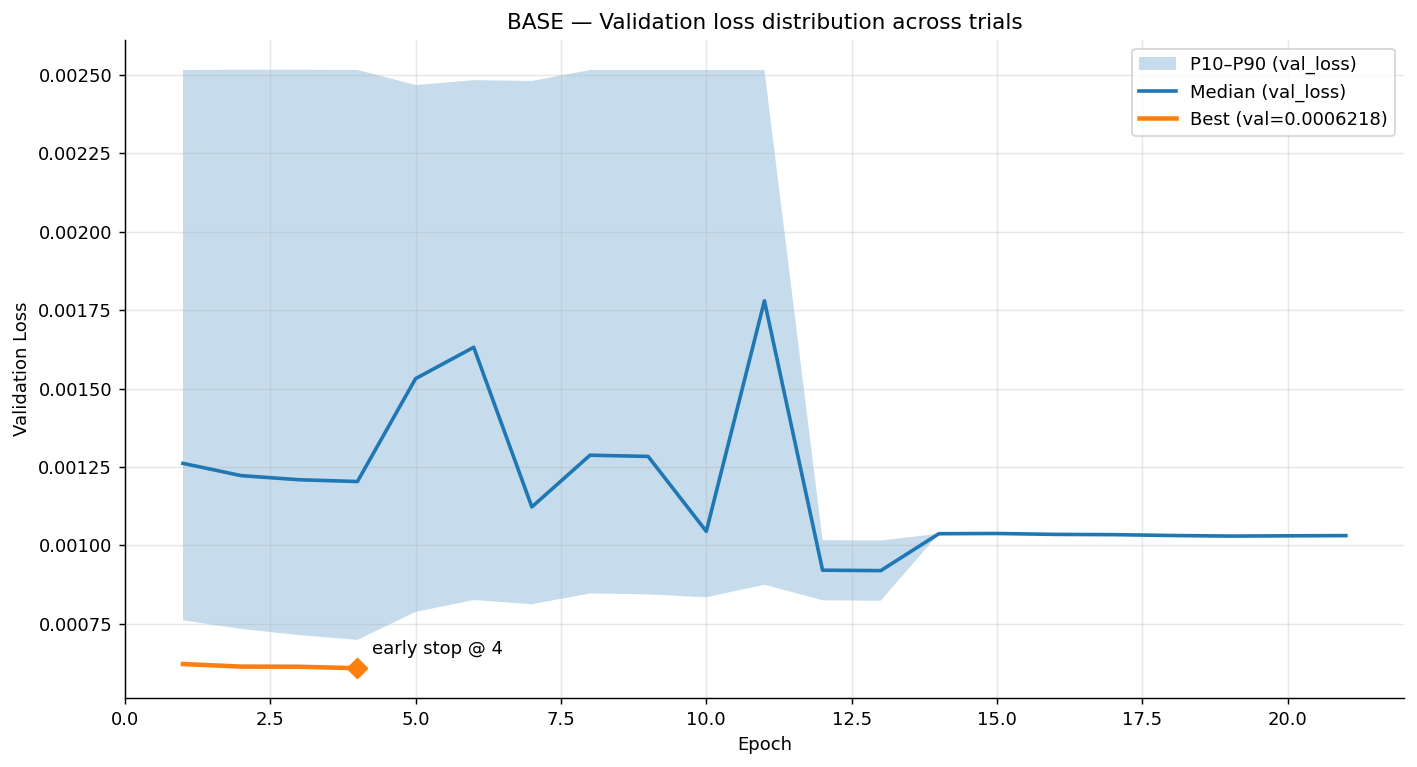

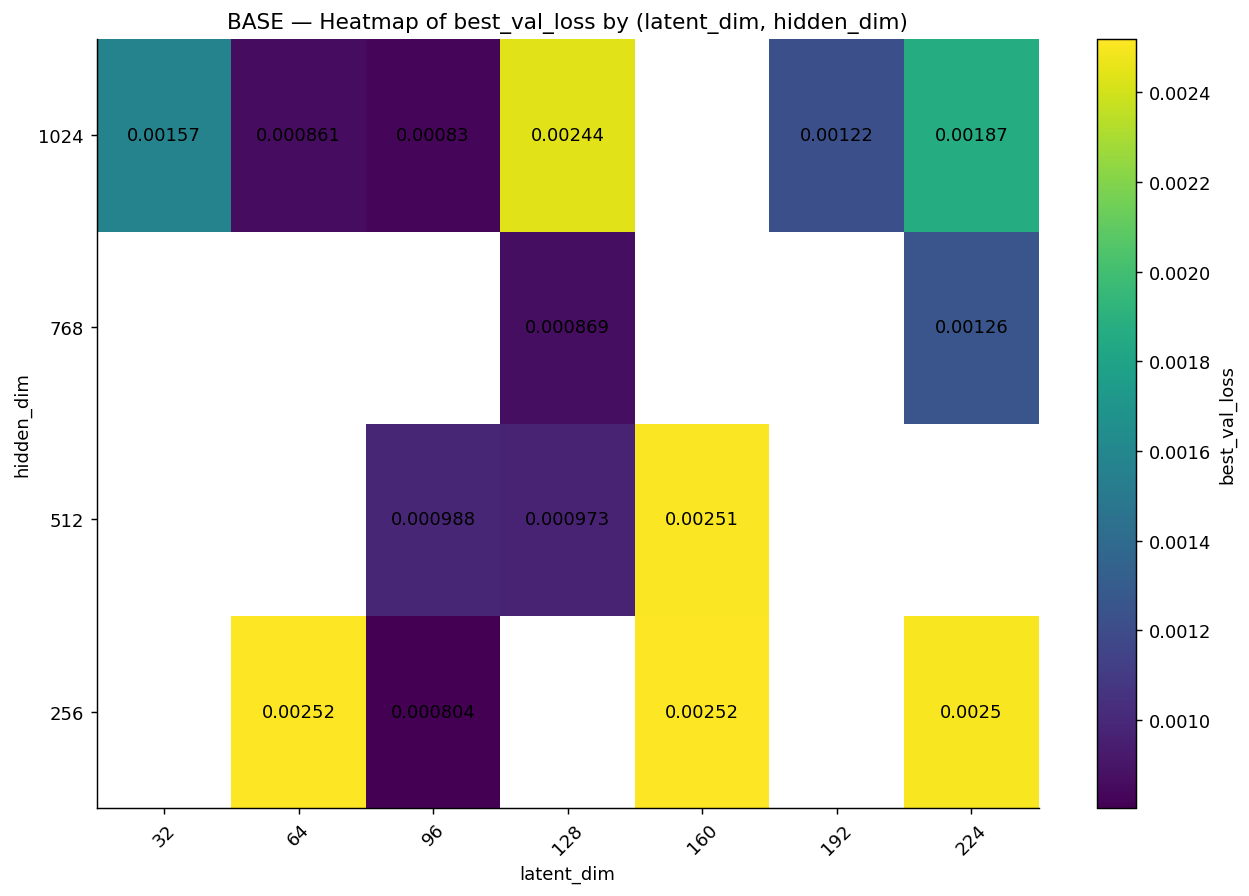

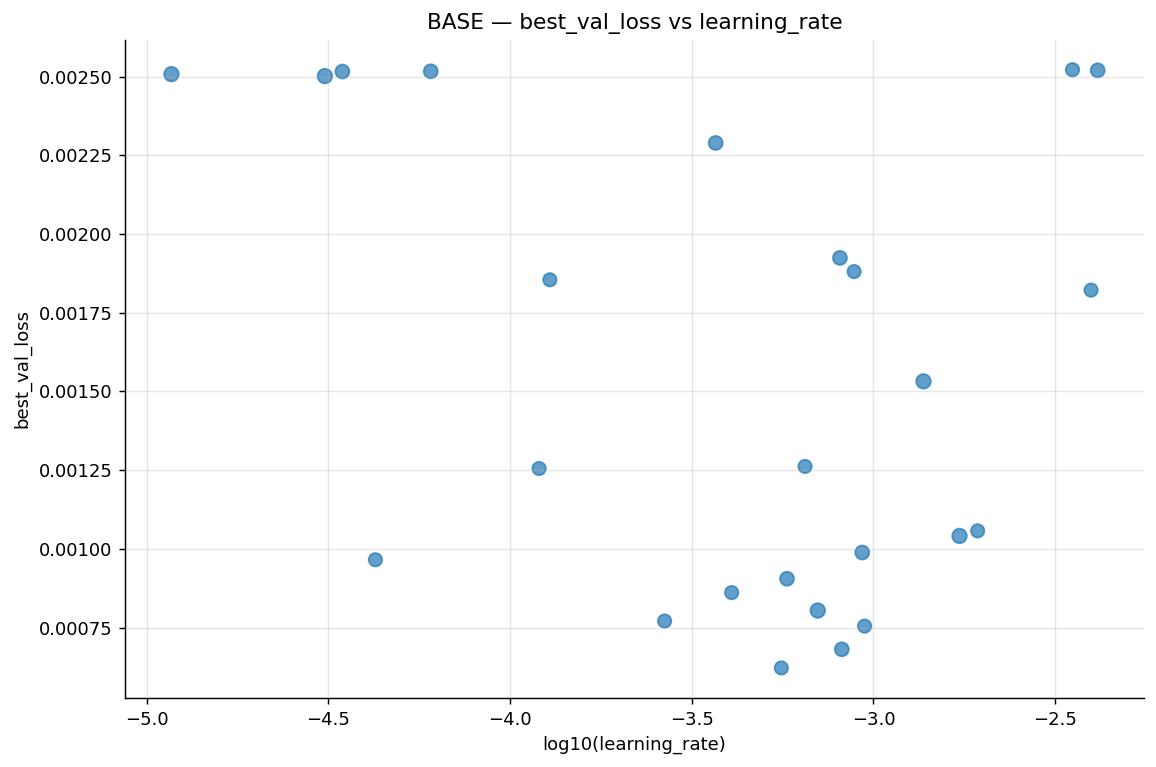

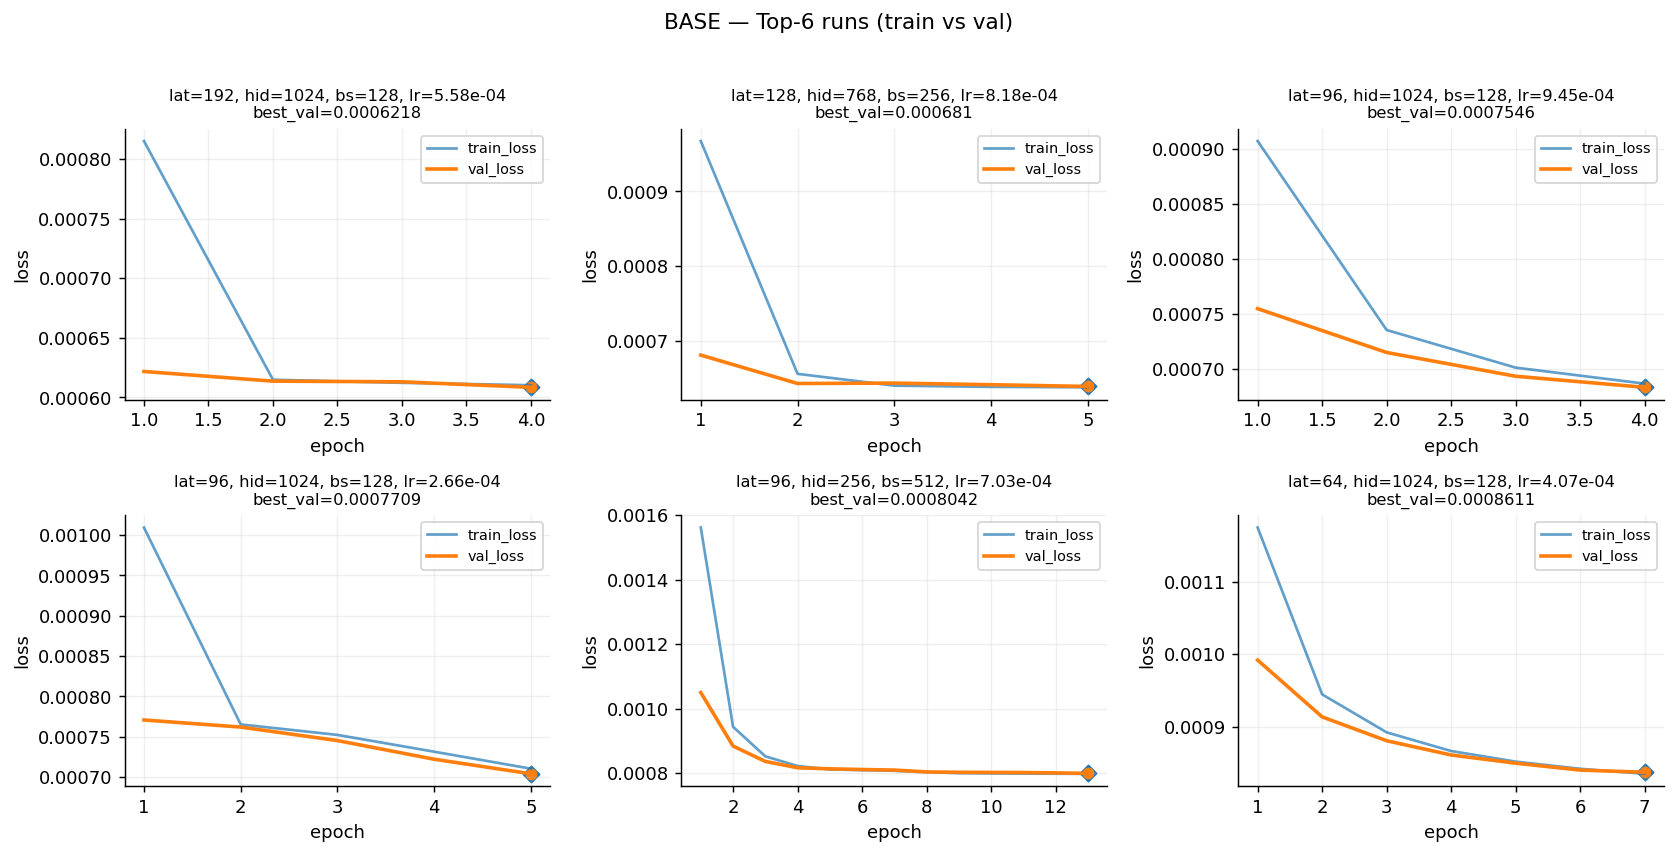

In [293]:
# ------------------------------ Run all --------------------------------------
# Example usage:
histories = load_histories("../models/history", model_key="base")
print(histories)
plot_val_loss_percentile_band(histories, model_label="BASE")
plot_best_val_heatmap(histories, x_key="latent_dim", y_key="hidden_dim", model_label="BASE")
plot_lr_vs_bestval(histories, model_label="BASE")
plot_small_multiples_topk(histories, top_k=6, model_label="BASE")



### CAE

candidates: {PosixPath('../models/history/cae_20250822_014349_t15_lat64_hid768_lr4.52064e-05_bs128_m0.09_tr0.0000_val0.0012.csv'), PosixPath('../models/history/cae_20250822_014349_t24_lat32_hid768_lr0.000349979_bs512_m0.06_tr0.0000_val0.0010.csv'), PosixPath('../models/history/cae_20250822_014349_t3_lat192_hid512_lr0.000253307_bs512_m0.47_tr0.0136_val0.0243.csv'), PosixPath('../models/history/cae_20250822_014349_t18_lat64_hid1024_lr0.00010318_bs128_m0.18_tr0.0012_val0.0026.csv'), PosixPath('../models/history/cae_20250822_014349_t13_lat32_hid1024_lr0.00298949_bs128_m0.11_tr0.0000_val0.0021.csv'), PosixPath('../models/history/cae_20250822_014349_t8_lat224_hid1024_lr7.21576e-05_bs512_m0.44_tr0.0103_val0.0202.csv'), PosixPath('../models/history/hpo_cae_20250822_014349.csv'), PosixPath('../models/history/cae_20250822_014349_t20_lat64_hid1024_lr0.000154111_bs256_m0.14_tr0.0004_val0.0017.csv'), PosixPath('../models/history/cae_20250822_014349_t9_lat96_hid768_lr0.000789636_bs256_m0.27_tr0.0000

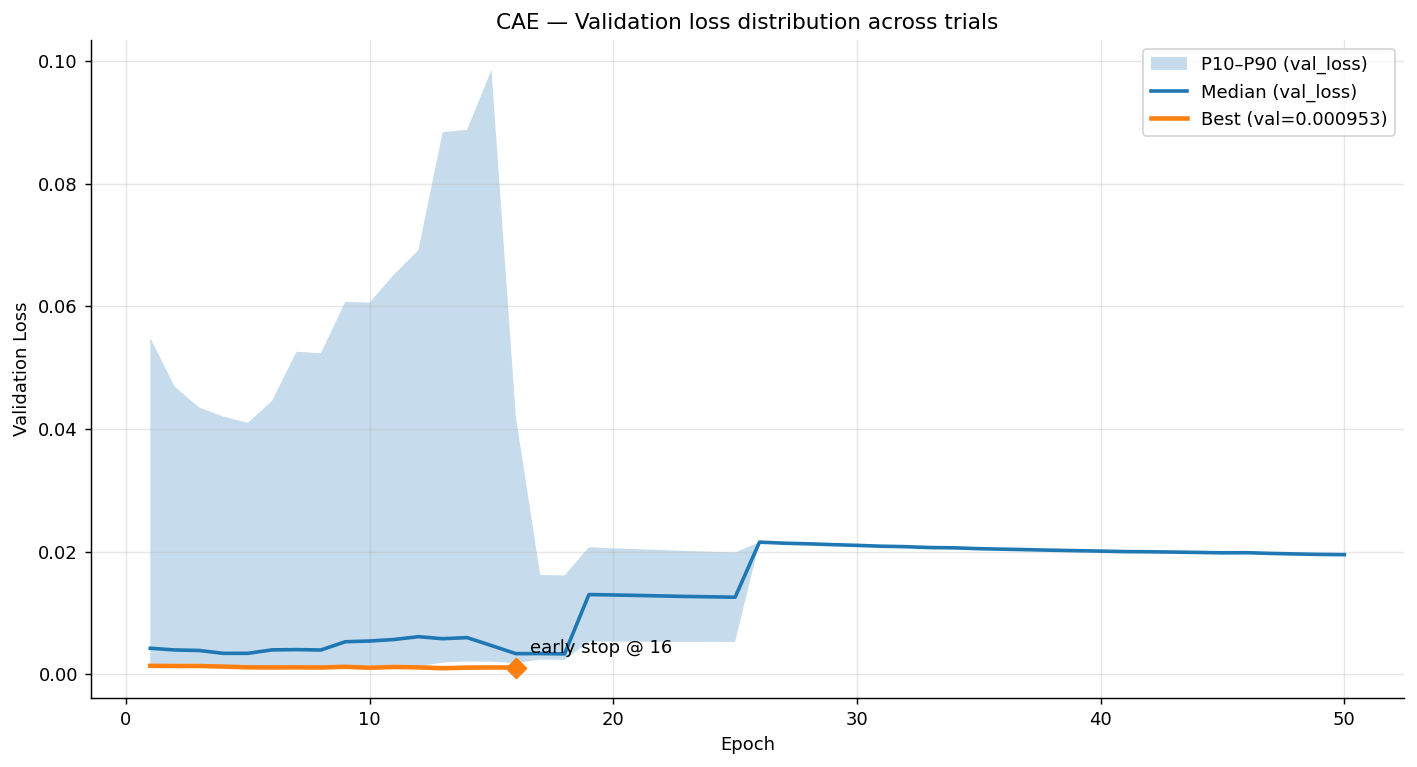

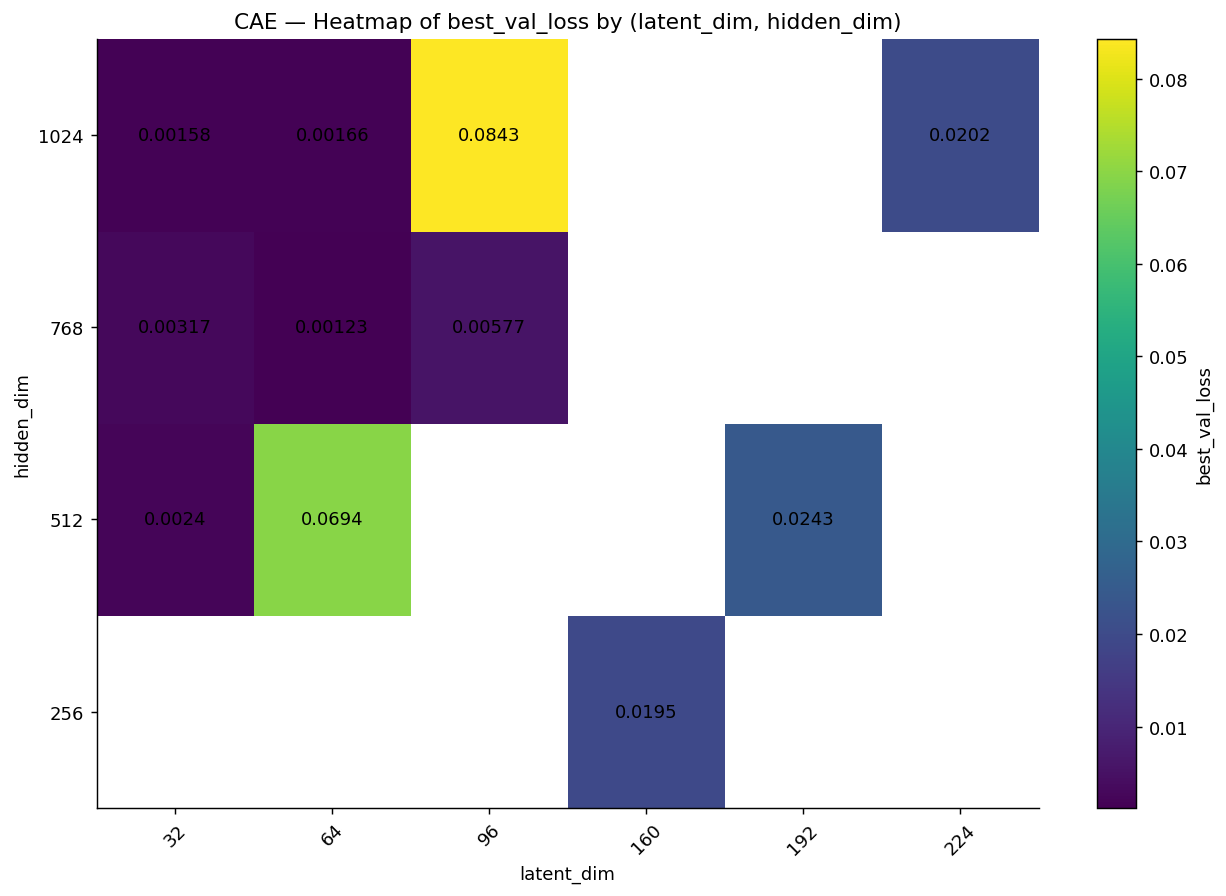

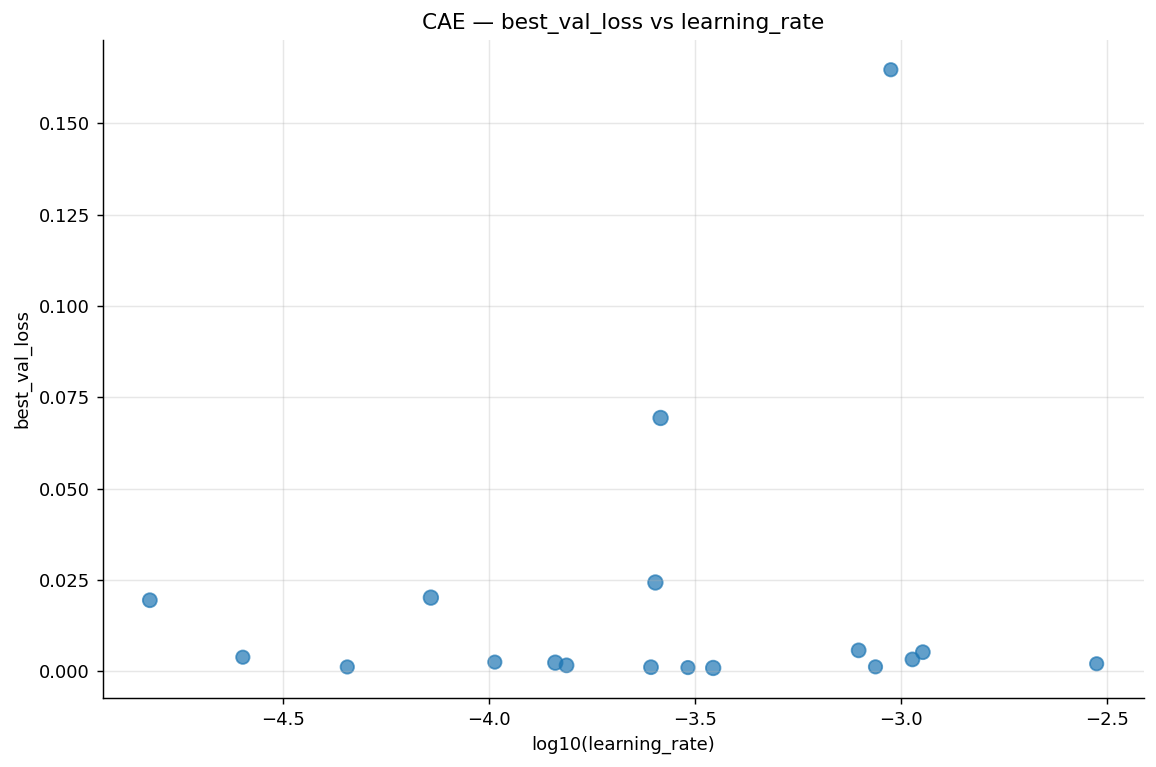

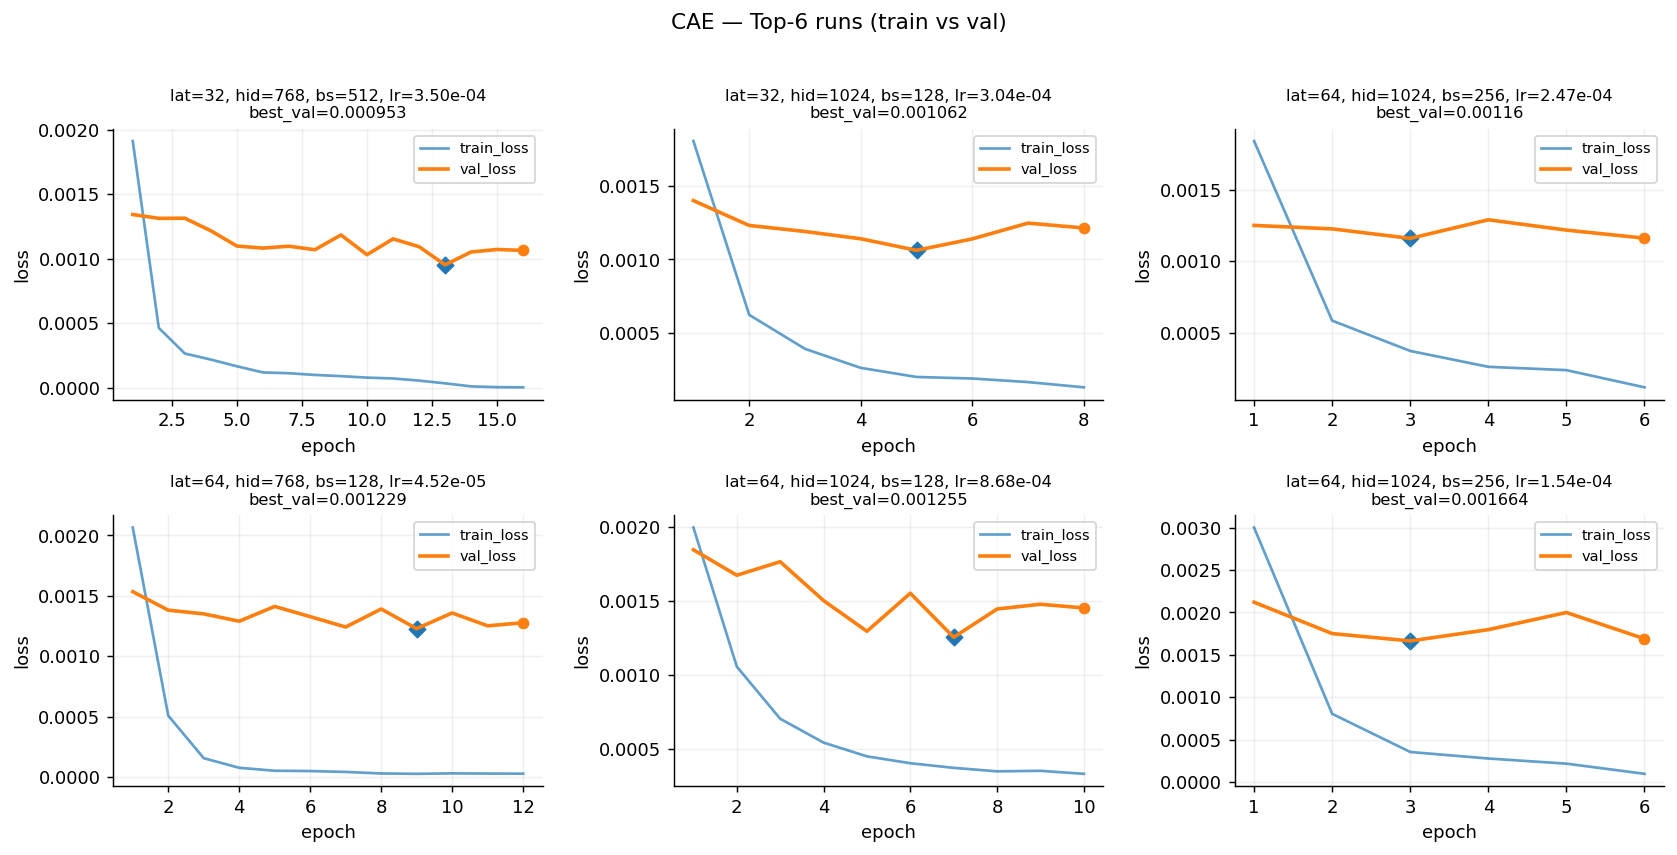

In [199]:
# ------------------------------ Run all --------------------------------------
# Example usage:
histories = load_histories("../models/history", model_key="cae")
print(histories)
plot_val_loss_percentile_band(histories, model_label="CAE")
plot_best_val_heatmap(histories, x_key="latent_dim", y_key="hidden_dim", model_label="CAE")
plot_lr_vs_bestval(histories, model_label="CAE")
plot_small_multiples_topk(histories, top_k=6, model_label="CAE")



### DAE

candidates: {PosixPath('../models/history/dae_20250822_012846_t7_lat96_hid512_lr0.000931505_bs256_tr0.0016_val0.0014.csv'), PosixPath('../models/history/dae_20250822_012846_t10_lat192_hid1024_lr0.000558009_bs128_tr0.0013_val0.0011.csv'), PosixPath('../models/history/dae_20250822_012846_t22_lat96_hid1024_lr4.26302e-05_bs128_tr0.0013_val0.0013.csv'), PosixPath('../models/history/dae_20250822_012846_t24_lat128_hid768_lr0.00081828_bs256_tr0.0014_val0.0012.csv'), PosixPath('../models/history/dae_20250822_012846_t0_lat96_hid1024_lr0.000945431_bs128_tr0.0013_val0.0012.csv'), PosixPath('../models/history/hpo_dae_dae_20250822_012846_retrieval.csv'), PosixPath('../models/history/dae_20250822_012846_t11_lat96_hid1024_lr0.000266354_bs128_tr0.0014_val0.0012.csv'), PosixPath('../models/history/hpo_dae_20250822_012846.csv'), PosixPath('../models/history/dae_20250822_012846_t17_lat128_hid512_lr0.000578267_bs256_tr0.0016_val0.0013.csv'), PosixPath('../models/history/dae_20250822_012846_t23_lat64_hid102

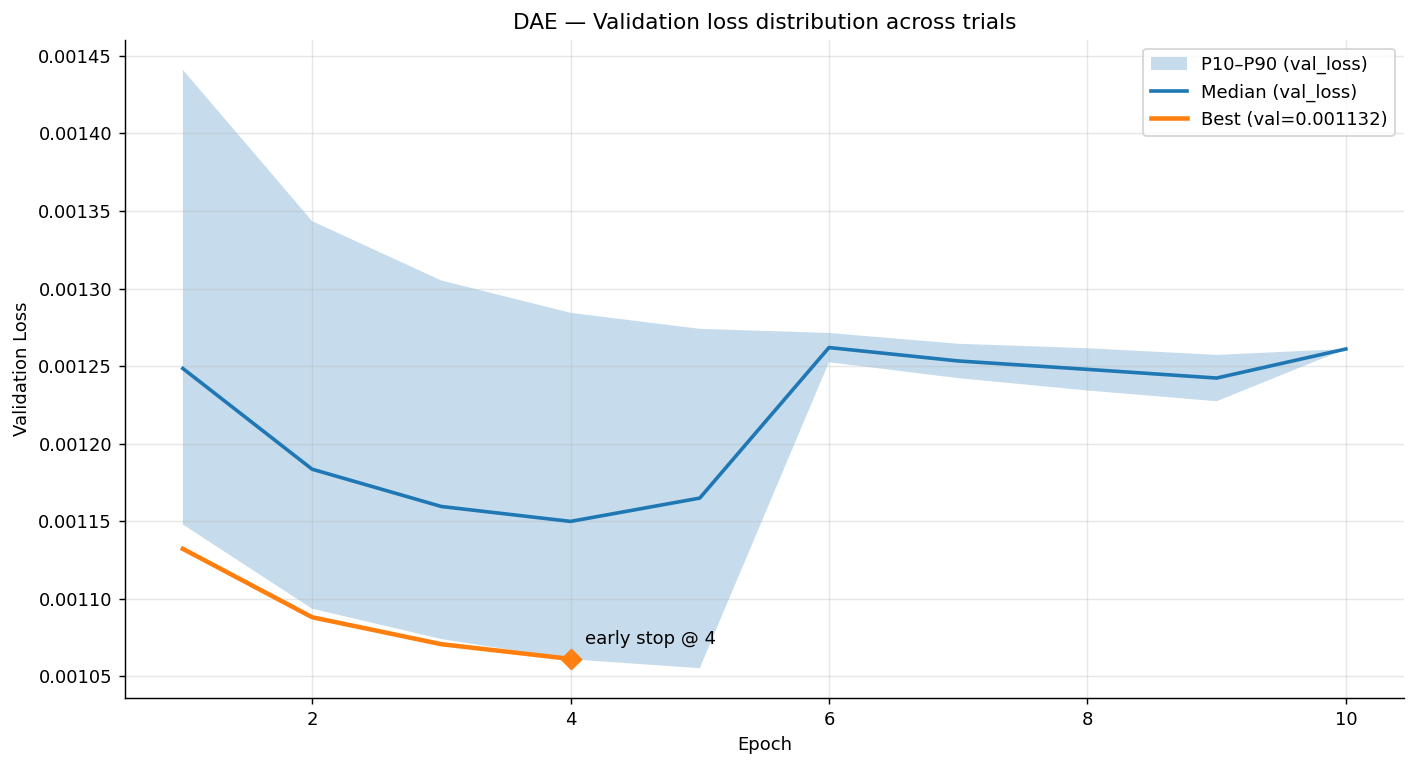

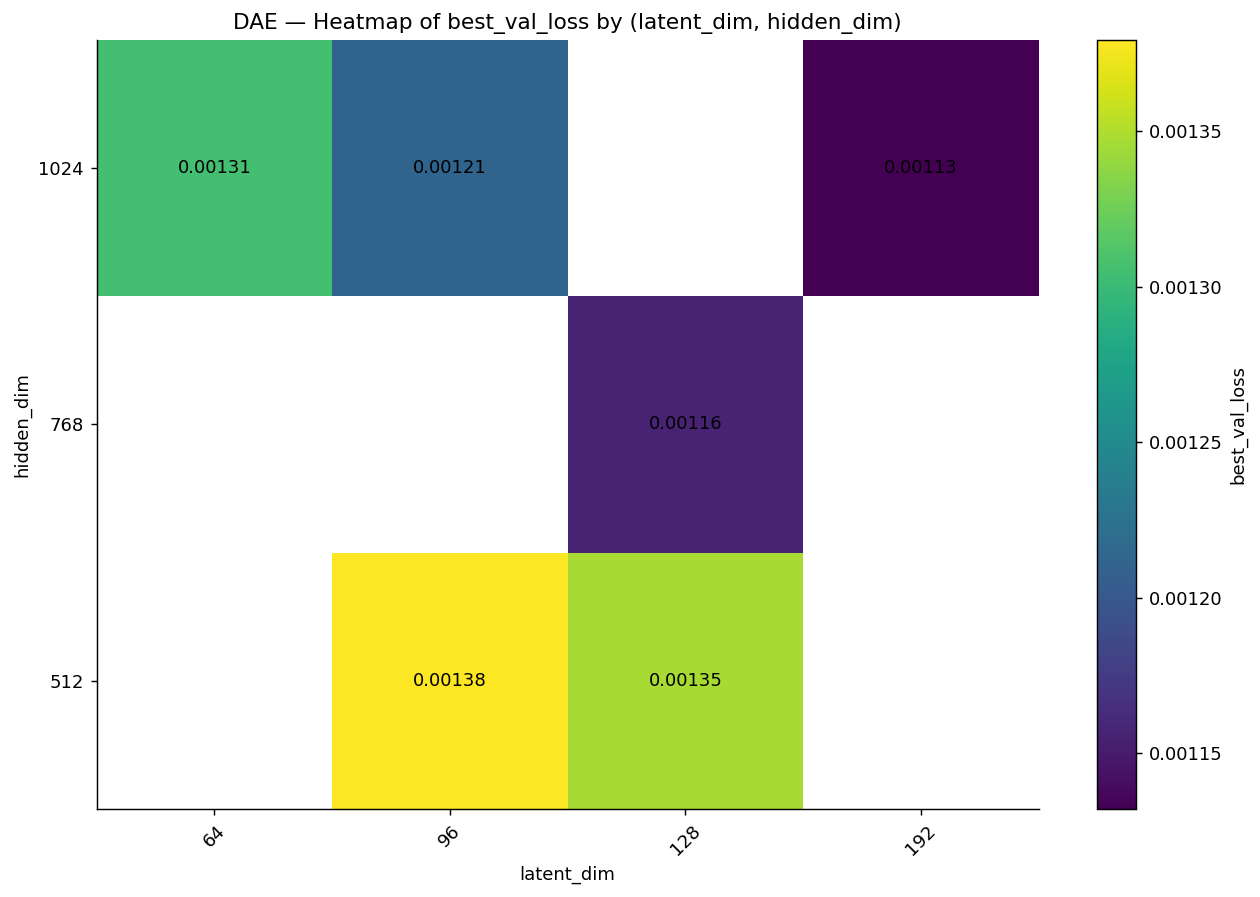

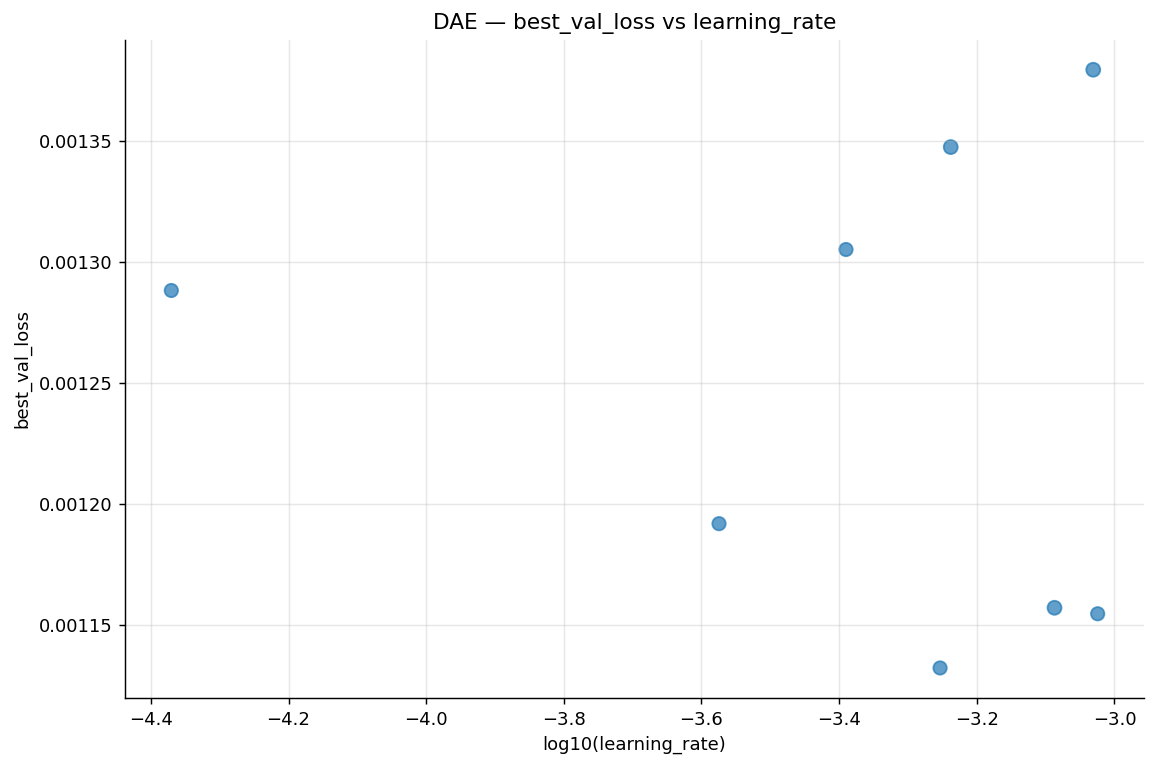

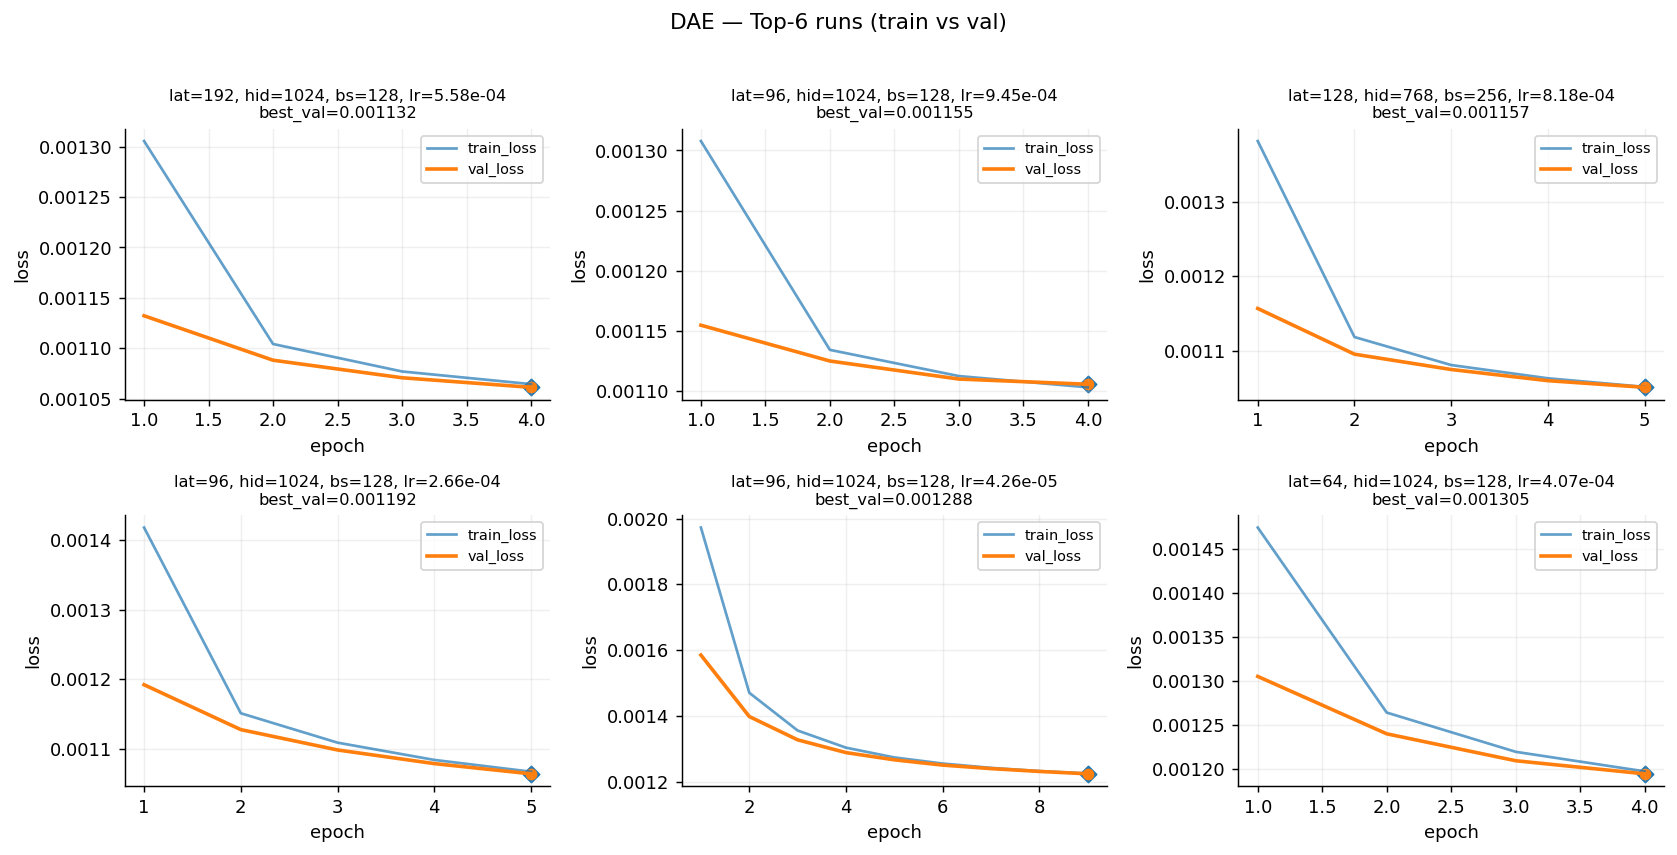

In [147]:
# ------------------------------ Run all --------------------------------------
# Example usage:
histories = load_histories("../models/history", model_key="dae")

plot_val_loss_percentile_band(histories, model_label="DAE")
plot_best_val_heatmap(histories, x_key="latent_dim", y_key="hidden_dim", model_label="DAE")
plot_lr_vs_bestval(histories, model_label="DAE")
plot_small_multiples_topk(histories, top_k=6, model_label="DAE")


### VAE

In [229]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes


def _ema(x: np.ndarray, alpha: float = 0.2) -> np.ndarray:
    """Return exponential moving average with smoothing factor alpha."""
    y = np.empty_like(x, dtype=float)
    if len(x) == 0:
        return y
    y[0] = x[0]
    for i in range(1, len(x)):
        if np.isnan(x[i]):
            y[i] = y[i - 1]
        else:
            y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y


def _align_epochs_component(
    dfs: List[pd.DataFrame],
    col: str,
) -> Tuple[np.ndarray, List[np.ndarray]]:
    """Align curves on a common epoch grid for a given column."""
    if not dfs:
        return np.array([]), []
    all_epochs = sorted({int(e) for df in dfs for e in df["epoch"].tolist()})
    curves: List[np.ndarray] = []
    for df in dfs:
        s = df.set_index("epoch").get(col)
        if s is None:
            s = pd.Series(np.nan, index=all_epochs)
        else:
            s = s.reindex(all_epochs)
        curves.append(s.to_numpy(dtype=float))
    return np.array(all_epochs), curves


def _select_best_idx(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    loss_tag: str = "best_val_loss",
) -> int:
    """Choose best trial by meta[loss_tag] or fallback to min val_loss in the curve."""
    vals: List[float] = []
    for df, meta, _ in histories:
        v = meta.get(loss_tag, np.nan)
        if pd.isna(v):
            v = df.get("val_loss", pd.Series([np.nan])).min(skipna=True)
        vals.append(float(v) if v is not None else np.nan)
    if all(np.isnan(vals)):
        return 0
    return int(np.nanargmin(vals))



def plot_vae_loss_decomposition_band(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    *,
    loss_tag: str = "best_val_loss",
    collapse_tau: float = 1e-2,
    use_log_kl: bool = True,
    ema_alpha: float = 0.2,
    show_beta: bool = True,
    zoom_first_n_epochs: Optional[int] = 10,
) -> None:
    """Plot percentile bands for val_recon and val_kl across VAE trials,
    adding KL-share, collapse shading, and beta overlay.

    Args:
        histories: List of (df, meta, csv_path) for VAE runs.
        loss_tag: Metadata key for best trial; falls back to min val_loss curve.
        collapse_tau: KL threshold to flag posterior collapse.
        use_log_kl: If True, plot KL panel with log1p scale.
        ema_alpha: EMA smoothing factor for percentile medians (visual only).
        show_beta: If True and available, overlay beta_current on KL panel (right y-axis).
        zoom_first_n_epochs: If set, add an inset zoom on the first N epochs (KL panel).
    """
    if not histories:
        print("No histories loaded.")
        return

    dfs = [h[0] for h in histories]

    # Align components
    epochs, recon_curves = _align_epochs_component(dfs, "val_recon")
    _, kl_curves = _align_epochs_component(dfs, "val_kl")

    if len(epochs) == 0:
        print("No epochs to plot.")
        return

    R = np.vstack(recon_curves)  # [n_trials, n_epochs]
    K = np.vstack(kl_curves)

    # Percentiles
    recon_p10, recon_p50, recon_p90 = (np.nanpercentile(R, q, axis=0) for q in (10, 50, 90))
    kl_p10, kl_p50, kl_p90 = (np.nanpercentile(K, q, axis=0) for q in (10, 50, 90))

    # EMA smoothing for display
    recon_p50_s = _ema(recon_p50, alpha=ema_alpha)
    kl_p50_s = _ema(kl_p50, alpha=ema_alpha)

    # KL-share percentiles
    share = K / np.clip(R + K, 1e-12, None)
    share_p10, share_p50, share_p90 = (np.nanpercentile(share, q, axis=0) for q in (10, 50, 90))
    share_p50_s = _ema(share_p50, alpha=ema_alpha)

    # Best trial
    best_idx = _select_best_idx(histories, loss_tag=loss_tag)
    best_df = histories[best_idx][0]
    best_meta = histories[best_idx][1]

    fig = plt.figure(figsize=(16, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1])
    ax_recon: Axes = fig.add_subplot(gs[0, 0])
    ax_kl: Axes = fig.add_subplot(gs[0, 1])
    ax_share: Axes = fig.add_subplot(gs[0, 2])

    # --- Panel A: Reconstruction ---
    ax_recon.fill_between(epochs, recon_p10, recon_p90, alpha=0.2, label="P10–P90 (val_recon)")
    ax_recon.plot(epochs, recon_p50_s, lw=2, label="Median EMA (val_recon)")
    if "val_recon" in best_df:
        ax_recon.plot(best_df["epoch"], best_df["val_recon"], lw=2.4,
                      label=f"Best trial (val={best_meta.get(loss_tag, np.nan):.4g})")
    ax_recon.set_title("Validation reconstruction loss")
    ax_recon.set_xlabel("Epoch")
    ax_recon.set_ylabel("Loss")
    ax_recon.grid(alpha=0.3)
    ax_recon.legend(frameon=False)

    # --- Panel B: KL divergence ---
    # Collapse shading (where median KL below tau)
    below = (kl_p50 <= collapse_tau)
    if np.any(below):
        # find contiguous regions
        starts = np.where(np.diff(np.pad(below.astype(int), (1, 1))) == 1)[0]
        ends = np.where(np.diff(np.pad(below.astype(int), (1, 1))) == -1)[0]
        for s, e in zip(starts, ends):
            ax_kl.axvspan(epochs[s], epochs[e - 1], color="tab:red", alpha=0.08)

    ax_kl.fill_between(epochs, kl_p10, kl_p90, alpha=0.2, label="P10–P90 (val_kl)")
    ax_kl.plot(epochs, kl_p50_s, lw=2, label="Median EMA (val_kl)")
    if "val_kl" in best_df:
        ax_kl.plot(best_df["epoch"], best_df["val_kl"], lw=2.4,
                   label=f"Best trial (val={best_meta.get(loss_tag, np.nan):.4g})")

    if use_log_kl:
        ax_kl.set_yscale("log", base=10)
        # robust lower bound to avoid log(0)
        ymin = max(1e-4, np.nanmin(kl_p10) * 0.5)
        ymax = np.nanmax(kl_p90) * 1.1
        ax_kl.set_ylim(ymin, ymax)

    ax_kl.axhline(collapse_tau, ls="--", lw=1, color="tab:red", alpha=0.6, label=f"Collapse τ={collapse_tau:g}")
    ax_kl.set_title("Validation KL divergence")
    ax_kl.set_xlabel("Epoch")
    ax_kl.set_ylabel("Loss")
    ax_kl.grid(alpha=0.3)

    # Overlay beta on right axis (if present)
    if show_beta and "beta_current" in best_df.columns:
        ax_beta = ax_kl.twinx()
        ax_beta.plot(best_df["epoch"], best_df["beta_current"], lw=1.8, alpha=0.8, color="tab:purple", label="β (best)")
        ax_beta.set_ylabel("β (right)")
        # Merge legends
        lines, labels = ax_kl.get_legend_handles_labels()
        lines2, labels2 = ax_beta.get_legend_handles_labels()
        ax_kl.legend(lines + lines2, labels + labels2, frameon=False, loc="best")
    else:
        ax_kl.legend(frameon=False, loc="best")

    # Optional inset zoom for first N epochs
    if zoom_first_n_epochs:
        n = int(zoom_first_n_epochs)
        sub = epochs <= (epochs[0] + n - 1)
        if np.any(sub):
            axins = ax_kl.inset_axes([0.40, 0.40, 0.4, 0.45])
            axins.fill_between(epochs[sub], kl_p10[sub], kl_p90[sub], alpha=0.2)
            axins.plot(epochs[sub], kl_p50_s[sub], lw=2)
            if "val_kl" in best_df:
                axins.plot(best_df["epoch"][best_df["epoch"] <= epochs[sub][-1]],
                           best_df["val_kl"][best_df["epoch"] <= epochs[sub][-1]], lw=2.0)
            if use_log_kl:
                axins.set_yscale("log", base=10)
            ax_kl.indicate_inset_zoom(axins, edgecolor="gray")

    # --- Panel C: KL-share ---
    ax_share.fill_between(epochs, share_p10, share_p90, alpha=0.2, label="P10–P90 (KL-share)")
    ax_share.plot(epochs, share_p50_s, lw=2, label="Median EMA (KL-share)")
    if {"val_recon", "val_kl"}.issubset(best_df.columns):
        share_best = best_df["val_kl"] / np.clip(best_df["val_kl"] + best_df["val_recon"], 1e-12, None)
        ax_share.plot(best_df["epoch"], share_best, lw=2.4, label="Best trial (KL-share)")
    ax_share.set_title("KL share (KL / (Recon + KL))")
    ax_share.set_xlabel("Epoch")
    ax_share.set_ylabel("Proportion")
    ax_share.set_ylim(0.0, 1.0)
    ax_share.grid(alpha=0.3)
    ax_share.legend(frameon=False)

    plt.suptitle("VAE loss decomposition across trials (with β, collapse and KL-share)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ---- Optional: concise diagnostics in stdout ----
    collapse_ratio = np.mean(kl_p50 <= collapse_tau)
    print(f"[Diagnostics] Epochs with median KL below τ={collapse_tau:g}: {collapse_ratio*100:.1f}%")


candidates: {PosixPath('../models/history/vae_20250824_183805_t15_lat160_hid768_lr0.000110748_bs128_b2.00_beta1.996994614931723_trRef0.5896_valRef0.4682.csv'), PosixPath('../models/history/vae_20250824_183805_t24_lat224_hid768_lr0.00373207_bs512_b1.81_beta1.8068276805796815_trRef0.4957_valRef0.4183.csv'), PosixPath('../models/history/hpo_vae_vae_20250824_183805_retrieval.csv'), PosixPath('../models/history/vae_20250824_183805_t16_lat192_hid1024_lr0.00127812_bs128_b1.80_beta1.8043093178756782_trRef0.5316_valRef0.4555.csv'), PosixPath('../models/history/vae_20250824_183805_t20_lat192_hid512_lr6.35037e-05_bs128_b1.57_beta1.5670717189113283_trRef0.5093_valRef0.4219.csv'), PosixPath('../models/history/vae_20250824_183805_t0_lat96_hid1024_lr0.000945431_bs128_b1.80_beta1.7992642186624028_trRef0.5891_valRef0.4979.csv'), PosixPath('../models/history/hpo_vae_20250824_183805.csv')}
Skipping hpo_vae_20250824_183805.csv: missing JSON metadata
Skipping hpo_vae_vae_20250824_183805_retrieval.csv: miss

[(    epoch  beta_current        lr  train_loss_oper  train_loss_ref  \
  0       1      0.000000  0.000945         0.229555        9.114776   
  1       2      0.359853  0.000945         0.483808        1.229712   
  2       3      0.719706  0.000945         0.536484        0.784988   
  3       4      1.079559  0.000945         0.581747        0.690184   
  4       5      1.439411  0.000945         0.612427        0.652821   
  5       6      1.799264  0.000945         0.639172        0.639172   
  6       7      1.799264  0.000945         0.632707        0.632707   
  7       8      1.799264  0.000945         0.628095        0.628095   
  8       9      1.799264  0.000945         0.624391        0.624391   
  9      10      1.799264  0.000650         0.618993        0.618993   
  10     11      1.799264  0.000650         0.615932        0.615932   
  11     12      1.799264  0.000650         0.614318        0.614318   
  12     13      1.799264  0.000447         0.610248        0.61

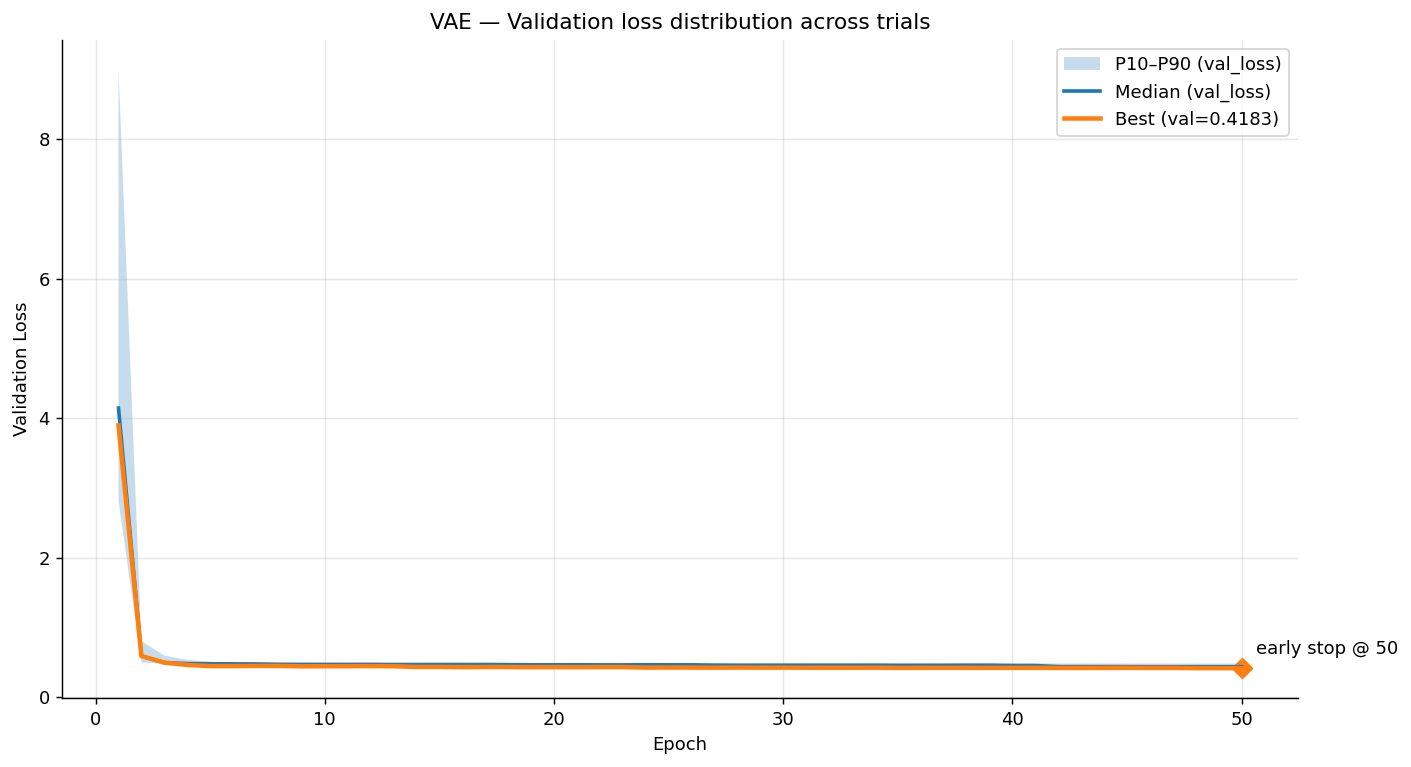

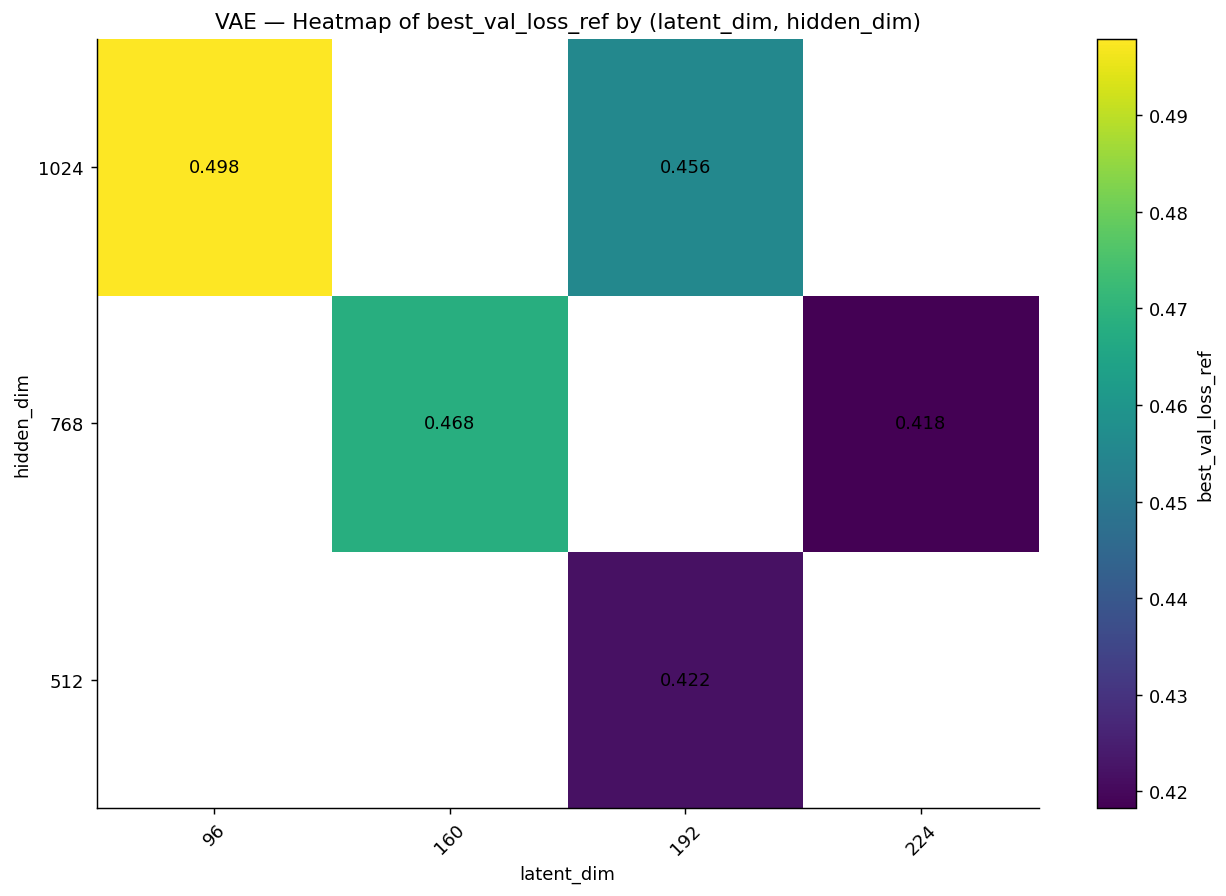

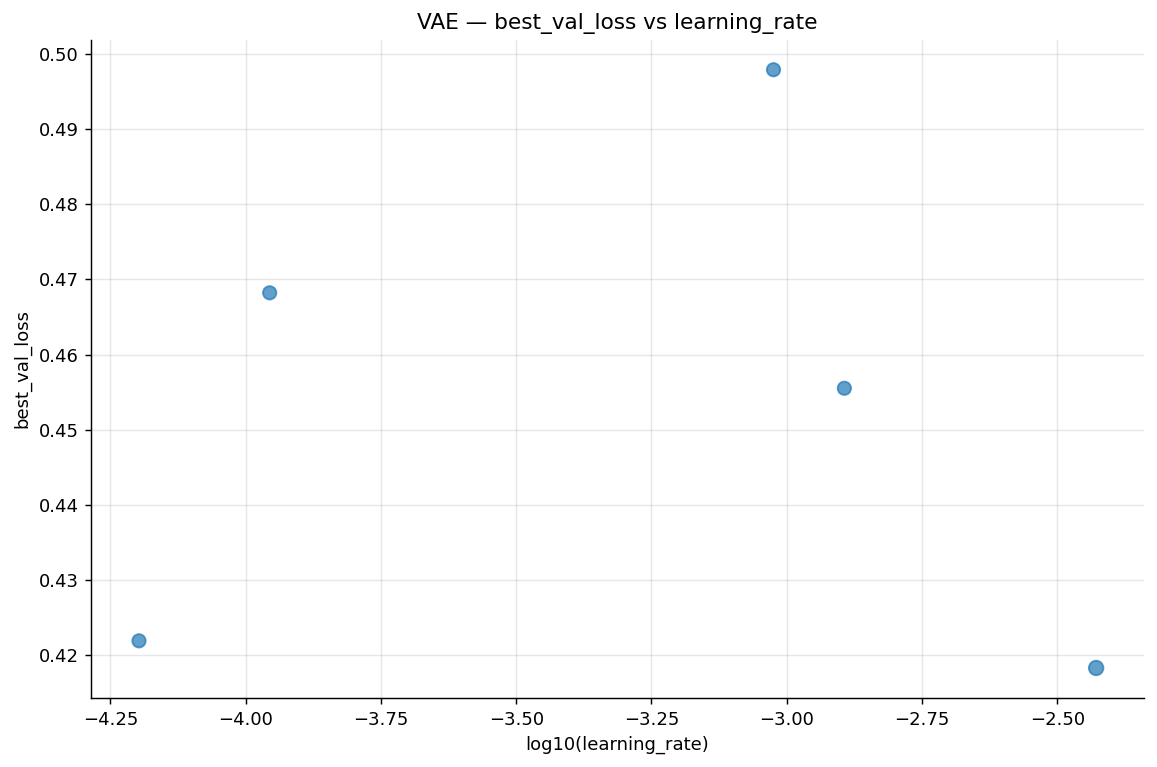

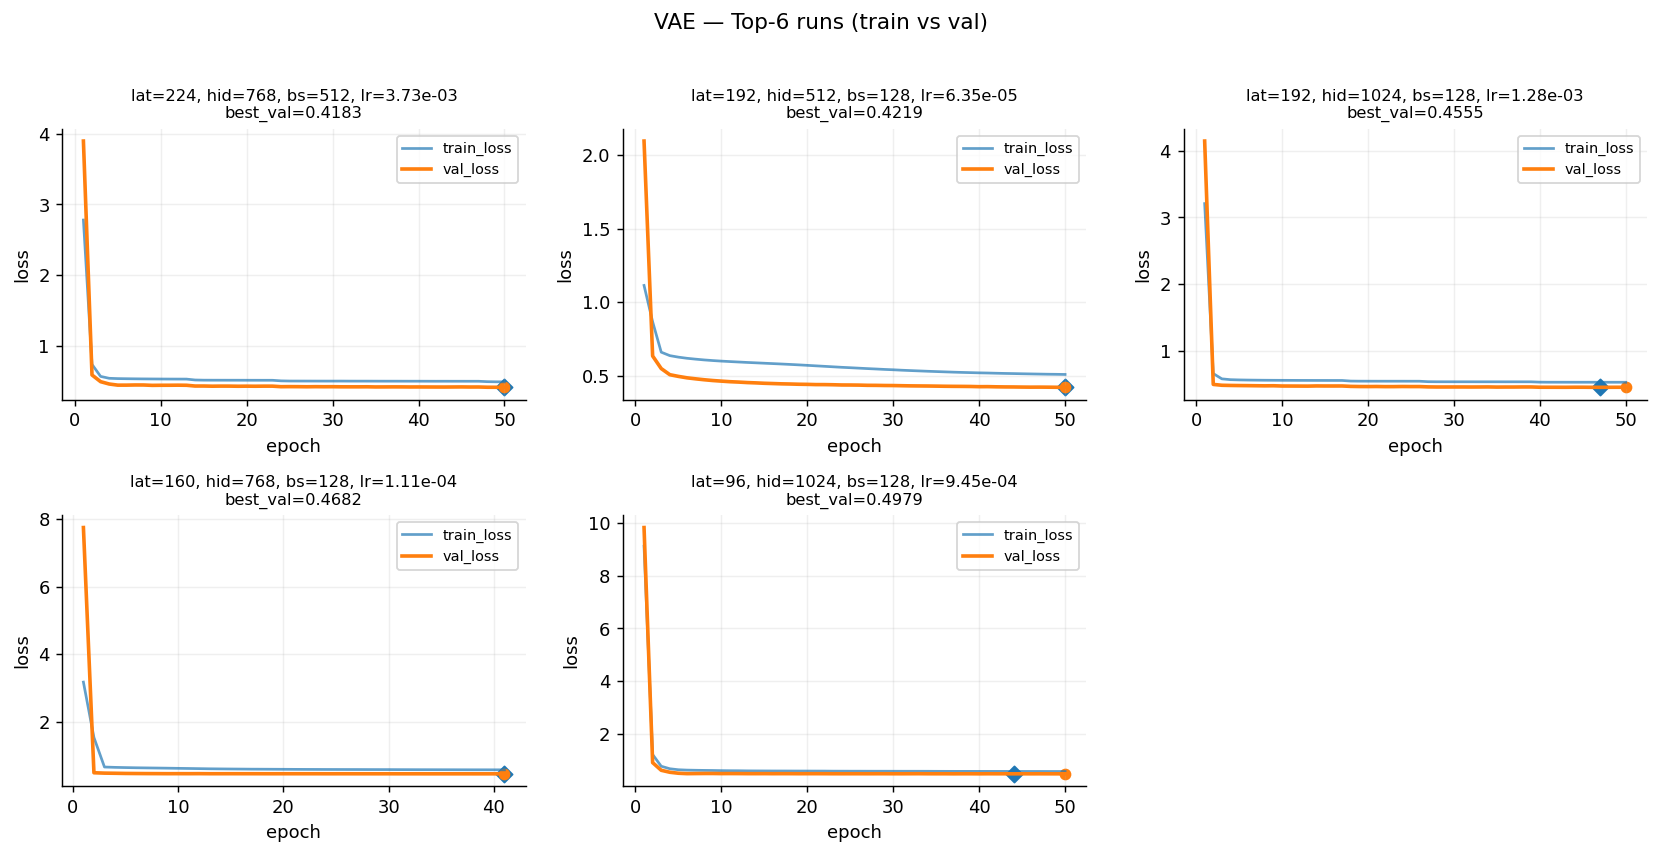

In [232]:
# ------------------------------ Run all --------------------------------------
# Example usage:
histories = load_histories("../models/history/", model_key="vae")
display(histories)
plot_val_loss_percentile_band(histories, model_label="VAE", loss_tag="best_val_loss_ref")
plot_best_val_heatmap(histories, x_key="latent_dim", y_key="hidden_dim", model_label="VAE", agg="best_val_loss_ref")
plot_lr_vs_bestval(histories, model_label="VAE", loss_tags="best_val_loss_ref")
plot_small_multiples_topk(histories, top_k=6, model_label="VAE", loss_tags="best_val_loss_ref")



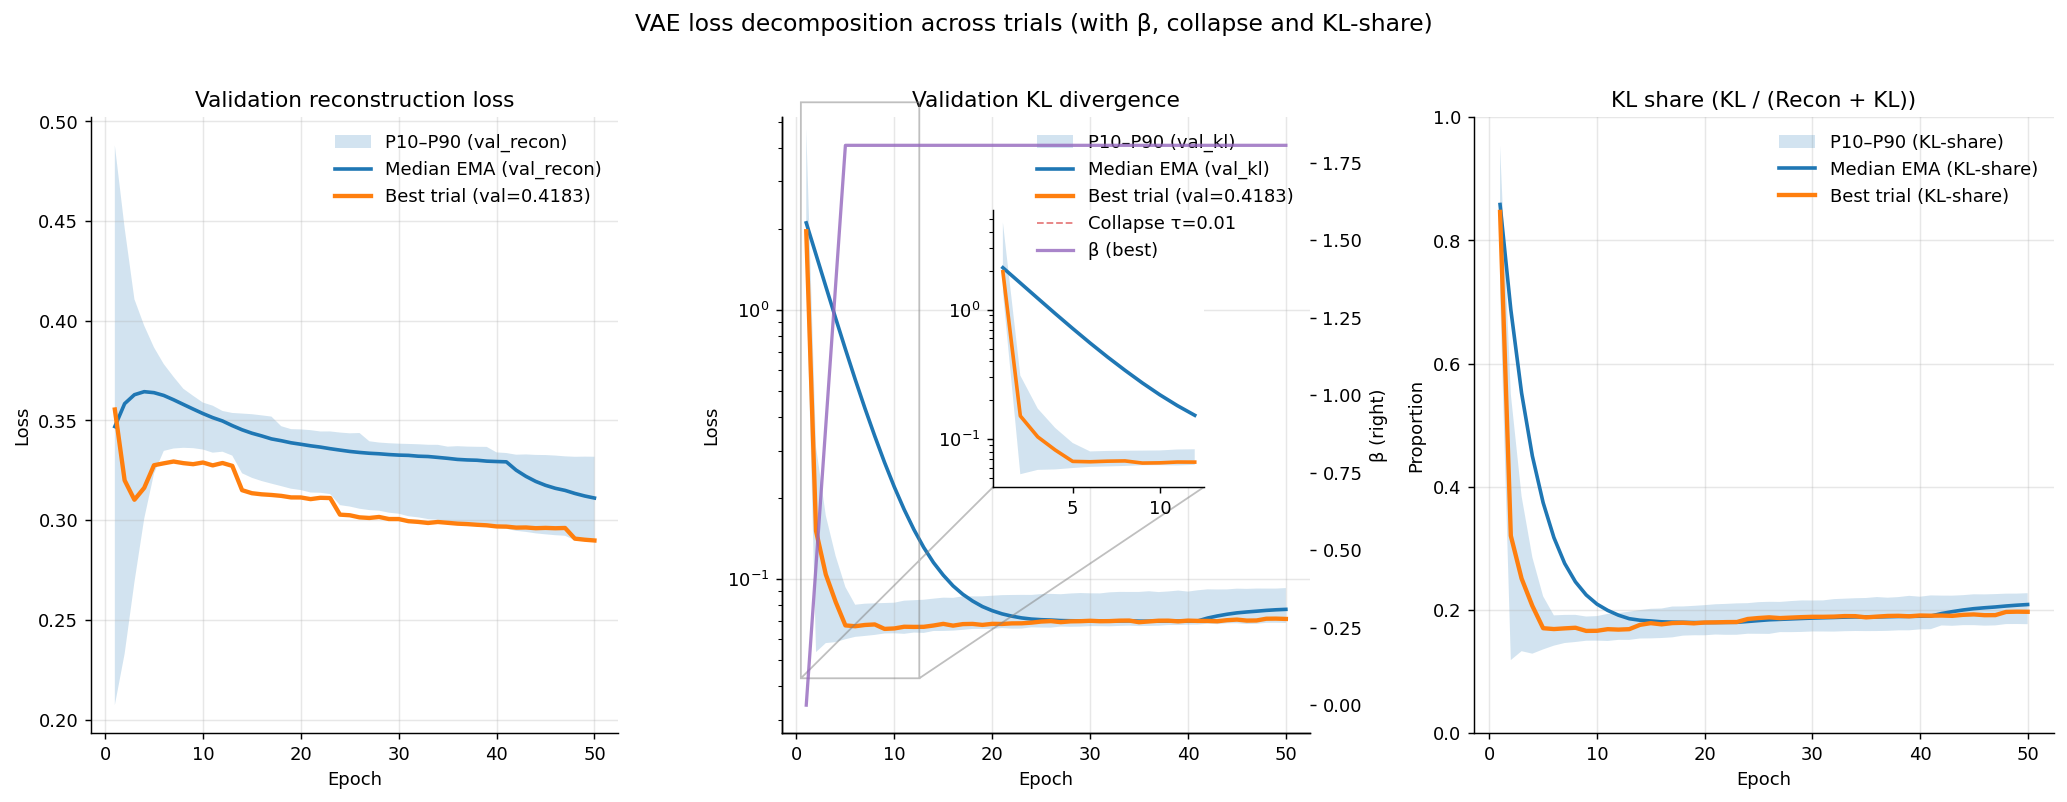

[Diagnostics] Epochs with median KL below τ=0.01: 0.0%


In [230]:

plot_vae_loss_decomposition_band(
    histories,
    use_log_kl=True,          # KL en escala log
    zoom_first_n_epochs=12,   # inset visible
    show_beta=True,           # superponer β si existe
    collapse_tau=1e-2,        # umbral de colapso
    ema_alpha=0.25,           # suavizado visual
    loss_tag="best_val_loss_ref"
)


## Hyperparameters

In [406]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold


# ------------------------------- Loading ------------------------------------ #
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd


def _safe_float(x: Any) -> float:
    try:
        return float(x)
    except Exception:
        return np.nan


def _parse_tokens_from_name(name: str) -> Dict[str, float]:
    """Best-effort: parse tokens like lat96_hid1024_lr0.0009_bs128_m0.44_val0.1647."""
    pats = {
        "latent_dim": r"lat(\d+)",
        "hidden_dim": r"hid(\d+)",
        "batch_size": r"bs(\d+)",
        "lr":         r"lr([0-9eE\.\-]+)",
        "margin":     r"(?:_m|_margin)([0-9eE\.\-]+)",
        "beta":       r"(?:_beta|_b)([0-9eE\.\-]+)",
        "val_loss":   r"_val([0-9eE\.\-]+)",
    }
    out: Dict[str, float] = {}
    for k, pat in pats.items():
        m = re.search(pat, name)
        if m:
            out[k] = _safe_float(m.group(1))
    return out


def _read_json_flat(p: Path) -> Dict[str, Any]:
    """Read a JSON and flatten nested dicts with dotted keys."""
    with open(p, "r") as f:
        data = json.load(f)
    flat: Dict[str, Any] = {}

    def rec(prefix: str, d: Dict[str, Any]) -> None:
        for k, v in d.items():
            key = f"{prefix}{k}" if prefix else k
            if isinstance(v, dict):
                rec(f"{key}.", v)
            else:
                flat[key] = v

    if isinstance(data, dict):
        rec("", data)
    return flat


def gather_trials_from_history(
    history_dir: str | Path,
    model_key: str,
    hpo_csv_glob: Optional[str] = None,
) -> pd.DataFrame:
    """Load trials from hpo_* CSVs and {model_key}_*.json, unify target as 'val_loss'.

    - CSV hpo_*: usa directamente columnas (value -> val_loss; hiperparámetros como batch_size, latent_dim, etc.).
    - JSON: intenta 'best_val_loss' o 'value' y extrae hiperparámetros; hace fallback a tokens en el nombre.
    """
    root = Path(history_dir)
    rows: List[Dict[str, Any]] = []

    # ---- 2.1 CSV hpo_* (fuente primaria si existe) ----
    if hpo_csv_glob:
        for p in sorted(root.glob(hpo_csv_glob)):
            try:
                dfc = pd.read_csv(p)
            except Exception:
                continue
            # Normaliza nombres
            dfc.columns = [str(c).strip().lower() for c in dfc.columns]
            # Alias de target
            if "val_loss" not in dfc.columns and "value" in dfc.columns:
                dfc = dfc.rename(columns={"value": "val_loss"})

            # Tipos básicos
            for c in dfc.columns:
                if c not in {"state", "ckpt", "duration"}:
                    dfc[c] = pd.to_numeric(dfc[c], errors="ignore")

            # Convierte booleanos a {0,1}
            if "hard_negatives" in dfc.columns:
                dfc["hard_negatives"] = dfc["hard_negatives"].astype(str).str.lower().map(
                    {"true": 1, "false": 0}
                ).fillna(dfc["hard_negatives"]).astype(float, errors="ignore")

            # Extrae tokens desde ckpt si faltan
            if "ckpt" in dfc.columns:
                parsed = dfc["ckpt"].astype(str).apply(lambda s: _parse_tokens_from_name(Path(s).stem))
                toks = pd.DataFrame(parsed.tolist())
                for col in ["latent_dim", "hidden_dim", "batch_size", "lr", "margin", "beta", "val_loss"]:
                    if col in toks.columns and (col not in dfc.columns or dfc[col].isna().all()):
                        dfc[col] = dfc[col] if col in dfc.columns else toks[col]

            # Selecciona columnas útiles
            keep = [
                "val_loss", "number", "trial", "batch_size", "hidden_dim", "latent_dim",
                "lr", "weight_decay", "margin", "beta", "hard_negatives", "scheduler_factor",
                "scheduler_patience", "early_stop_delta", "max_grad_norm", "ckpt"
            ]
            rec = dfc[[c for c in keep if c in dfc.columns]].copy()
            rec["source"] = str(p.name)
            rows.extend(rec.to_dict(orient="records"))

    # ---- 2.2 JSON por trial (complemento) ----
    for j in sorted(root.glob(f"{model_key}_*.json")):
        flat = {}
        try:
            flat = _read_json_flat(j)
        except Exception:
            pass

        # tokens del nombre
        toks = _parse_tokens_from_name(j.stem)

        # objetivo
        val = flat.get("best_val_loss", np.nan)
        if math.isnan(_safe_float(val)):
            val = flat.get("value", np.nan)
        if math.isnan(_safe_float(val)):
            val = toks.get("val_loss", np.nan)

        row: Dict[str, Any] = {
            "val_loss": _safe_float(val),
            "latent_dim": _safe_float(flat.get("latent_dim", toks.get("latent_dim", np.nan))),
            "hidden_dim": _safe_float(flat.get("hidden_dim", toks.get("hidden_dim", np.nan))),
            "batch_size": _safe_float(flat.get("batch_size", toks.get("batch_size", np.nan))),
            "lr": _safe_float(flat.get("lr", toks.get("lr", np.nan))),
            "weight_decay": _safe_float(flat.get("weight_decay", np.nan)),
            "margin": _safe_float(flat.get("margin", toks.get("margin", np.nan))),
            "beta": _safe_float(flat.get("beta", toks.get("beta", np.nan))),
            "trial_id": _safe_float(flat.get("trial", flat.get("number", np.nan))),
            "json_path": str(j),
            "source": j.name,
        }
        rows.append(row)

    # ---- 2.3 Unificación y *feature engineering* ----
    if not rows:
        return pd.DataFrame(columns=["val_loss"])  # vacío pero coherente

    df = pd.DataFrame(rows)

    # Tipos numéricos
    for c in df.columns:
        if c not in {"source", "json_path", "ckpt"}:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Target
    if "val_loss" not in df.columns:
        raise ValueError("No target metric found: expected 'val_loss' or 'value' in sources.")

    df = df.dropna(subset=["val_loss"]).reset_index(drop=True)

    # Log-features
    if "lr" in df.columns:
        df["log10_lr"] = np.log10(df["lr"].clip(lower=1e-12))
    if "weight_decay" in df.columns:
        df["log10_wd"] = np.log10(df["weight_decay"].clip(lower=1e-12))

    # Booleanos → {0,1}
    if "hard_negatives" in df.columns:
        if df["hard_negatives"].dtype == bool:
            df["hard_negatives"] = df["hard_negatives"].astype(int)

    return df


# ----------------------------- Importance ----------------------------------- #

def compute_permutation_importance(
    df: pd.DataFrame,
    features: Sequence[str],
    target: str = "val_loss",
    n_splits: int = 5,
    n_repeats: int = 20,
    random_state: int = 42,
) -> pd.DataFrame:
    """Return permutation importance (mean±std across CV folds).

    Notes:
    - Rows with non-finite target or non-numeric / non-finite features are dropped.
    - Raises if not enough valid rows remain to perform CV.
    """
    # Prepare X and y as numeric, drop rows with non-finite target or features
    X = df[list(features)].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(df[target], errors="coerce").to_numpy()

    valid_mask = np.isfinite(y) & X.notnull().all(axis=1).to_numpy()
    if not valid_mask.all():
        n_drop = int((~valid_mask).sum())
        print(f"[Info] Dropping {n_drop} rows with non-finite target or features for importance.")
    X = X.loc[valid_mask].reset_index(drop=True)
    y = y[valid_mask]

    if len(X) < 3:
        raise ValueError("Not enough valid rows after removing non-finite values to compute importance.")

    # Basic CV loop with RF (robust w/o scaling)
    kf = KFold(n_splits=min(n_splits, max(2, len(X) // 3)), shuffle=True, random_state=random_state)
    imps: Dict[str, List[float]] = {f: [] for f in features}

    for tr, te in kf.split(X):
        rf = RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=-1,
        )
        rf.fit(X.iloc[tr], y[tr])
        pi = permutation_importance(
            rf, X.iloc[te], y[te],
            scoring="neg_mean_squared_error",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )
        for i, f in enumerate(features):
            imps[f].append(float(pi.importances_mean[i]))

    # Aggregate
    out = pd.DataFrame({
        "feature": list(imps.keys()),
        "pi_mean": [np.mean(v) for v in imps.values()],
        "pi_std":  [np.std(v, ddof=1) for v in imps.values()],
    }).sort_values("pi_mean", ascending=False).reset_index(drop=True)
    return out


# ------------------------------- Heatmaps ----------------------------------- #

def _pivot_heatmap(
    df: pd.DataFrame,
    x: str,
    y: str,
    target: str = "val_loss",
    agg: str = "median",
) -> Tuple[pd.DataFrame, bool]:
    """Return pivot table for heatmap; bool indicates if coverage is sufficient."""
    # Discretize continuous axes if too dense (esp. lr)
    grid_x = sorted(df[x].unique())
    grid_y = sorted(df[y].unique())
    enough = len(grid_x) >= 3 and len(grid_y) >= 3
    table = df.pivot_table(index=y, columns=x, values=target, aggfunc=agg)
    return table.sort_index().sort_index(axis=1), enough


def plot_importance_and_heatmaps(
    df: pd.DataFrame,
    model_key: str,
    *,
    features: Optional[List[str]] = None,
    target: str = "val_loss",
    pairs: Optional[List[Tuple[str, str]]] = None,
    heatmap_pairs: Optional[List[Tuple[str, str]]] = None,
) -> None:
    """Plot permutation importance and up to two 2D heatmaps."""
    # Defaults by model
    default_features = ["latent_dim", "hidden_dim", "batch_size", "log10_lr", "log10_wd"]
    if model_key == "cae":
        default_features += ["margin"]
    if model_key == "vae":
        default_features += ["beta"]
    feats = [f for f in (features or default_features) if f in df.columns and df[f].notna().any()]
    if len(feats) < 2:
        raise ValueError("Not enough features available for importance.")

    # Importance
    imp = compute_permutation_importance(df, feats, target=target)

    # Candidate heatmap pairs
    default_pairs: List[Tuple[str, str]] = []
    if "latent_dim" in feats and "log10_lr" in feats:
        default_pairs.append(("latent_dim", "log10_lr"))
    if "hidden_dim" in feats and "batch_size" in feats:
        default_pairs.append(("hidden_dim", "batch_size"))
    if model_key == "cae" and "margin" in feats and "latent_dim" in feats:
        default_pairs.append(("latent_dim", "margin"))
    if model_key == "vae" and "beta" in feats and "latent_dim" in feats:
        default_pairs.append(("latent_dim", "beta"))

    # Use custom heatmap pairs if provided, otherwise fall back to default pairs
    pairs = heatmap_pairs or pairs or default_pairs[:2]  # select up to two

    # ---- Plot ----
    n_hm = len(pairs)
    fig = plt.figure(figsize=(12 + 5 * n_hm, 5))
    gs = fig.add_gridspec(1, 1 + n_hm, width_ratios=[1.2] + [1] * n_hm)

    # Panel A: Importance
    ax_imp = fig.add_subplot(gs[0, 0])
    ax_imp.barh(imp["feature"][::-1], imp["pi_mean"][::-1], xerr=imp["pi_std"][::-1], alpha=0.8)
    ax_imp.set_xlabel("Permutation importance (Δ MSE)")
    ax_imp.set_title(f"{model_key.upper()} — Hyperparameter importance")
    ax_imp.grid(axis="x", alpha=0.3)

    # Panels B..: Heatmaps
    for i, (x, y) in enumerate(pairs, start=1):
        ax = fig.add_subplot(gs[0, i])
        if x not in df.columns or y not in df.columns:
            ax.text(0.5, 0.5, f"No data for {x}×{y}", ha="center", va="center")
            ax.axis("off")
            continue

        table, ok = _pivot_heatmap(df, x, y, target=target, agg="median")
        if ok:
            im = ax.imshow(table.values, aspect="auto", origin="lower",
                           extent=[table.columns.min(), table.columns.max(),
                                   table.index.min(), table.index.max()])
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=target)
            ax.set_xlabel(x); ax.set_ylabel(y)
            ax.set_title(f"{x} × {y} — {target} (median)")
        else:
            # Fallback: scatter
            sc = ax.scatter(df[x], df[y], c=df[target], s=40)
            fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=target)
            ax.set_xlabel(x); ax.set_ylabel(y)
            ax.set_title(f"{x} × {y} — {target} (scatter)")

        ax.grid(alpha=0.2)

    plt.suptitle(f"Figure 5.4 — {model_key.upper()}: importance and 2D response", y=1.03, fontsize=13)
    plt.tight_layout()

/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")
/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")


[Info] Dropping 5 rows with non-finite target or features for importance.


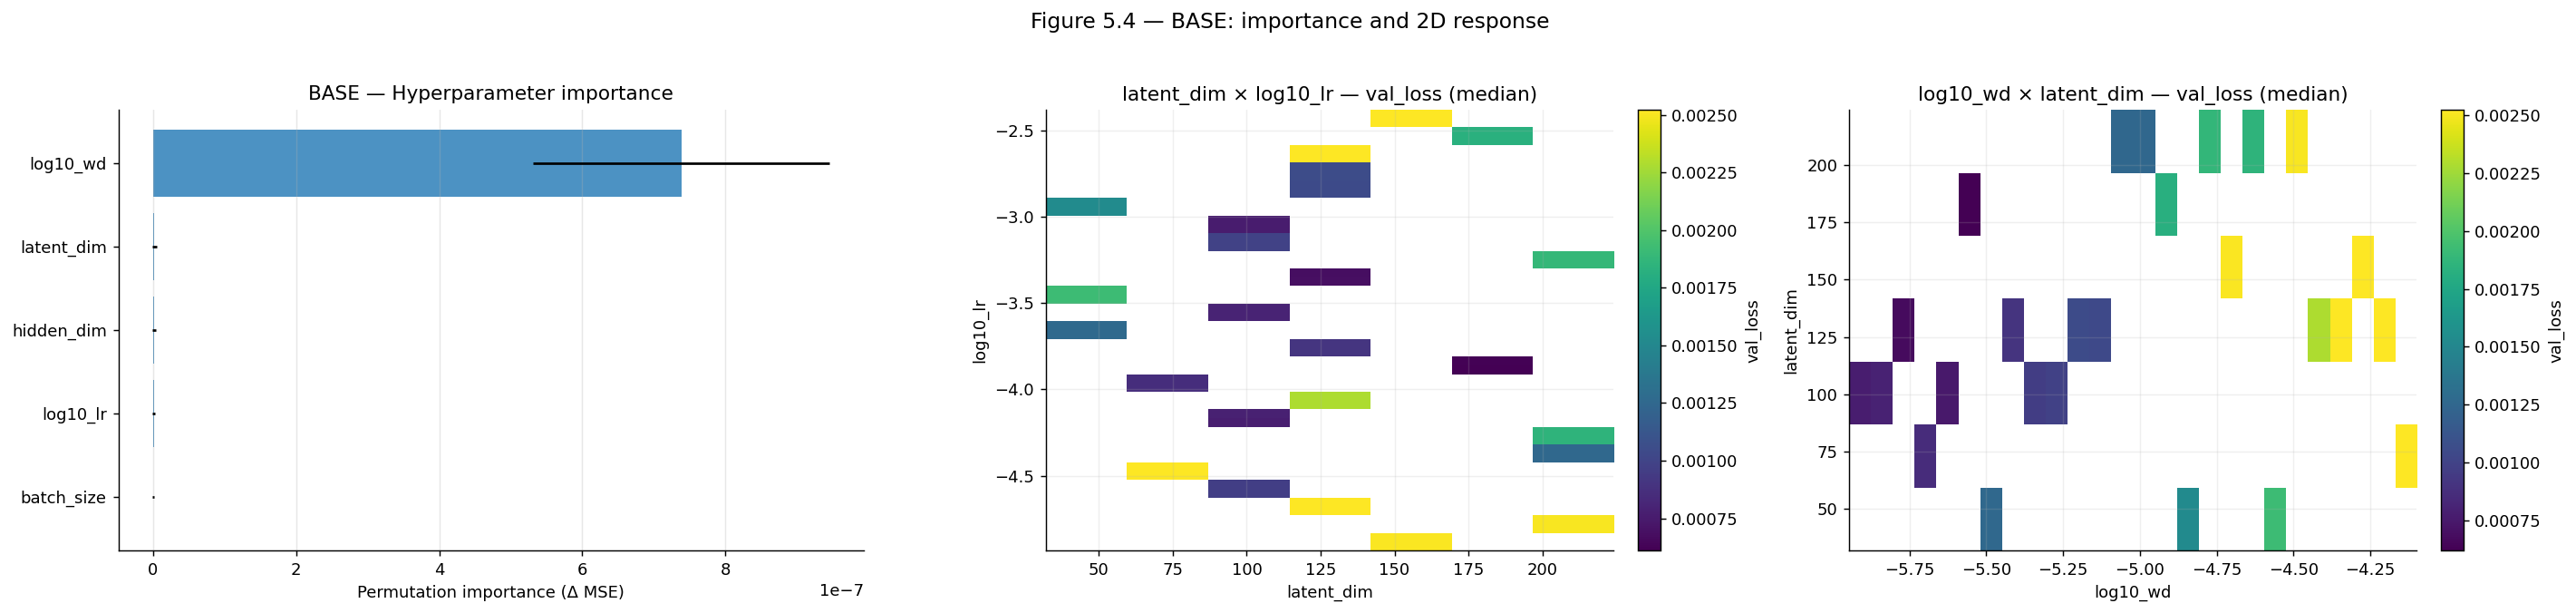

In [413]:
# BASE
df_base = gather_trials_from_history("../models/history", model_key="base", hpo_csv_glob="hpo_base_*.csv")
plot_importance_and_heatmaps(df_base, model_key="base",heatmap_pairs=  [("latent_dim", "log10_wd"), ("log10_lr", "latent_dim")]
 )


/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")
/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")


[Info] Dropping 5 rows with non-finite target or features for importance.


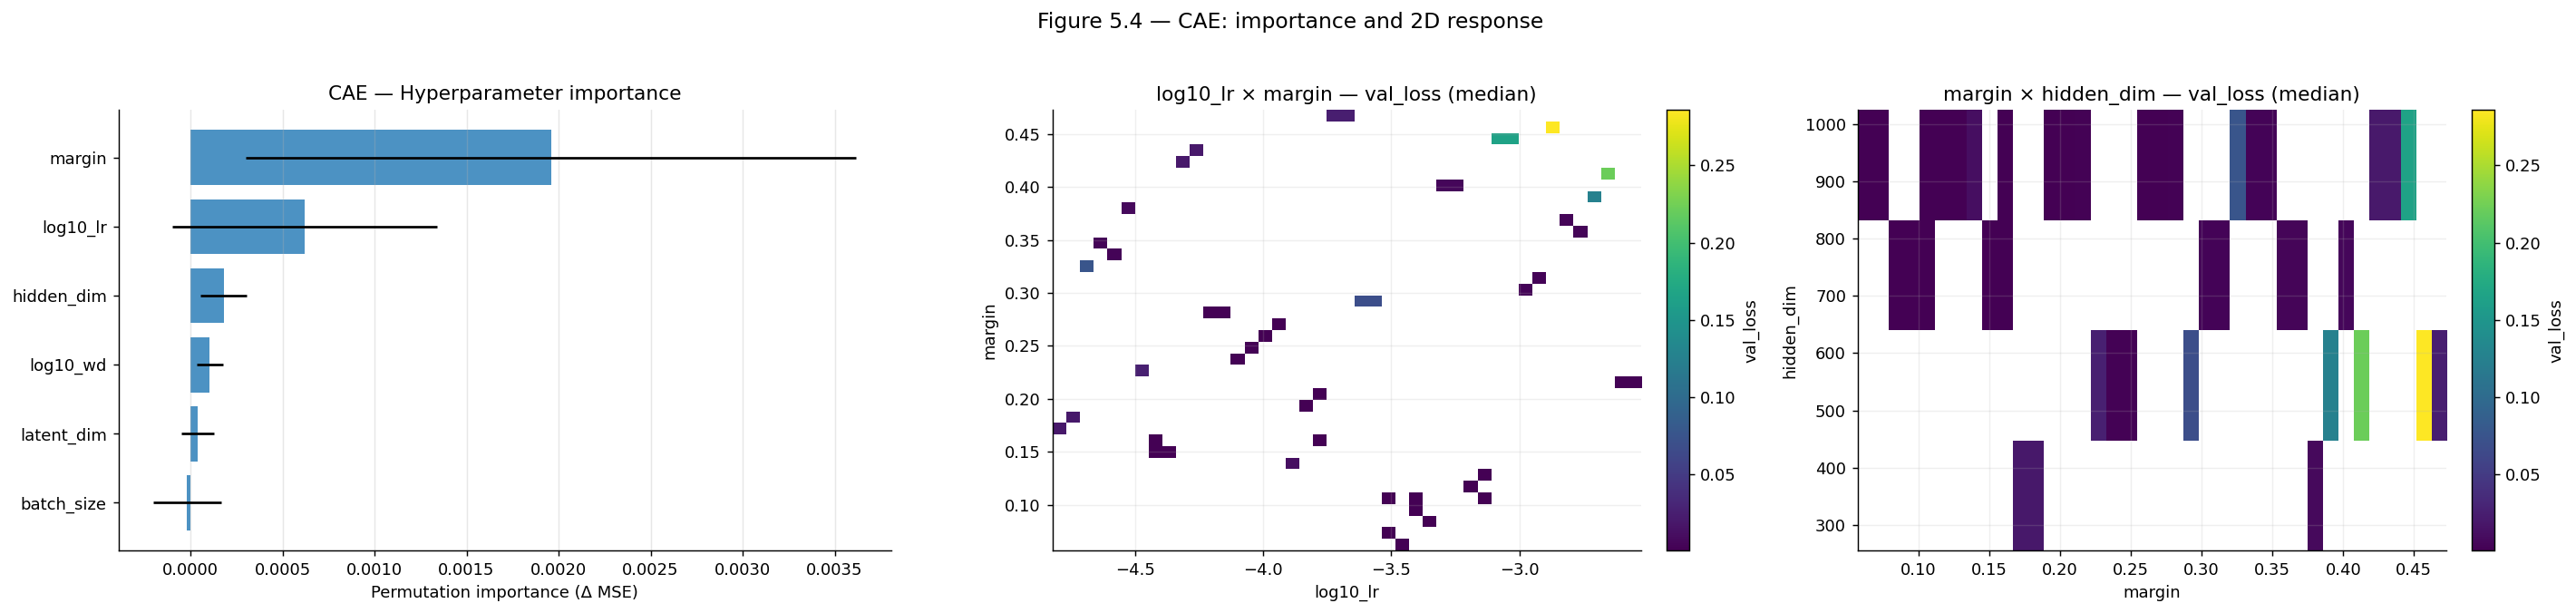

In [417]:
# CAE
df_cae = gather_trials_from_history("../models/history", model_key="cae", hpo_csv_glob="hpo_cae_*.csv")
plot_importance_and_heatmaps(df_cae, model_key="cae", heatmap_pairs=  [("log10_lr", "margin"), ("margin", "hidden_dim")])


/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")
/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")


[Info] Dropping 5 rows with non-finite target or features for importance.


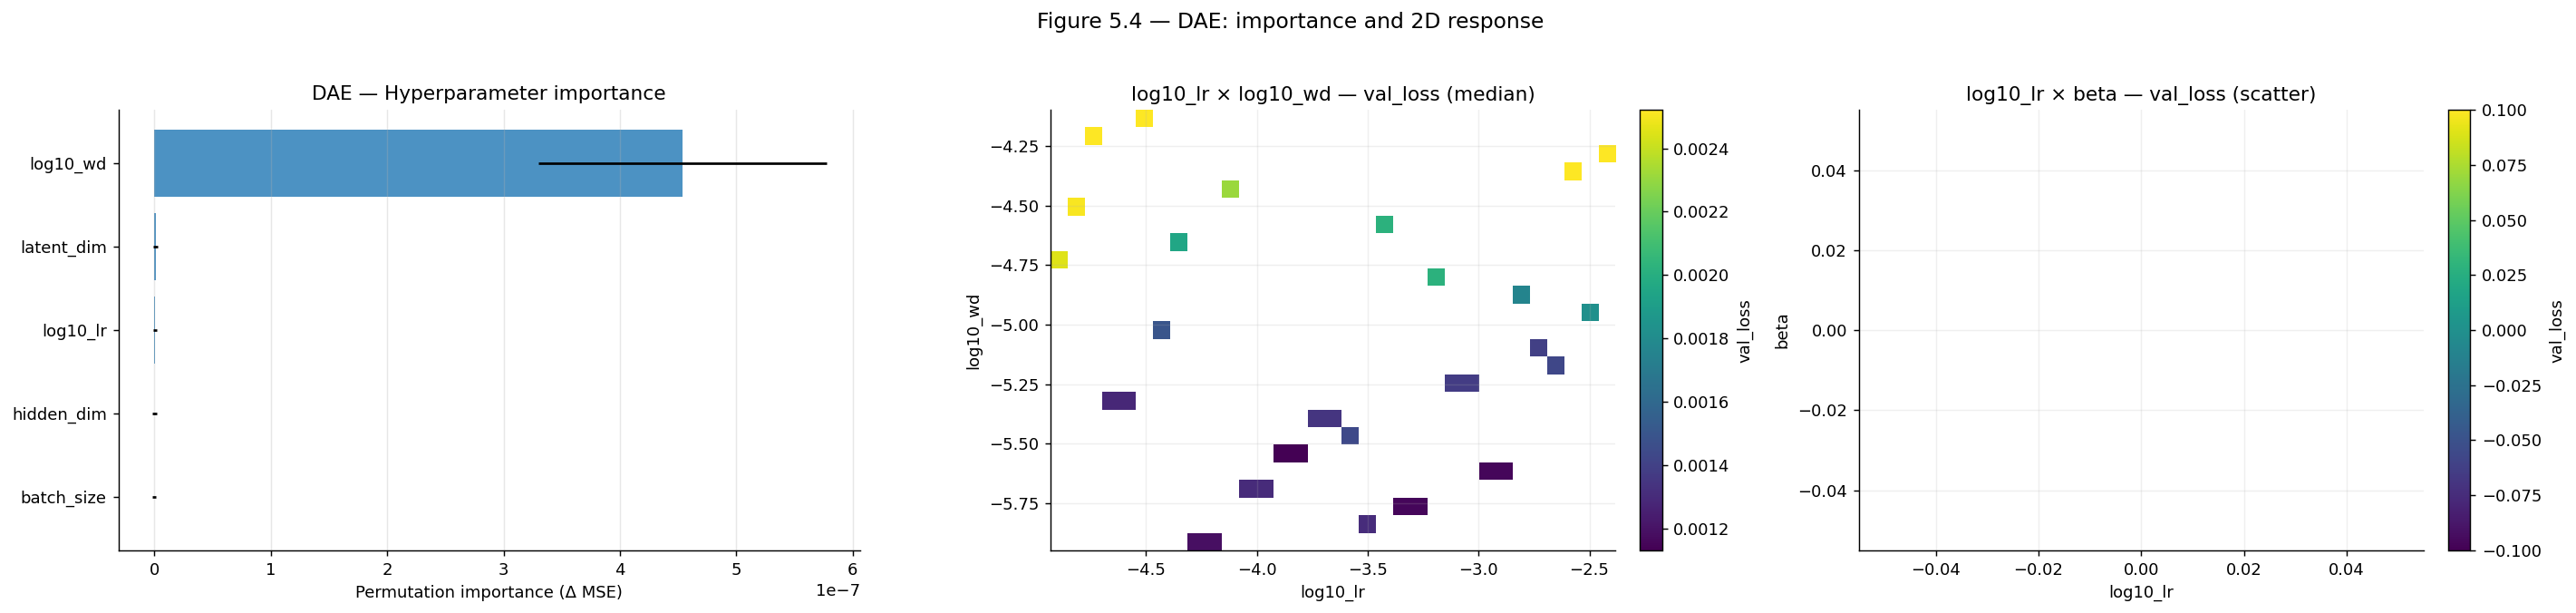

In [416]:
# DAE
df_dae = gather_trials_from_history("../models/history", model_key="dae", hpo_csv_glob="hpo_dae_*.csv")
plot_importance_and_heatmaps(df_dae, model_key="dae", heatmap_pairs=  [("log10_lr", "log10_wd"), ("log10_lr", "beta")])



/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")
/tmp/ipykernel_321273/4042472974.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[c] = pd.to_numeric(dfc[c], errors="ignore")


[Info] Dropping 5 rows with non-finite target or features for importance.


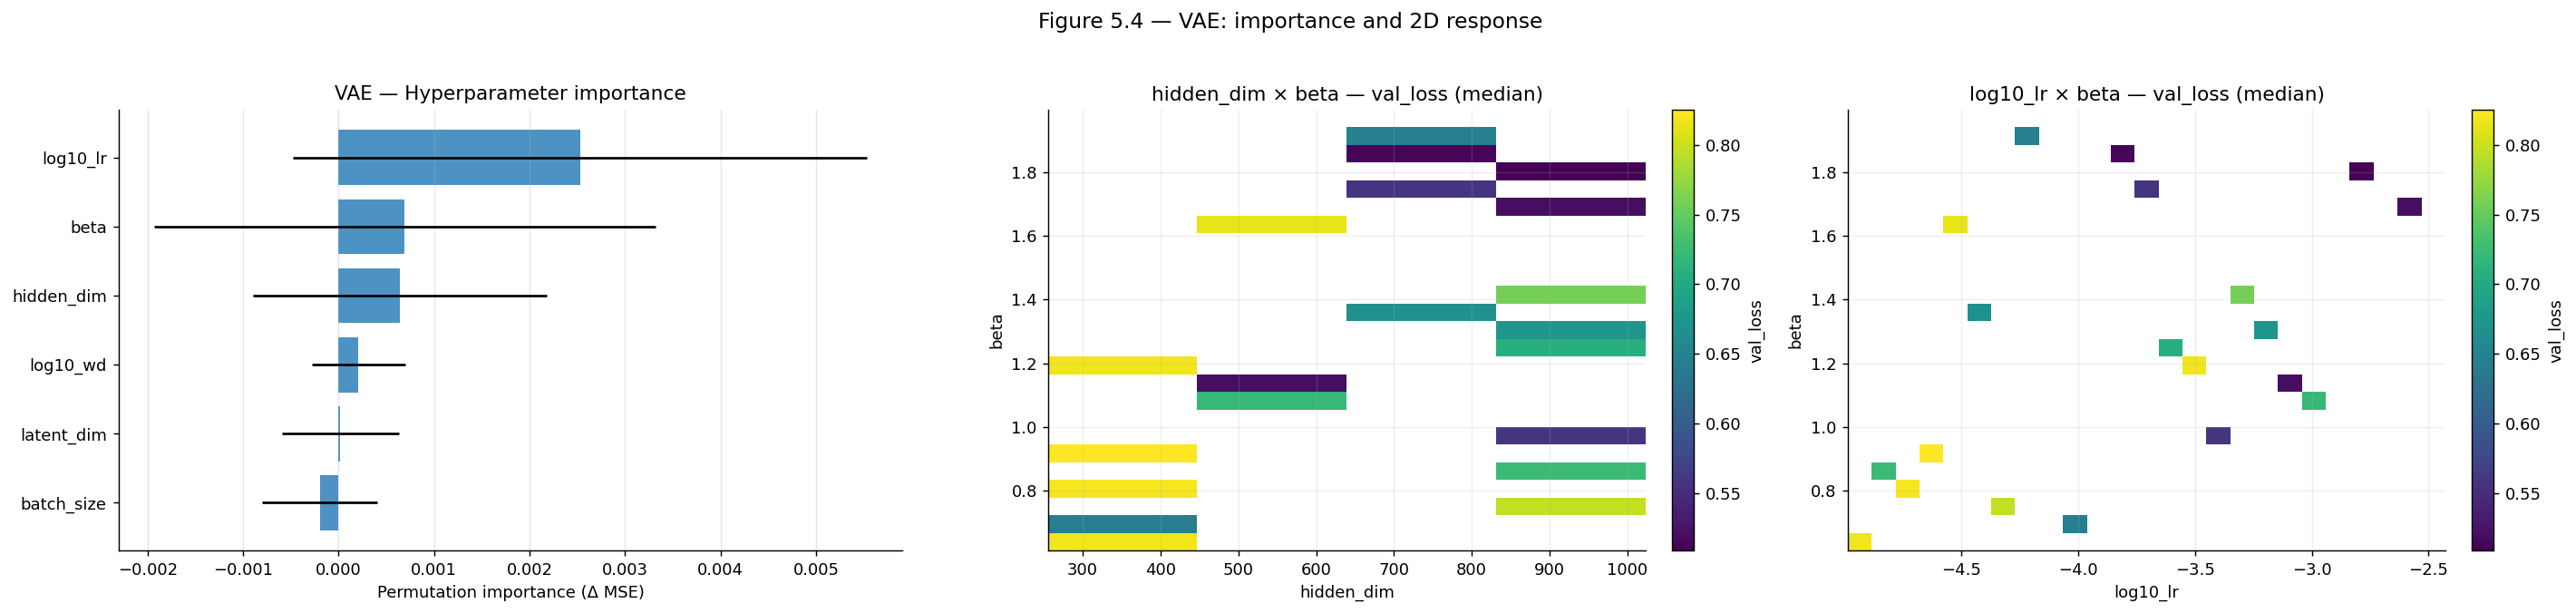

In [415]:
# vAE
df_dae = gather_trials_from_history("../models/history", model_key="vae", hpo_csv_glob="hpo_vae_*.csv")
plot_importance_and_heatmaps(df_dae, model_key="vae", heatmap_pairs=  [("hidden_dim", "beta"), ("log10_lr", "beta")])


In [295]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ----------------------------- Loading & Join ------------------------------- #

def load_hpo_trials(history_dir: str | Path, hpo_glob: str) -> pd.DataFrame:
    """Load Optuna HPO CSVs and standardise 'val_loss' + key hparams.
    - Maps 'value' -> 'val_loss'.
    - Keeps: number (trial), ckpt, latent_dim, hidden_dim, batch_size, lr, margin, weight_decay.
    """
    root = Path(history_dir)
    csvs = sorted(root.glob(hpo_glob)) or sorted(root.rglob(hpo_glob))
    if not csvs:
        raise FileNotFoundError(f"No HPO CSV matched: {root}/**/{hpo_glob}")

    frames: List[pd.DataFrame] = []
    for p in csvs:
        df = pd.read_csv(p)
        df.columns = [str(c).strip().lower() for c in df.columns]
        # value -> val_loss
        if "val_loss" not in df.columns and "value" in df.columns:
            df = df.rename(columns={"value": "val_loss"})
        keep = [
            "number", "val_loss", "ckpt", "latent_dim", "hidden_dim",
            "batch_size", "lr", "margin", "weight_decay",
        ]
        frames.append(df[[c for c in keep if c in df.columns]].copy())

    out = pd.concat(frames, ignore_index=True)
    # Coerce numeric
    for c in out.columns:
        if c not in {"ckpt"}:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    # Drop nans in target
    out = out.dropna(subset=["val_loss"]).reset_index(drop=True)
    return out

def load_retrieval_results(history_dir: str | Path, retrieval_glob: str) -> pd.DataFrame:
    """Load retrieval CSVs and normalise metric names.

    Accepts columns like: 'mrr@10','ndcg@10','recall@10' or already normalised.
    Keeps optional 'trial' when present.
    """
    root = Path(history_dir)
    csvs = sorted(root.glob(retrieval_glob)) or sorted(root.rglob(retrieval_glob))
    if not csvs:
        raise FileNotFoundError(f"No retrieval CSV matched: {root}/**/{retrieval_glob}")

    frames: List[pd.DataFrame] = []
    for p in csvs:
        df = pd.read_csv(p)
        df.columns = [str(c).strip().lower() for c in df.columns]
        # Renombrado tolerante
        rename_map = {}
        for raw, norm in [("mrr@10", "mrr10"), ("ndcg@10", "ndcg10"), ("recall@10", "recall10")]:
            if raw in df.columns and norm not in df.columns:
                rename_map[raw] = norm
        df = df.rename(columns=rename_map)

        keep = ["ckpt"] + [c for c in ("mrr10","ndcg10","recall10","trial") if c in df.columns]
        frames.append(df[keep].copy())

    out = pd.concat(frames, ignore_index=True)

    # Coerción numérica
    for c in ("mrr10","ndcg10","recall10","trial"):
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def build_trial_retrieval_table(df_hpo: pd.DataFrame, df_ret: pd.DataFrame) -> pd.DataFrame:
    """Left-join by ckpt; fallback by trial (HPO.number == RET.trial) per metric if available."""
    # Join primario por ckpt
    merged = df_hpo.merge(df_ret, on="ckpt", how="left", suffixes=("", "_ret"))

    # Si no hay 'trial' en df_ret o no hay 'number' en df_hpo, no hay fallback posible
    if "trial" not in df_ret.columns or "number" not in df_hpo.columns:
        return merged

    # Métricas realmente presentes en df_ret
    metrics = [m for m in ("mrr10", "ndcg10", "recall10") if m in df_ret.columns]
    if not metrics:
        return merged  # no hay nada que rellenar

    # Tabla auxiliar por trial
    aux = df_ret[["trial"] + metrics].dropna(subset=["trial"]).copy()

    # Para cada métrica, rellenar solo donde falte
    for m in metrics:
        miss = merged[m].isna() if m in merged.columns else (merged["ckpt"].notna())  # si no existe la col, se creará
        if miss.any():
            # merge por trial para las filas faltantes
            fill = merged.loc[miss, ["number"]].merge(
                aux.rename(columns={"trial": "number"}),
                on="number", how="left"
            )
            # si no existía la columna en merged, créala llena de NaN
            if m not in merged.columns:
                merged[m] = np.nan
            merged.loc[miss, m] = fill[m].to_numpy()

    return merged


# ------------------------------- Correlations ------------------------------- #

def _spearman_ci(x: np.ndarray, y: np.ndarray, n_boot: int = 2000, seed: int = 42) -> Tuple[float, Tuple[float, float]]:
    """Return Spearman rho and a bootstrap 95% CI."""
    rng = np.random.default_rng(seed)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if x.size < 3:
        return np.nan, (np.nan, np.nan)
    rho, _ = stats.spearmanr(x, y)
    boots = []
    n = len(x)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        r, _ = stats.spearmanr(x[idx], y[idx])
        boots.append(r)
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return float(rho), (float(lo), float(hi))


def plot_val_vs_retrieval_scatter(
    df: pd.DataFrame,
    model_label: str,
    *,
    x: str = "val_loss",
    ys: Tuple[str, ...] = ("mrr10", "ndcg10"),
) -> None:
    """Scatter plots with Spearman ρ and bootstrap CI; lower val_loss should relate to higher retrieval."""
    metrics = [m for m in ys if m in df.columns]
    if not metrics:
        raise ValueError("No retrieval metrics found in dataframe.")

    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, m in zip(axes, metrics):
        sub = df[[x, m]].dropna()
        ax.scatter(sub[x], sub[m], s=40, alpha=0.8)
        # trend line (lowess-like via rank-based fit or simple polyfit)
        if len(sub) >= 3:
            z = np.polyfit(sub[x], sub[m], deg=1)
            xp = np.linspace(sub[x].min(), sub[x].max(), 100)
            ax.plot(xp, z[0] * xp + z[1], lw=1.5)
        rho, (lo, hi) = _spearman_ci(sub[x].to_numpy(), sub[m].to_numpy())
        ax.set_xlabel("Validation loss (lower is better)")
        ax.set_ylabel(m.upper())
        ax.set_title(f"{model_label} — {m.upper()} vs val_loss\nSpearman ρ={rho:.3f} [{lo:.3f},{hi:.3f}]")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# -------------------------- Online Recall@k by epoch ------------------------ #

def load_online_recall(history_dir: str | Path, pattern: str) -> Optional[pd.DataFrame]:
    """Load optional 'online' recall logs with columns: epoch, recall@1, recall@5, recall@10.
    Returns None if no file matches.
    """
    root = Path(history_dir)
    csvs = sorted(root.glob(pattern)) or sorted(root.rglob(pattern))
    if not csvs:
        return None
    frames = []
    for p in csvs:
        df = pd.read_csv(p)
        df.columns = [c.strip().lower() for c in df.columns]
        frames.append(df[[c for c in df.columns if c.startswith("epoch") or c.startswith("recall@")]])
    out = pd.concat(frames, ignore_index=True)
    # canonical epoch column
    if "epoch" not in out.columns:
        for c in out.columns:
            if "epoch" in c:
                out = out.rename(columns={c: "epoch"})
                break
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.dropna(subset=["epoch"]).groupby("epoch", as_index=False).median(numeric_only=True)
    return out


def plot_online_recall_by_epoch(df_online: pd.DataFrame, title: str = "Online Recall@k by epoch") -> None:
    """Line plot for recall@1/5/10 over epochs (median if multiple trials are aggregated)."""
    if df_online is None or df_online.empty:
        print("No online recall logs found.")
        return
    fig, ax = plt.subplots(figsize=(7, 5))
    for k in (1, 5, 10):
        col = f"recall@{k}"
        if col in df_online.columns:
            ax.plot(df_online["epoch"], df_online[col], lw=2, label=col.upper())
    ax.set_xlabel("Epoch"); ax.set_ylabel("Recall")
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend(frameon=False)
    plt.tight_layout(); plt.show()


/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])
/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])


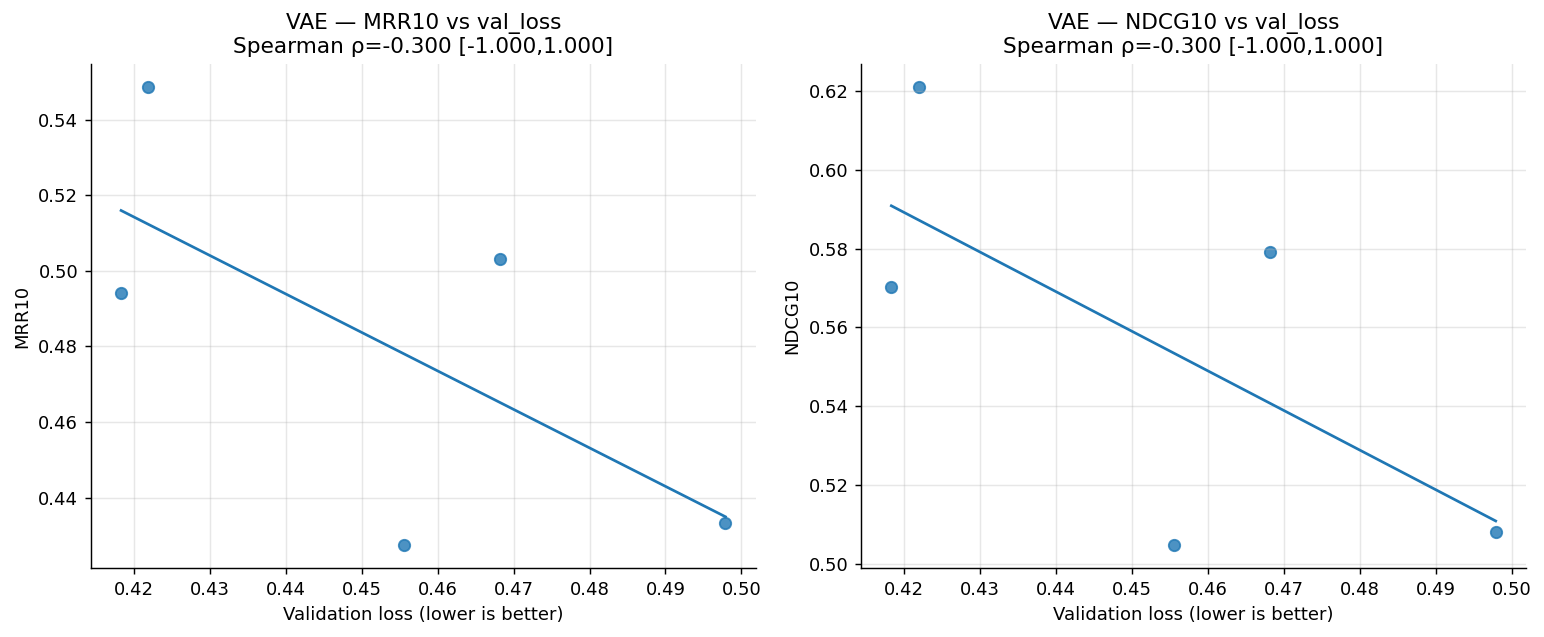

No online recall logs found.


In [451]:
# ====== VAE (ajusta globs a tus rutas reales) ======
#df_hpo = load_hpo_trials("../models/history", "hpo_vae_*.csv")
#df_ret = load_retrieval_results("../models/history", "hpo_vae_*_retrieval.csv")
#df_join = build_trial_retrieval_table(df_hpo, df_ret)

#df_join.to_csv("vae_trial_retrieval_joined.csv", index=False)  # opcional: guardar
# Remove inf and nan values from df_join
#df_join = df_join.replace([np.inf, -np.inf], np.nan).dropna()

df_join = pd.read_csv("vae_trial_retrieval_joined.csv")  # opcional: recargar

# (A) Correlación val_loss ↔ métricas de retrieval
plot_val_vs_retrieval_scatter(df_join, model_label="VAE")

# (B) Recall@k online por epoch (si lo tienes logueado)
df_online = load_online_recall("../models/history/online_eval", "*.csv")  # ajusta ruta/patrón
plot_online_recall_by_epoch(df_online, title="VAE — Online Recall@k by epoch")


/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])
/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])
/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])


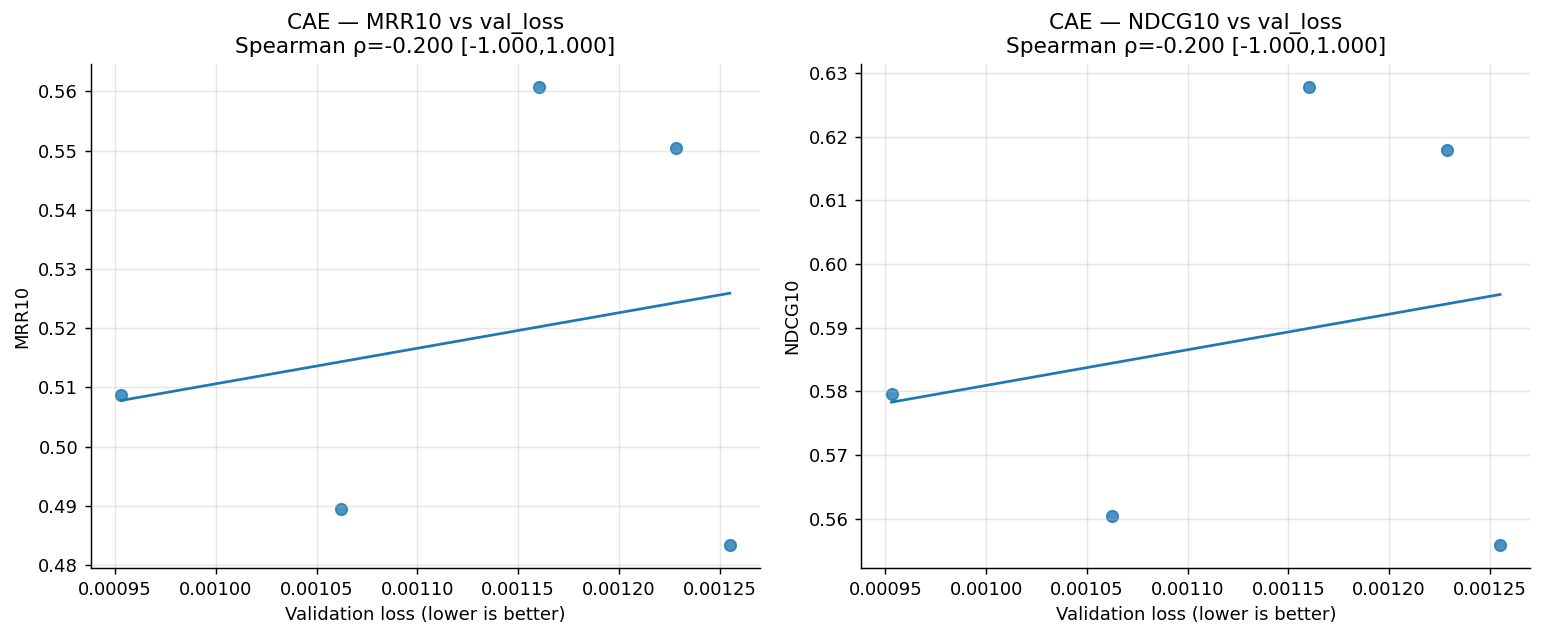

No online recall logs found.


In [272]:
# ====== CAE (ajusta globs a tus rutas reales) ======
df_hpo = load_hpo_trials("../models/history", "hpo_cae_*.csv")
df_ret = load_retrieval_results("../models/history", "hpo_cae_*_retrieval.csv")
df_join = build_trial_retrieval_table(df_hpo, df_ret)

# (A) Correlación val_loss ↔ métricas de retrieval
plot_val_vs_retrieval_scatter(df_join, model_label="CAE")

# (B) Recall@k online por epoch (si lo tienes logueado)
df_online = load_online_recall("../models/history/online_eval", "*.csv")  # ajusta ruta/patrón
plot_online_recall_by_epoch(df_online, title="CAE — Online Recall@k by epoch")


/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])
/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])


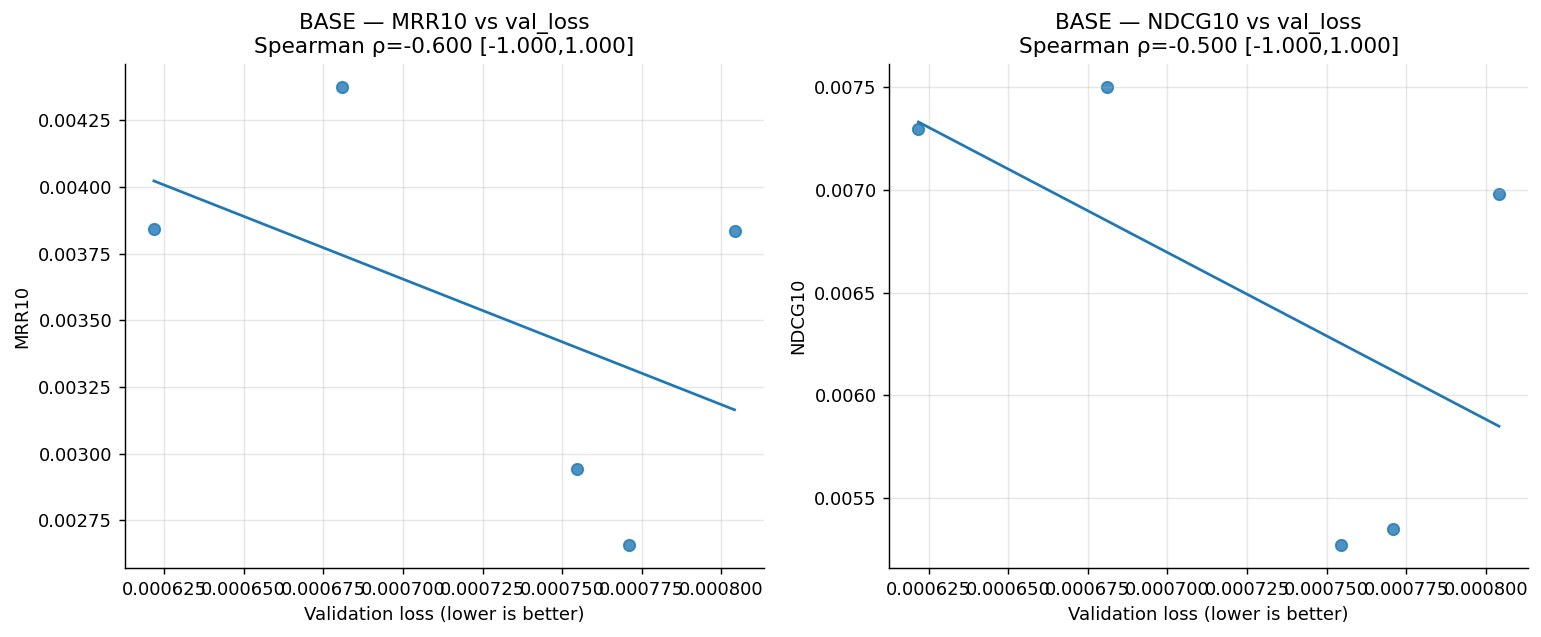

No online recall logs found.


In [296]:
# ====== BASE (ajusta globs a tus rutas reales) ======
df_hpo = load_hpo_trials("../models/history", "hpo_base_*.csv")
df_ret = load_retrieval_results("../models/history", "hpo_base_*_retrieval.csv")
df_join = build_trial_retrieval_table(df_hpo, df_ret)

# (A) Correlación val_loss ↔ métricas de retrieval
plot_val_vs_retrieval_scatter(df_join, model_label="BASE")

# (B) Recall@k online por epoch (si lo tienes logueado)
df_online = load_online_recall("../models/history/online_eval", "*.csv")  # ajusta ruta/patrón
plot_online_recall_by_epoch(df_online, title="DAE — Online Recall@k by epoch")


/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])
/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])
/tmp/ipykernel_321273/3697442757.py:128: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[idx], y[idx])


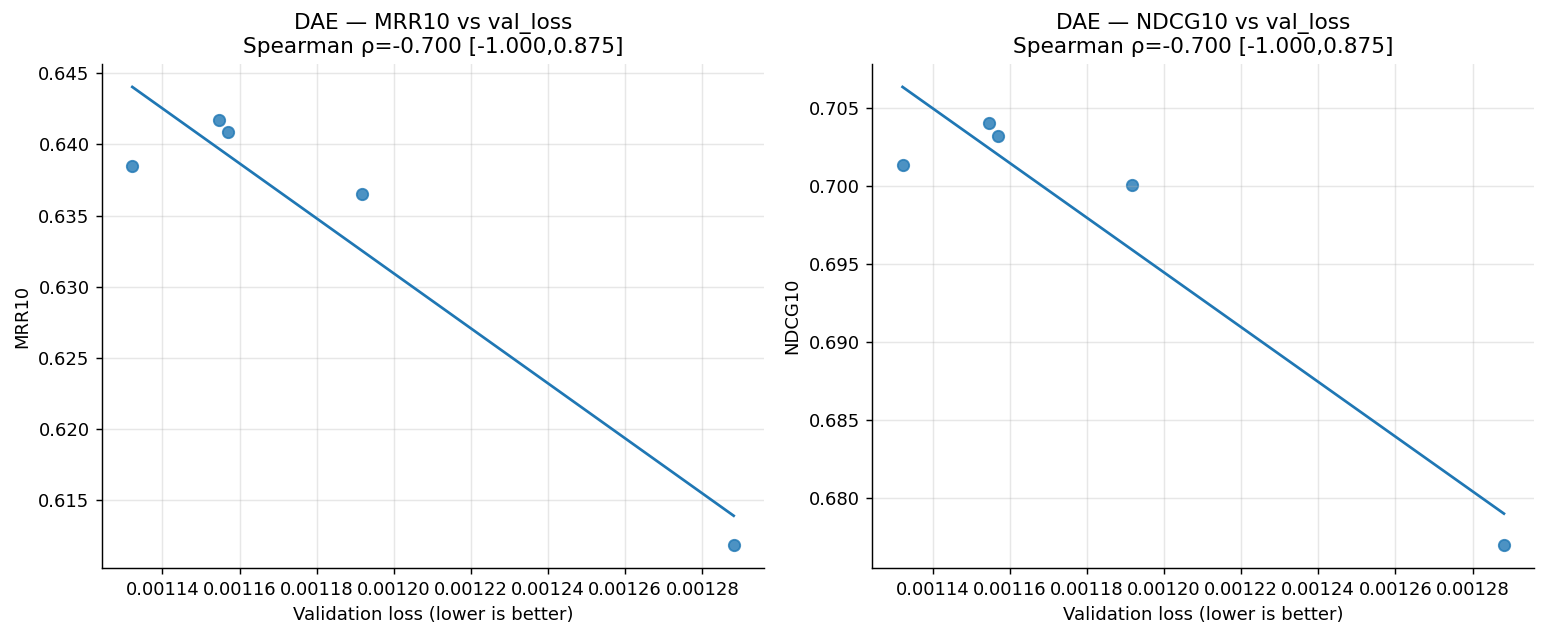

No online recall logs found.


In [270]:
# ====== CAE (ajusta globs a tus rutas reales) ======
df_hpo = load_hpo_trials("../models/history", "hpo_dae_*.csv")
df_ret = load_retrieval_results("../models/history", "hpo_dae_*_retrieval.csv")
df_join = build_trial_retrieval_table(df_hpo, df_ret)

# (A) Correlación val_loss ↔ métricas de retrieval
plot_val_vs_retrieval_scatter(df_join, model_label="DAE")

# (B) Recall@k online por epoch (si lo tienes logueado)
df_online = load_online_recall("../models/history/online_eval", "*.csv")  # ajusta ruta/patrón
plot_online_recall_by_epoch(df_online, title="DAE — Online Recall@k by epoch")


## Table data

In [403]:
import pandas as pd
import re
import io

def enrich_hpo_data(file_path):
    """
    Reads a CSV file, parses the 'ckpt' column to extract model parameters,
    and enriches the DataFrame with new columns for each parameter.

    Args:
        file_path (str): The path to the input CSV file.

    Returns:
        pd.DataFrame: A new DataFrame with the enriched data.
    """
    try:
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: The file at '{file_path}' was not found.")
        return None

    # Define a regular expression to capture the desired parameters from the filename.
    # The pattern uses named groups (?P<name>...) to make the extracted columns
    # easy to identify later.
    # - ARCH: now includes 'cae', 'dae', and 'vae'
    # - latent: captures the number after 'lat'
    # - hidden: captures the number after 'hid'
    # - val_loss: now correctly captures the float after 'val' or 'valRef'
    # - lr: now correctly captures learning rates in scientific notation (e.g., 6.35037e-05)
    # - bs: captures the batch size
    # The `(?:Ref)?` part makes the 'Ref' optional.
    # The `[\d.e+-]+` part for lr matches digits, dots, 'e', '+', and '-'.
    pattern = r'(?P<ARCH>cae|dae|vae|base)_.*_lat(?P<latent>\d+)_hid(?P<hidden>\d+)_lr(?P<lr>[\d.e+-]+)_bs(?P<bs>\d+)_.*_val(?:Ref)?(?P<val_loss>[\d.]+)\.pth'

    # Apply the regular expression to the 'ckpt' column.
    # This creates a new DataFrame with columns corresponding to the named groups.
    enriched_data = df['ckpt'].str.extract(pattern)

    # Convert the 'latent', 'hidden', and 'bs' columns to integer types and
    # 'val_loss' and 'lr' to float.
    if not enriched_data.empty:
        enriched_data['latent'] = pd.to_numeric(enriched_data['latent'])
        enriched_data['hidden'] = pd.to_numeric(enriched_data['hidden'])
        enriched_data['lr'] = pd.to_numeric(enriched_data['lr'])
        enriched_data['bs'] = pd.to_numeric(enriched_data['bs'])
        enriched_data['val_loss'] = pd.to_numeric(enriched_data['val_loss'])

    # Concatenate the original DataFrame with the new enriched data columns.
    # The axis=1 argument ensures the new columns are added horizontally.
    enriched_df = pd.concat([df, enriched_data], axis=1)

    return enriched_df


cae = enrich_hpo_data("../models/history/hpo_cae_cae_20250822_014349_retrieval.csv")
dae = enrich_hpo_data("../models/history/hpo_dae_dae_20250822_012846_retrieval.csv")
vae = enrich_hpo_data("../models/history/hpo_vae_vae_20250824_183805_retrieval.csv")
BASE = enrich_hpo_data("../models/history/hpo_base_base_20250825_224508_retrieval.csv")



display(cae.head())
display(dae.head())
display(vae.head())
display(BASE.head())

all_dfs = [df for df in [cae, dae, vae, BASE] if df is not None]

if all_dfs:
    combined_df = pd.concat(all_dfs, ignore_index=True)
            
        # Round the performance metrics to 4 decimal places for cleaner output
    combined_df['mrr@10'] = pd.to_numeric(combined_df['mrr@10'], errors='coerce').round(4)
    combined_df['ndcg@10'] = pd.to_numeric(combined_df['ndcg@10'], errors='coerce').round(4)
    combined_df['recall@10'] = pd.to_numeric(combined_df['recall@10'], errors='coerce').round(4)

    # Save the combined DataFrame to an Excel file.
    excel_output_path = "./hpo_enriched_data_train_YES.xlsx"
    combined_df.to_excel(excel_output_path, index=False)
    

,ckpt,mrr@10,ndcg@10,recall@10,trial,ARCH,latent,hidden,lr,bs,val_loss
0,./models/checkpoints/cae_20250822_014349_t24_l...,0.508688,0.579570,0.8050,24,cae,32,768,0.000350,512,0.0010
1,./models/checkpoints/cae_20250822_014349_t14_l...,0.489407,0.560524,0.7870,14,cae,32,1024,0.000304,128,0.0011
2,./models/checkpoints/cae_20250822_014349_t21_l...,0.560752,0.627782,0.8385,21,cae,64,1024,0.000247,256,0.0012
3,./models/checkpoints/cae_20250822_014349_t15_l...,0.550388,0.617851,0.8315,15,cae,64,768,0.000045,128,0.0012
4,./models/checkpoints/cae_20250822_014349_t23_l...,0.483320,0.555865,0.7865,23,cae,64,1024,0.000868,128,0.0013


,ckpt,mrr@10,ndcg@10,recall@10,trial,ARCH,latent,hidden,lr,bs,val_loss
0,./models/checkpoints/dae_20250822_012846_t10_l...,0.638501,0.701354,0.8980,10,dae,192,1024,0.000558,128,0.0011
1,./models/checkpoints/dae_20250822_012846_t0_la...,0.641670,0.704090,0.9000,0,dae,96,1024,0.000945,128,0.0012
2,./models/checkpoints/dae_20250822_012846_t24_l...,0.640861,0.703257,0.8995,24,dae,128,768,0.000818,256,0.0012
3,./models/checkpoints/dae_20250822_012846_t11_l...,0.636511,0.700086,0.8990,11,dae,96,1024,0.000266,128,0.0012
4,./models/checkpoints/dae_20250822_012846_t22_l...,0.611860,0.676964,0.8815,22,dae,96,1024,0.000043,128,0.0013


,ckpt,mrr@10,ndcg@10,recall@10,trial,ARCH,latent,hidden,lr,bs,val_loss
0,./models/checkpoints/vae_20250824_183805_t0_la...,0.433250,0.507936,0.7465,0,vae,96,1024,0.000945,128,0.4979
1,./models/checkpoints/vae_20250824_183805_t15_l...,0.502972,0.579214,0.8230,15,vae,160,768,0.000111,128,0.4682
2,./models/checkpoints/vae_20250824_183805_t16_l...,0.427388,0.504645,0.7530,16,vae,192,1024,0.001278,128,0.4555
3,./models/checkpoints/vae_20250824_183805_t20_l...,0.548613,0.621071,0.8510,20,vae,192,512,0.000064,128,0.4219
4,./models/checkpoints/vae_20250824_183805_t24_l...,0.494118,0.570226,0.8135,24,vae,224,768,0.003732,512,0.4183


,ckpt,mrr@10,ndcg@10,recall@10,trial,ARCH,latent,hidden,lr,bs,val_loss
0,./models/checkpoints/base_20250825_224508_t10_...,0.685080,0.742740,0.9230,10,base,192,1024,0.000558,128,0.0006
1,./models/checkpoints/base_20250825_224508_t24_...,0.686285,0.742960,0.9200,24,base,128,768,0.000818,256,0.0007
2,./models/checkpoints/base_20250825_224508_t0_l...,0.655131,0.715246,0.9035,0,base,96,1024,0.000945,128,0.0008
3,./models/checkpoints/base_20250825_224508_t11_...,0.668555,0.726141,0.9060,11,base,96,1024,0.000266,128,0.0008
4,./models/checkpoints/base_20250825_224508_t3_l...,0.643163,0.705017,0.8985,3,base,96,256,0.000703,512,0.0008


# Retrieval Metrics



In [10]:
# --- Notebook cell: robust loading + plots (matplotlib only) -----------------
from __future__ import annotations
from pathlib import Path
import json
import math
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------ Loading --------------------------------------
def load_histories(
    history_dir: str | Path,
    model_key: str = "cae",
) -> List[Tuple[pd.DataFrame, Dict[str, Any], Path]]:
    """Load CSV/JSON training histories robustly.

    - Accepts variants used by VAE runs (train_loss_ref / train_loss_oper,
      val_loss_ref / val_loss_oper, val_recon + val_kl).
    - Normalises column names to 'epoch','train_loss','val_loss'.
    """
    history_dir = Path(history_dir)
    results: List[Tuple[pd.DataFrame, Dict[str, Any], Path]] = []

    patterns = [f"{model_key}_*.csv", f"*{model_key}*.csv"]
    candidates = set()
    for pat in patterns:
        candidates |= set(history_dir.glob(pat))

    print(f"candidates: {candidates}")

    for csv_path in sorted(candidates):
        json_path = csv_path.with_suffix(".json")
        if not json_path.exists():
            print(f"Skipping {csv_path.name}: missing JSON metadata")
            continue

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Skipping {csv_path.name}: failed to read CSV ({e})")
            continue

        # normalize column names -> lower + stripped
        col_map = {c: str(c).strip().lower() for c in df.columns}
        df = df.rename(columns=col_map)

        # canonical epoch column (accept variants)
        if "epoch" not in df.columns:
            for c in df.columns:
                if "epoch" in c:
                    df = df.rename(columns={c: "epoch"})
                    break

        # Build train_loss from common variants
        if "train_loss" not in df.columns:
            if "train_loss_ref" in df.columns:
                df["train_loss"] = df["train_loss_ref"]
            elif "train_loss_oper" in df.columns:
                df["train_loss"] = df["train_loss_oper"]

        # Build val_loss from common variants; fallback to val_recon + val_kl if present
        if "val_loss" not in df.columns:
            if "val_loss_ref" in df.columns:
                df["val_loss"] = df["val_loss_ref"]
            elif "val_loss_oper" in df.columns:
                df["val_loss"] = df["val_loss_oper"]
            else:
                # If the VAE logged reconstruction + KL separately, use their sum where available.
                has_recon = "val_recon" in df.columns
                has_kl = "val_kl" in df.columns
                if has_recon or has_kl:
                    recon = pd.to_numeric(df["val_recon"], errors="coerce") if has_recon else pd.Series(np.nan, index=df.index)
                    kl = pd.to_numeric(df["val_kl"], errors="coerce") if has_kl else pd.Series(np.nan, index=df.index)
                    # prefer sum when at least one component is present
                    df["val_loss"] = recon.fillna(0.0) + kl.fillna(0.0)
                    # If both were NaN, keep NaN

        required = {"epoch", "train_loss", "val_loss"}
        if not required.issubset(set(df.columns)):
            print(f"Skipping {csv_path.name}: missing required columns after normalization. Have: {list(df.columns)}")
            continue

        # Coerce numeric types and sort by epoch
        df["epoch"] = pd.to_numeric(df["epoch"], errors="coerce")
        df["train_loss"] = pd.to_numeric(df["train_loss"], errors="coerce")
        df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")
        df = df.dropna(subset=["epoch"]).sort_values("epoch").reset_index(drop=True)

        # load metadata json (best-effort)
        try:
            with open(json_path, "r") as f:
                meta = json.load(f)
        except Exception as e:
            print(f"Warning: failed to read JSON {json_path.name}: {e}")
            meta = {}

        results.append((df, meta, csv_path))

    return results

def align_epochs(dfs: List[pd.DataFrame]) -> Tuple[np.ndarray, List[np.ndarray]]:
    """Align curves by common epoch grid.

    Returns:
        epochs: 1D array of common epochs.
        curves: list of val_loss arrays (NaN where not available).
    """
    if not dfs:
        return np.array([]), []
    # Use the union of epochs; then reindex each series
    all_epochs = sorted(set(int(e) for df in dfs for e in df["epoch"].tolist()))
    curves = []
    for df in dfs:
        s = df.set_index("epoch")["val_loss"].reindex(all_epochs).to_numpy(dtype=float)
        curves.append(s)
    return np.array(all_epochs), curves


# ------------------------------ Plot 1: Percentile band ----------------------
def plot_val_loss_percentile_band(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    model_label: str = "CAE",
    loss_tag: str = "best_val_loss"
) -> None:
    """Plot median and P10–P90 percentile band of val_loss across trials."""
    if not histories:
        print("No histories loaded.")
        return

    dfs = [h[0] for h in histories]
    epochs, curves = align_epochs(dfs)
    if len(epochs) == 0:
        print("No epochs to plot.")
        return

    M = np.vstack(curves)  # shape [n_trials, n_epochs]
    # Compute percentiles ignoring NaN
    p10 = np.nanpercentile(M, 10, axis=0)
    p50 = np.nanpercentile(M, 50, axis=0)
    p90 = np.nanpercentile(M, 90, axis=0)

    # Best run (min of best_val_loss from meta)
    best_idx = int(np.nanargmin([h[1].get(loss_tag, np.nan) for h in histories]))
    best_df = histories[best_idx][0]
    best_meta = histories[best_idx][1]

    plt.figure(figsize=(11, 6))
    # Band
    plt.fill_between(epochs, p10, p90, alpha=0.25, label="P10–P90 (val_loss)")
    # Median
    plt.plot(epochs, p50, linewidth=2, label="Median (val_loss)")
    # Best run
    plt.plot(best_df["epoch"], best_df["val_loss"], linewidth=2.5, label=f"Best (val={best_meta[loss_tag]:.4g})")

    # Mark early stopping if present
    es = best_meta.get("epochs_ran", None)
    if es is not None and es in best_df["epoch"].values:
        y_es = best_df.loc[best_df["epoch"] == es, "val_loss"].item()
        plt.scatter([es], [y_es], s=60, marker="D")
        plt.annotate(f"early stop @ {es}", (es, y_es), xytext=(8, 8), textcoords="offset points")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(f"{model_label} — Validation loss distribution across trials")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------ Plot 2: Heatmap ------------------------------
def plot_best_val_heatmap(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    x_key: str = "latent_dim",
    y_key: str = "hidden_dim",
    agg: str = "best_val_loss",
    model_label: str = "CAE",
) -> None:
    """Heatmap of best_val_loss aggregated by two hyperparameters."""
    if not histories:
        print("No histories loaded.")
        return

    rows = []
    for _, meta, _ in histories:
        if x_key in meta and y_key in meta and agg in meta:
            rows.append({x_key: meta[x_key], y_key: meta[y_key], agg: meta[agg]})
    if not rows:
        print("No metadata keys found to build heatmap.")
        return
    df = pd.DataFrame(rows)
    # Pivot table: mean in case of repeated configs
    pt = df.pivot_table(index=y_key, columns=x_key, values=agg, aggfunc="mean")

    plt.figure(figsize=(10, 7))
    # Avoid specifying colors (let matplotlib choose)
    plt.imshow(pt.values, aspect="auto", origin="lower", interpolation="nearest")
    plt.colorbar(label=agg)
    plt.xticks(range(len(pt.columns)), pt.columns, rotation=45)
    plt.yticks(range(len(pt.index)), pt.index)
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title(f"{model_label} — Heatmap of {agg} by ({x_key}, {y_key})")
    # Put values on cells (optional but informative)
    for i in range(pt.shape[0]):
        for j in range(pt.shape[1]):
            val = pt.values[i, j]
            if not (isinstance(val, float) and math.isnan(val)):
                plt.text(j, i, f"{val:.3g}", ha="center", va="center")
    plt.tight_layout()
    plt.show()


# ------------------------------ Plot 3: LR vs best_val -----------------------
def plot_lr_vs_bestval(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    model_label: str = "CAE",
    loss_tags: str = "best_val_loss",
) -> None:
    """Scatter of learning_rate (log10) vs best_val_loss; marker size by batch_size."""
    xs, ys, sizes = [], [], []
    for _, meta, _ in histories:
        lr = meta.get("learning_rate", None)
        bv = meta.get(loss_tags, None)
        bs = meta.get("batch_size", None)
        if lr and bv:
            xs.append(np.log10(lr))
            ys.append(bv)
            sizes.append(40 if not bs else 20 + 5 * math.log2(bs))

    if not xs:
        print("No (learning_rate, best_val_loss) pairs found.")
        return

    plt.figure(figsize=(9, 6))
    plt.scatter(xs, ys, s=sizes, alpha=0.7)
    plt.xlabel("log10(learning_rate)")
    plt.ylabel("best_val_loss")
    plt.title(f"{model_label} — best_val_loss vs learning_rate")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------ Plot 4: Small multiples ----------------------
def plot_small_multiples_topk(
    histories: List[Tuple[pd.DataFrame, Dict[str, Any], Path]],
    top_k: int = 6,
    model_label: str = "CAE",
    loss_tags: str = "best_val_loss",
) -> None:
    """Show top-k runs (by best_val_loss) as small multiples with train/val curves."""
    if not histories:
        print("No histories loaded.")
        return

    # Sort by best_val_loss ascending
    ranked = sorted(histories, key=lambda t: t[1].get(loss_tags, float("inf")))
    sel = ranked[:top_k]

    cols = 3
    rows = math.ceil(top_k / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols + 1, 3.2 * rows), squeeze=False)
    for ax, (df, meta, path) in zip(axes.flat, sel):
        ax.plot(df["epoch"], df["train_loss"], alpha=0.7, label="train_loss")
        ax.plot(df["epoch"], df["val_loss"], linewidth=2, label="val_loss")
        # Mark min val
        idx_min = int(df["val_loss"].idxmin())
        ax.scatter([df.loc[idx_min, "epoch"]], [df.loc[idx_min, "val_loss"]], marker="D", s=40)
        # Early stopping
        es = meta.get("epochs_ran", None)
        if es is not None and es in df["epoch"].values:
            y_es = df.loc[df["epoch"] == es, "val_loss"].item()
            ax.scatter([es], [y_es], s=30)
        # Title with compact hyperparams
        title = (f"lat={meta.get('latent_dim')}, hid={meta.get('hidden_dim')}, "
                 f"bs={meta.get('batch_size')}, lr={meta.get('learning_rate'):.2e}\n"
                 f"best_val={meta.get(loss_tags):.4g}")
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc="upper right")

    # Empty subplots if any
    for i in range(len(sel), rows * cols):
        fig.delaxes(axes.flat[i])

    fig.suptitle(f"{model_label} — Top-{top_k} runs (train vs val)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()




In [20]:
import pandas as pd

path = "/home/engares/unir/tfm/code/logs/benchmarks/experiments.csv"

df = pd.read_csv(path, engine="python")                 # coma por defecto
# el archivo venía con multiíndice en filas
if isinstance(df.index, pd.MultiIndex):
    df = df.reset_index()

# renombro las columnas del índice original para no chocar con split numérico
df = df.rename(columns={
    "level_0": "timestamp_idx",
    "level_1": "tag_idx",
    "level_2": "dataset_idx",
    "level_3": "data_split",          # aquí está validation
    "level_4": "max_samples_idx",
})

# construyo la columna timestamp correcta desde timestamp_idx
if "timestamp_idx" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp_idx"], errors="coerce")
    df = df.drop(columns=["timestamp_idx"], errors="ignore")

# si quedara un timestamp antiguo numérico, ignóralo o elimínalo
# df = df.drop(columns=["timestamp"], errors="ignore")  # si prefieres mantener solo la nueva

# verificación rápida
print(type(df.index))
display(df[["timestamp", "data_split", "tag", "split"]].head(6))


<class 'pandas.core.indexes.range.RangeIndex'>


,timestamp,data_split,tag,split
0,2025-08-22 17:39:43,validation,sentence-transformers/all-MiniLM-L6-v2,64
1,2025-08-22 17:39:45,validation,sentence-transformers/all-MiniLM-L6-v2,96
2,2025-08-22 17:39:47,validation,sentence-transformers/all-MiniLM-L6-v2,128
3,2025-08-22 17:39:50,validation,sentence-transformers/all-MiniLM-L6-v2,192
4,2025-08-22 17:39:51,validation,sentence-transformers/all-MiniLM-L6-v2,32
5,2025-08-22 17:39:53,validation,sentence-transformers/all-MiniLM-L6-v2,64


In [6]:
# --- Notebook cell 1: imports & config ---------------------------------------
from __future__ import annotations
from io import StringIO
from pathlib import Path
from typing import Optional, Tuple, Dict, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib defaults (sin estilos externos)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# --- Notebook cell 2: loading & schema normalization -------------------------
import csv
from io import StringIO
from pathlib import Path
from typing import Optional, Tuple, Dict, Iterable

import numpy as np
import pandas as pd

# --- Strict CSV loader for the retrieval results -----------------------------
from __future__ import annotations
from pathlib import Path
from io import StringIO
from typing import Optional, Iterable
import pandas as pd
import numpy as np

from __future__ import annotations
from pathlib import Path
from io import StringIO
from typing import Optional, Iterable
import pandas as pd
import numpy as np

EXPECTED_COLS = [
    "timestamp","tag","dataset","split","max_samples","n_queries",
    "embedder","ae_type","latent_dim","dim_in","compression_ratio",
    "ae_checkpoint","hidden_dim","beta","epochs_trained","early_stop_epoch",
    "retriever","index_type","metric","normalize_l2","use_gpu","top_k","candidate_k",
    "n_corpus","chunking_enabled","chunk_mode","chunk_max_tokens","chunk_stride",
    "chunk_min_tokens","recall@10","mrr@10","ndcg@10","build_time_s","search_time_s",
    "search_calls","query_p50_ms","query_p95_ms","qps","index_size_mb",
    "emb_disk_mb_original","emb_disk_mb_compressed","storage_saving_pct",
    "rougeL","rougeL_ci95_low","rougeL_ci95_high","bleu","meteor"
]

def read_results_strict(csv_path: Optional[str | Path] = None,
                        csv_text: Optional[str] = None) -> pd.DataFrame:
    """Load the retrieval CSV with a strict, comma-only schema.

    - Forces comma delimiter (no sniffing, no whitespace separators).
    - Does NOT use the first column as index.
    - Keeps exactly EXPECTED_COLS; drops any trailing extra fields (e.g., run_id).
    - Preserves strings (paths) and converts metrics to numeric afterwards.

    Returns:
        DataFrame with columns exactly matching EXPECTED_COLS.
    """
    if (csv_path is None) == (csv_text is None):
        raise ValueError("Provide exactly one source: csv_path OR csv_text.")

    read_kwargs = dict(
        sep=",", engine="python", header=0, index_col=False,
        dtype=str, skipinitialspace=True, comment=None
    )

    if csv_text is not None:
        df_raw = pd.read_csv(StringIO(csv_text), **read_kwargs)
    else:
        df_raw = pd.read_csv(Path(csv_path), **read_kwargs)  # type: ignore[arg-type]

    # Normaliza cabeceras y elimina posibles BOM
    df_raw.columns = [str(c).strip().lstrip("\ufeff").lower() for c in df_raw.columns]

    # Recorta columnas sobrantes y renombra a esquema exacto
    if len(df_raw.columns) < len(EXPECTED_COLS):
        raise ValueError(f"CSV has {len(df_raw.columns)} columns, expected ≥ {len(EXPECTED_COLS)}.")
    df = df_raw.iloc[:, :len(EXPECTED_COLS)].copy()
    df.columns = [c.lower() for c in EXPECTED_COLS]

    # Parseo opcional de timestamp (si te interesa como datetime)
    try:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    except Exception:
        pass

    return df

# (Opcional) utilidades de coerción numérica para métricas posteriores
def to_numeric(df: pd.DataFrame, cols: Iterable[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Derive canonical labels + composite metrics, with robust QPS handling."""
    df = df.copy()

    # --- types ---
    num_cols = [
        "latent_dim", "dim_in", "compression_ratio",
        "recall@10", "mrr@10", "ndcg@10",
        "qps", "storage_saving_pct",
        "emb_disk_mb_original", "emb_disk_mb_compressed",
        "n_queries", "search_time_s",
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # --- arch label ---
    def canonical_arch(ae_type: Optional[str]) -> str:
        if ae_type is None:
            return "UNKNOWN"
        ae = str(ae_type).lower()
        if ae in {"vae", "dae", "cae"}: return ae.upper()
        if ae == "none": return "SBERT"      # <- SBERT explícito
        if ae in {"bm25", "dpr"}: return ae.upper()
        return ae.upper()

    df["arch"] = df["ae_type"].apply(canonical_arch)

    # --- method label ---
    def method_label(row: pd.Series) -> str:
        arch = row.get("arch", "")
        lat = row.get("latent_dim", np.nan)
        if arch in {"VAE","DAE","CAE"} and pd.notna(lat):
            return f"{arch}-lat{int(lat)}"
        if arch == "SBERT": return "SBERT-384"
        if arch in {"BM25","DPR"}: return arch
        return str(arch)

    df["method_label"] = df.apply(method_label, axis=1)

    # --- performance aggregate (opc.) ---
    df["perf_score"] = df[["recall@10","mrr@10","ndcg@10"]].mean(axis=1, skipna=True)

    # --- real compression factor (cuando haya tamaños) ---
    have_sizes = df["emb_disk_mb_original"].notna() & df["emb_disk_mb_compressed"].notna()
    df["compression_factor_real"] = np.where(
        have_sizes & (df["emb_disk_mb_compressed"] > 0),
        df["emb_disk_mb_original"] / df["emb_disk_mb_compressed"],
        df["compression_ratio"]
    )

    # --- QPS: no rellenar a cero; imputar solo si se puede ---
    # si qps falta pero hay n_queries y search_time_s>0, imputar
    need_qps = df["qps"].isna()
    can_impute = need_qps & df["n_queries"].notna() & (df["search_time_s"] > 0)
    df.loc[can_impute, "qps"] = df.loc[can_impute, "n_queries"] / df.loc[can_impute, "search_time_s"]
    # mantener NaN si no se puede (p. ej., BM25/DPR con search_time_s=0 y sin p50)

    # --- tamaños para plotting ---
    df["storage_saving_pct"] = df["storage_saving_pct"].fillna(0.0)

    return df



# --- Notebook cell 5: run all -------------------------------------------------
df_raw = read_results_strict(csv_path='../logs/benchmarks/experiments.csv')


df = engineer_features(df_raw)
display(df[['arch','recall@10', 'mrr@10', 'ndcg@10', 'storage_saving_pct', "chunking_enabled"]].sort_values(by='recall@10', ascending=False))  # summary stats





/tmp/ipykernel_26868/3392004937.py:75: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_raw = pd.read_csv(Path(csv_path), **read_kwargs)  # type: ignore[arg-type]


,arch,recall@10,mrr@10,ndcg@10,storage_saving_pct,chunking_enabled
10,SBERT,0.917219,0.726970,0.773363,0.000000,False
57,BASE,0.898581,0.696488,0.745552,50.000000,True
64,BASE,0.897162,0.690995,0.741059,50.000000,True
42,CAE,0.895459,0.690256,0.739932,58.333333,True
62,BASE,0.893094,0.685195,0.735555,66.666667,True
...,...,...,...,...,...,...
25,CAE,0.730085,0.468957,0.531318,91.666667,True
4,CAE,0.716651,0.452842,0.515791,91.666667,False
31,VAE,0.681362,0.404627,0.470468,75.000000,True
17,VAE,0.677956,0.399350,0.465577,75.000000,True


In [45]:
def _pareto_front_xy(x: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Return (xp, yp) of the Pareto frontier maximising x and y."""
    order = np.argsort(-x)  # x desc
    x_sorted, y_sorted = x[order], y[order]
    y_max = -np.inf
    xp, yp = [], []
    for xi, yi in zip(x_sorted, y_sorted):
        if yi > y_max:  # not dominated
            xp.append(xi); yp.append(yi); y_max = yi
    return np.array(xp), np.array(yp)

def _k_formatter(x, pos=None):
    if x >= 1000:
        return f"{int(round(x/1000))}K"
    return f"{int(x)}"

from matplotlib.ticker import FuncFormatter

# ...existing code...

# Paleta global consistente (puedes moverla a una celda superior si ya existe)
ARCH_COLORS = {
    "DAE":   "#1f77b4",  # azul
    "CAE":   "#ff7f0e",  # naranja
    "SBERT": "#2ca02c",  # verde
    "VAE":   "#d62728",  # rojo
    "BASE":  "#9467bd",  # morado
    "BM25":  "#8c564b",  # marrón
    "DPR":   "#e377c2",  # rosa
}

from matplotlib.ticker import FuncFormatter

def scatter_tradeoff_annotated(
    df: pd.DataFrame,
    x: str = "qps",
    y: str = "recall@10",
    size: str = "storage_saving_pct",
    hue: str = "arch",
    title: str = "Trade-off: Calidad vs Velocidad (tamaño ∝ ahorro almacenamiento)",
    label_points: bool = False,
    show_pareto: bool = True,
    zones: Optional[Dict[str, Dict[str, float]]] = None,
    palette: Optional[Dict[str, str]] = None,   # NUEVO: permite pasar otra paleta
) -> None:
    """
    Scatter de QPS vs métrica con zonas sombreadas y frontera de Pareto.

    Cambios:
      - Colores deterministas usando ARCH_COLORS (o 'palette' si se pasa).
      - Orden de arquitecturas según la paleta para consistencia entre ejecuciones.
      - Parámetro 'palette' opcional para sobreescribir colores.

    Si existe chunking_enabled==True se usan diferentes formas (marker) por chunk_mode
    SOLO para esas filas (enabled). Filas con chunking_enabled False usan marcador 'o'.

    Leyendas separadas:
      - Arquitectura (color)
      - Modo de chunking (forma) si procede
    """
    req = {x, y, size, hue}
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    if "method_label" not in df.columns:
        raise ValueError("Falta columna requerida: 'method_label'")

    dplot = df[[x, y, size, hue, "method_label"] +
               [c for c in ("chunking_enabled", "chunk_mode") if c in df.columns]
              ].dropna(subset=[x, y]).copy()
    if dplot.empty:
        raise ValueError("No hay datos válidos para graficar.")

    show_chunk_shapes = (
        "chunking_enabled" in dplot.columns and
        "chunk_mode" in dplot.columns and
        dplot["chunking_enabled"].astype(str).str.lower().eq("true").any()
    )

    if show_chunk_shapes:
        mask_enabled = dplot["chunking_enabled"].astype(str).str.lower() == "true"
        dplot.loc[mask_enabled, "chunk_mode"] = (
            dplot.loc[mask_enabled, "chunk_mode"]
            .astype(str).str.strip().str.lower()
            .replace({"nan": "none", "": "none"})
        )

    # --- Figura y zonas ---
    fig, ax = plt.subplots(figsize=(8.5, 5.3))
    if zones is None:
        qx50, qx80 = dplot[x].quantile([0.50, 0.80])
        qy50, qy80 = dplot[y].quantile([0.50, 0.80])
        zones = {
            "Zona Óptima": dict(xmin=qx50, xmax=qx80, ymin=qy80, ymax=dplot[y].max() * 1.002),
            "Alta Eficiencia": dict(xmin=qx80, xmax=dplot[x].max() * 1.002, ymin=qy50, ymax=qy80),
        }
    for name, box in zones.items():
        ax.axvspan(box["xmin"], box["xmax"], ymin=0, ymax=1, alpha=0.07)
        ax.annotate(
            name,
            xy=((box["xmin"] + box["xmax"]) / 2, (box["ymin"] + box["ymax"]) / 2),
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.9),
            fontsize=10,
        )

    # -------- Colores deterministas --------
    pal = palette or ARCH_COLORS
    # Orden de arquitecturas: primero las definidas en la paleta (si presentes), luego cualquier extra
    cats_present = list(dplot[hue].dropna().unique())
    ordered = [a for a in pal.keys() if a in cats_present] + [a for a in cats_present if a not in pal]
    # Remover duplicados manteniendo orden
    seen = set()
    cats = [c for c in ordered if not (c in seen or seen.add(c))]
    color_map = {c: pal.get(c, "#666666") for c in cats}

    # -------- Marcadores (solo para chunk enabled) --------
    if show_chunk_shapes:
        enabled_rows = dplot[dplot["chunking_enabled"].astype(str).str.lower() == "true"]
        chunk_modes = list(enabled_rows["chunk_mode"].dropna().unique())
        marker_cycle = ['s', 'D', '^', 'v', 'P', 'X', '*', '>', '<', 'h', 'H']
        marker_map = {m: marker_cycle[i % len(marker_cycle)] for i, m in enumerate(chunk_modes)}
        default_marker = 'o'
    else:
        marker_map = {}
        default_marker = 'o'

    arch_plotted = set()
    chunk_handles_done: set = set()
    chunk_mode_handles = []

    # Escalado de tamaño (proporcional a ahorro)
    global_max = float(dplot[size].astype(float).fillna(0).max())
    global_max = 1.0 if global_max <= 0 else global_max
    MIN_SIZE = 40.0

    # -------- Plot por arquitectura --------
    for cat in cats:
        sub_arch = dplot[dplot[hue] == cat].dropna(subset=[x, y])
        if sub_arch.empty:
            continue

        if show_chunk_shapes:
            disabled = sub_arch[~sub_arch["chunking_enabled"].astype(str).str.lower().eq("true")]
            enabled = sub_arch[sub_arch["chunking_enabled"].astype(str).str.lower().eq("true")]

            if not disabled.empty:
                s_sub = disabled[size].astype(float).fillna(0).to_numpy()
                s_sub = np.maximum(MIN_SIZE, 200.0 * (s_sub / global_max))
                s_sub = np.where(np.isfinite(s_sub) & (s_sub >= 0), s_sub, MIN_SIZE)
                ax.scatter(
                    disabled[x].to_numpy(),
                    disabled[y].to_numpy(),
                    s=s_sub,
                    color=color_map[cat],
                    marker=default_marker,
                    alpha=0.85,
                    linewidths=0.6,
                    edgecolors="white",
                    label=cat if cat not in arch_plotted else None,
                )
                arch_plotted.add(cat)

            for cmode, g in enabled.groupby("chunk_mode"):
                s_sub = g[size].astype(float).fillna(0).to_numpy()
                s_sub = np.maximum(MIN_SIZE, 200.0 * (s_sub / global_max))
                s_sub = np.where(np.isfinite(s_sub) & (s_sub >= 0), s_sub, MIN_SIZE)
                marker = marker_map.get(cmode, default_marker)
                ax.scatter(
                    g[x].to_numpy(),
                    g[y].to_numpy(),
                    s=s_sub,
                    color=color_map[cat],
                    marker=marker,
                    alpha=0.85,
                    linewidths=0.6,
                    edgecolors="white",
                    label=cat if cat not in arch_plotted else None,
                )
                arch_plotted.add(cat)

                if cmode not in chunk_handles_done:
                    h = plt.Line2D(
                        [0], [0],
                        marker=marker,
                        linestyle="",
                        color="gray",
                        markerfacecolor="gray",
                        markeredgecolor="black",
                        label=f"chunk={cmode}"
                    )
                    chunk_mode_handles.append(h)
                    chunk_handles_done.add(cmode)
        else:
            s_sub = sub_arch[size].astype(float).fillna(0).to_numpy()
            s_sub = np.maximum(MIN_SIZE, 200.0 * (s_sub / global_max))
            s_sub = np.where(np.isfinite(s_sub) & (s_sub >= 0), s_sub, MIN_SIZE)
            ax.scatter(
                sub_arch[x].to_numpy(),
                sub_arch[y].to_numpy(),
                s=s_sub,
                alpha=0.85,
                label=cat,
                linewidths=0.6,
                edgecolors="white",
                color=color_map[cat],
            )

    # -------- Pareto --------
    if show_pareto:
        xp, yp = _pareto_front_xy(dplot[x].to_numpy(), dplot[y].to_numpy())
        ax.plot(xp, yp, linestyle="--", linewidth=1.2, color="black")
        if len(xp) >= 2:
            ax.annotate(
                "",
                xy=(xp[0], yp[0]),
                xytext=(xp[-1], yp[-1]),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black")
            )

    # Etiquetas opcionales
    if label_points:
        for _, r in dplot.iterrows():
            ax.annotate(
                str(r["method_label"]), xy=(r[x], r[y]),
                xytext=(2, 4), textcoords="offset points",
                fontsize=8, alpha=0.75
            )

    ax.set_xlabel("Consultas por Segundo (QPS)")
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.25)

    # -------- Leyendas --------
    ncol_arch = min(6, len(cats))
    arch_leg = ax.legend(title=hue, ncol=ncol_arch)

    if show_chunk_shapes and chunk_mode_handles:
        chunk_mode_handles_sorted = sorted(chunk_mode_handles, key=lambda h: h.get_label())
        rows_arch = int(math.ceil(len(cats) / ncol_arch)) if ncol_arch > 0 else 1
        base_y = 1.0 - 0.09 * rows_arch - 0.015
        lift = 0.06
        chunk_y = min(0.985, base_y + lift)
        leg_chunk = ax.legend(
            handles=chunk_mode_handles_sorted,
            title="Chunk mode",
            loc="upper right",
            bbox_to_anchor=(1.0, chunk_y),
            frameon=True
        )
        ax.add_artist(arch_leg)

    ax.xaxis.set_major_formatter(FuncFormatter(_k_formatter))
    fig.tight_layout(rect=[0, 0, 0.82, 1])


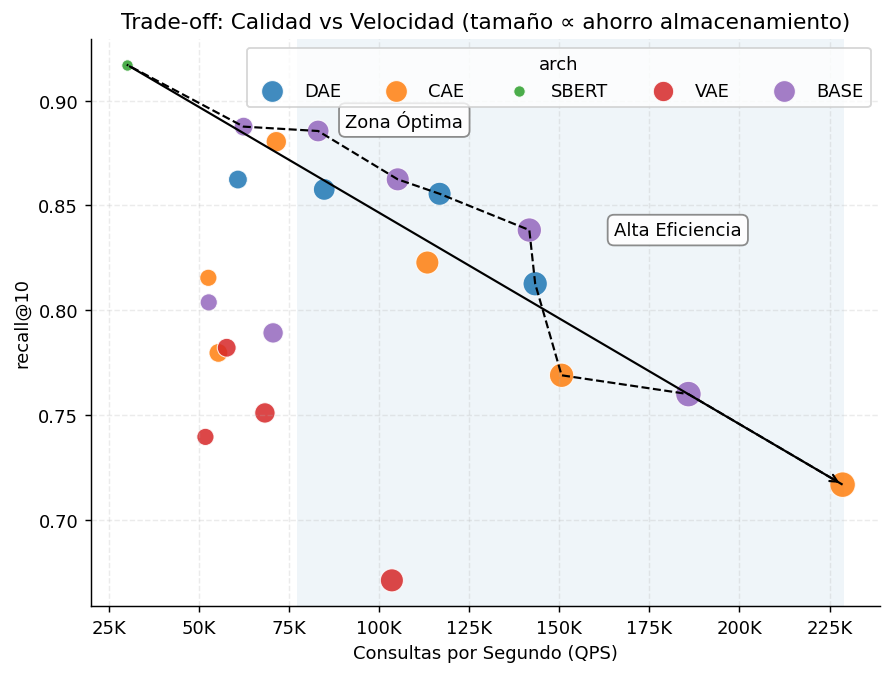

In [46]:
from matplotlib.ticker import FuncFormatter
scatter_tradeoff_annotated(
    df[df['chunking_enabled'] == "False"],  
    x="qps",
    y="recall@10",
    size="storage_saving_pct",
    hue="arch",
    title="Trade-off: Calidad vs Velocidad (tamaño ∝ ahorro almacenamiento)",
    label_points=False,   # pon True si deseas texto en cada punto
    show_pareto=True,
    zones=None            # o pasa tus umbrales si quieres cajas exactas
)


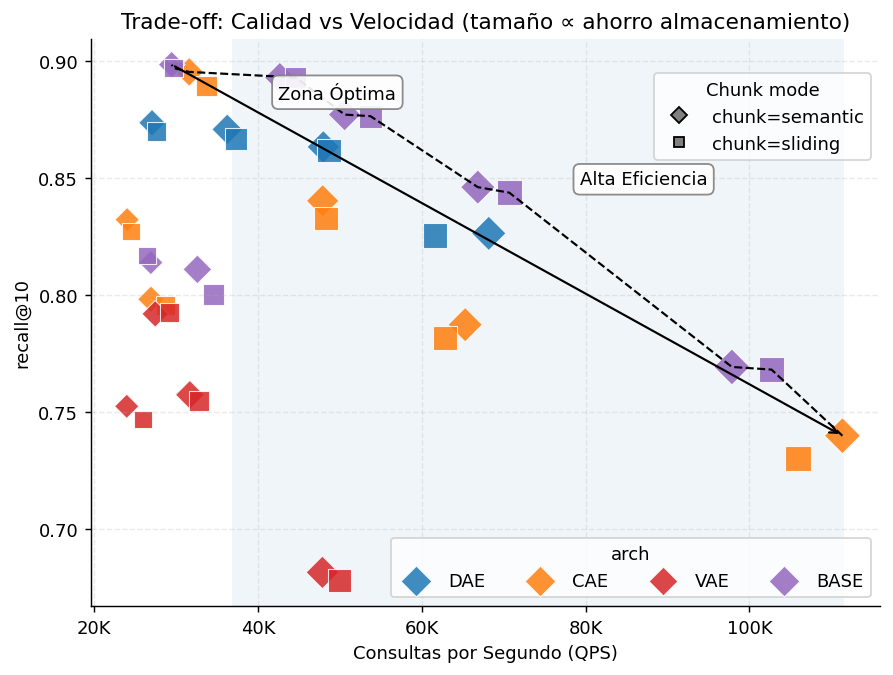

In [47]:
from matplotlib.ticker import FuncFormatter
scatter_tradeoff_annotated(
    df[df['chunking_enabled'] == "True"],  
    x="qps",
    y="recall@10",
    size="storage_saving_pct",
    hue="arch",
    title="Trade-off: Calidad vs Velocidad (tamaño ∝ ahorro almacenamiento)",
    label_points=False,   # pon True si deseas texto en cada punto
    show_pareto=True,
    zones=None            # o pasa tus umbrales si quieres cajas exactas
)


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional
import pandas as pd

# Brighter color palette for architectures
ARCH_COLORS = {
    "DAE":   "#1f77b4",  # azul
    "CAE":   "#ff7f0e",  # naranja
    "SBERT": "#2ca02c",  # verde
    "VAE":   "#d62728",  # rojo
    "BASE":  "#9467bd",  # morado
    "BM25":  "#8c564b",  # marrón
    "DPR":   "#e377c2",  # rosa
}


def boxplot_performance_by_arch(
    df: pd.DataFrame,
    metric: str = "ndcg@10",
    title: Optional[str] = None,
    palette: Optional[dict] = None,
) -> None:
    """Elegant boxplot of retrieval performance by architecture with bright colors, sorted by metric."""
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in DataFrame.")

    preferred = ["VAE", "DAE", "CAE", "SBERT", "BM25", "DPR", "BASE"]
    present = [a for a in preferred if a in set(df["arch"])]

    plot_df = df[df["arch"].isin(present)][["arch", metric]].dropna()
    if plot_df.empty:
        raise ValueError(f"No valid values for metric '{metric}'.")

    # Sort architectures by the median value of the metric
    median_order = (
        plot_df.groupby("arch")[metric]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    colors = palette if palette is not None else ARCH_COLORS

    plt.figure(figsize=(8.5, 5.2))
    sns.boxplot(
        data=plot_df,
        x="arch",
        y=metric,
        order=median_order,
        palette=colors,
        width=0.55,
        linewidth=1.3,
        fliersize=0,
        boxprops=dict(alpha=0.6),
        whiskerprops=dict(alpha=0.7),
        medianprops=dict(color="black", linewidth=2.2),
    )
    sns.stripplot(
        data=plot_df,
        x="arch",
        y=metric,
        order=median_order,
        color="black",
        alpha=0.4,
        jitter=0.28,
        size=3.2,
    )
    plt.xlabel("Architecture")
    plt.ylabel(metric)
    plt.title(
        title or f"Distribution of {metric} by Architecture",
        pad=14,
    )
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_26868/1343108595.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


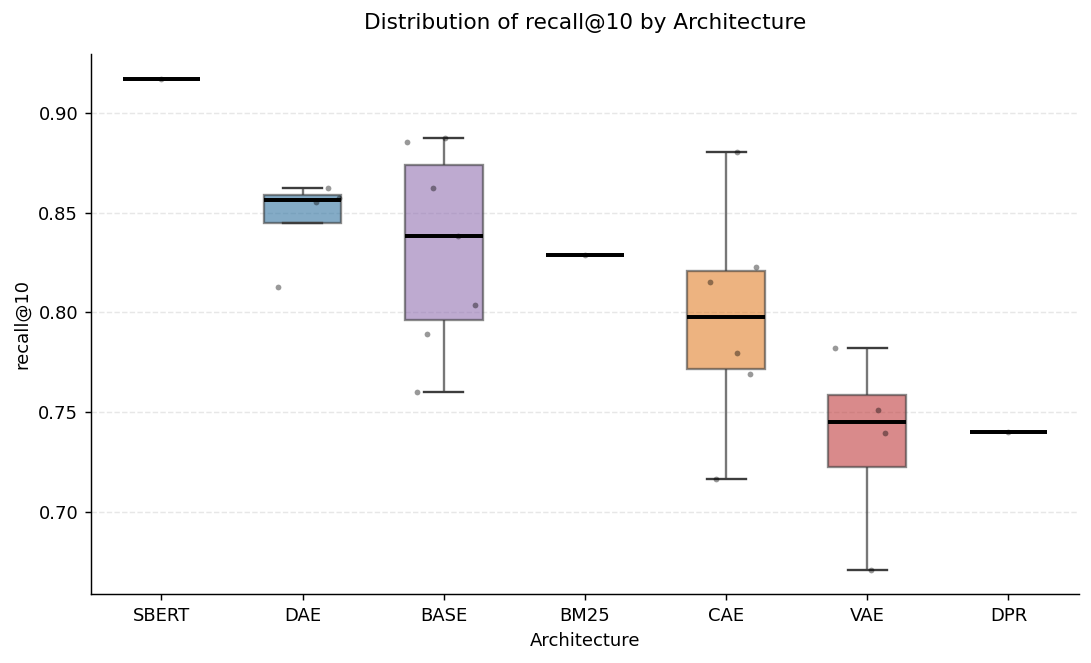

In [38]:
# 2) Distribución de rendimiento por arquitectura (usa nDCG@10; puedes cambiar a 'mrr@10' o 'perf_score')
boxplot_performance_by_arch(df[df['chunking_enabled'] == "False"], metric="recall@10")


In [28]:
from __future__ import annotations

from typing import Iterable, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ---------- helpers ----------

def _ensure(df: pd.DataFrame, cols: Iterable[str]) -> None:
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns: {miss}")

def _kfmt(x: float, _: int) -> str:
    if np.isnan(x):
        return ""
    return f"{x/1000:.1f}k" if abs(x) >= 1000 else f"{x:.0f}"

def _compute_compression(df: pd.DataFrame, base_dim: int) -> pd.DataFrame:
    out = df.copy()
    out["compression_x"] = (base_dim / out["latent_dim"].astype(float)).replace([np.inf], np.nan)
    return out

def _pareto_mask(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    # Max–max Pareto; True = eficiente
    dom = np.zeros(len(a), dtype=bool)
    for i in range(len(a)):
        dom[i] = np.any((a >= a[i]) & (b >= b[i]) & ((a > a[i]) | (b > b[i])))
    return ~dom


# ---------- 1) Heatmap anotado ----------

def plot_efficiency_heatmap(
    df: pd.DataFrame,
    metric: str = "ndcg@10",
    base_dim: int = 768,
    title: str = "Mapa de eficiencia: calidad (color) y QPS (anotación)",
) -> None:
    """Architecture × latent_dim matrix: color = metric, annotation = QPS and ×compression."""
    _ensure(df, ["arch", "latent_dim", "qps", metric])
    dfp = df[df["arch"].isin(["BASE", "VAE", "DAE", "CAE"])].dropna(subset=["latent_dim"]).copy()
    if dfp.empty:
        raise ValueError("No data for BASE/VAE/DAE/CAE with latent_dim.")

    dfp = _compute_compression(dfp, base_dim)
    arch_order = [a for a in ["BASE", "VAE", "DAE", "CAE"] if a in dfp["arch"].unique()]
    latents = sorted(dfp["latent_dim"].unique())
    lat_log = [int(np.log2(x)) if x > 0 else x for x in latents]

    # Pivot metric and QPS
    M = dfp.pivot(index="arch", columns="latent_dim", values=metric).reindex(index=arch_order, columns=latents)
    Q = dfp.pivot(index="arch", columns="latent_dim", values="qps").reindex(index=arch_order, columns=latents)
    C = dfp.pivot(index="arch", columns="latent_dim", values="compression_x").reindex(index=arch_order, columns=latents)

    fig, ax = plt.subplots(figsize=(1.6*len(latents)+3.0, 1.0*len(arch_order)+2.0))
    im = ax.imshow(M, aspect="auto")
    ax.set_xticks(range(len(latents)), [f"2^{lg}\n({int(l)})" for lg, l in zip(lat_log, latents)])
    ax.set_yticks(range(len(arch_order)), arch_order)
    ax.set_title(title, pad=10)

    # Text annotations: QPS and ×compression
    for i, a in enumerate(arch_order):
        for j, l in enumerate(latents):
            q = Q.loc[a, l]
            m = M.loc[a, l]
            c = C.loc[a, l]
            if pd.notna(m):
                txt_q = "" if pd.isna(q) else (f"{q/1000:.1f}k" if q >= 1000 else f"{q:.0f}")
                txt_c = "" if pd.isna(c) else f"×{c:.1f}"
                ax.text(j, i, f"{txt_q}\n{txt_c}", ha="center", va="center", fontsize=9, color="white" if m < M.values.mean() else "black")

    # Colorbar with metric label
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(metric)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




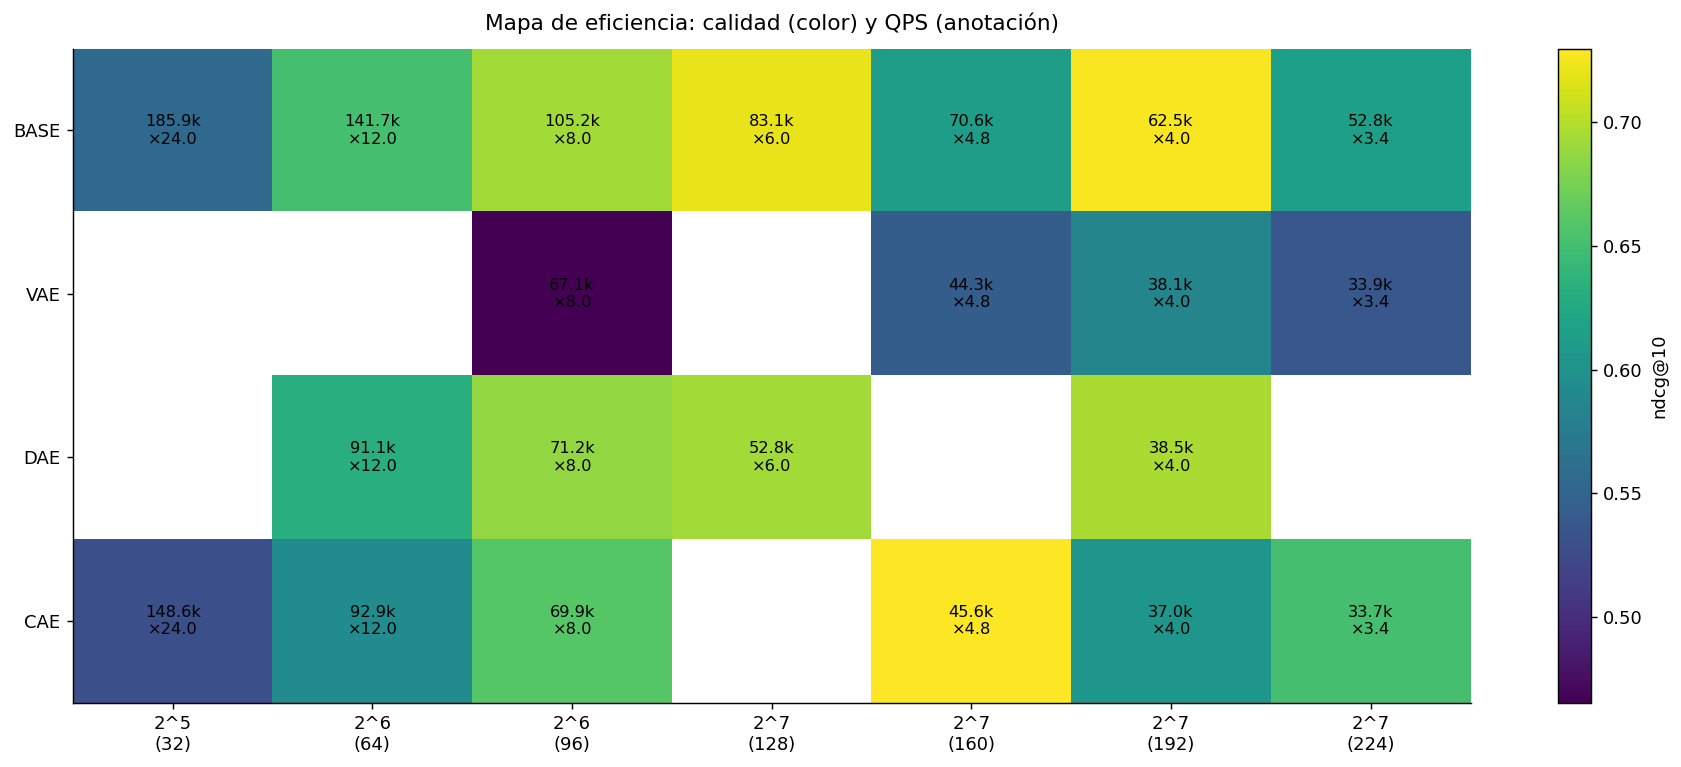

In [29]:
# Aggregate duplicates by mean before plotting
df_eff = df.groupby(['arch', 'latent_dim'], as_index=False).mean(numeric_only=True)
plot_efficiency_heatmap(df_eff)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

palette = {
    "32 to 96": "#1f77b4",     # Blue
    "128 to 192": "#ff7f0e",   # Orange
    "256 to 384": "#2ca02c",   # Green
    "384 plus": "#d62728",     # Red
}

def plot_violin_by_arch_latent_ranges(
    df: pd.DataFrame,
    metric: str = "ndcg@10",
    arch_col: str = "arch",
    latent_col: str = "latent_dim",
    title: str = "Performance distribution by architecture and latent dimension ranges",
    palette: dict = palette,
    arch_order: list | None = None,
    show_points: bool = True,
    point_alpha: float = 0.25,
    seed: int = 17,
) -> None:
    """
    Violin plot of a retrieval metric grouped by architecture with one violin per latent range.

    Args:
        df: DataFrame with columns [arch_col, latent_col, metric].
        metric: Metric column name, for example 'ndcg@10'.
        arch_col: Column with the architecture label.
        latent_col: Column with the latent dimension.
        title: Figure title.
        palette: Map from latent range label to color.
        arch_order: Optional explicit order for architectures. If None the function orders by overall median.
        show_points: If True, plot light jittered points to show sample density.
        point_alpha: Alpha for points.
        seed: Random seed for reproducible jitter.
    """
    # Basic validation
    required = {arch_col, latent_col, metric}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Focus on the main learned families present in the figure
    keep = ["BASE", "VAE", "DAE", "CAE"]
    dfp = df[df[arch_col].isin(keep)].dropna(subset=[latent_col, metric]).copy()
    if dfp.empty:
        raise ValueError("No rows for BASE VAE DAE CAE")

    # Define latent bins and labels
    bins = [0, 96, 192, 384, np.inf]
    labels = ["32 to 96", "128 to 192", "256 to 384", "384 plus"]
    dfp["latent_range"] = pd.cut(dfp[latent_col], bins=bins, labels=labels, right=True)
    dfp = dfp.dropna(subset=["latent_range"])

    # Determine architecture order by median if not provided
    if arch_order is None:
        med = dfp.groupby(arch_col)[metric].median().sort_values(ascending=False)
        archs = med.index.tolist()
    else:
        archs = [a for a in arch_order if a in dfp[arch_col].unique()]

    ranges = [lab for lab in labels if lab in dfp["latent_range"].unique()]

    # Prepare data map
    data = {
        (a, r): dfp[(dfp[arch_col] == a) & (dfp["latent_range"] == r)][metric].dropna().to_numpy()
        for a in archs for r in ranges
    }

    # Layout
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(2.2 * len(archs), 6.0))
    width = 0.18
    spacing = 1.0

    # Draw violins with medians and an inner IQR box
    for i, arch in enumerate(archs):
        base_x = i * spacing
        for j, r in enumerate(ranges):
            vals = data[(arch, r)]
            if vals.size == 0:
                continue

            pos = base_x + (j - (len(ranges) - 1) / 2) * (width * 2)

            vp = ax.violinplot(
                vals,
                positions=[pos],
                widths=width,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body in vp["bodies"]:
                body.set_facecolor(palette[r])
                body.set_edgecolor("none")
                body.set_alpha(0.7)

            # Median line is already drawn, ensure visibility
            vp["cmedians"].set_color("black")
            vp["cmedians"].set_linewidth(1.4)

            # Inner interquartile box
            q1, q3 = np.percentile(vals, [25, 75])
            ax.plot([pos - width * 0.35, pos + width * 0.35], [q1, q1], color="black", lw=1.0)
            ax.plot([pos - width * 0.35, pos + width * 0.35], [q3, q3], color="black", lw=1.0)
            ax.plot([pos - width * 0.35, pos - width * 0.35], [q1, q3], color="black", lw=1.0)
            ax.plot([pos + width * 0.35, pos + width * 0.35], [q1, q3], color="black", lw=1.0)

            # Optional jittered points to show sample size
            if show_points:
                xj = pos + rng.normal(scale=width * 0.12, size=vals.size)
                ax.scatter(xj, vals, s=9, alpha=point_alpha, color=palette[r], edgecolors="none")

            # Sample count
            ax.text(pos, np.min(vals) - 0.01, f"n={vals.size}", ha="center", va="top", fontsize=8)

    # X axis ticks by architecture
    ax.set_xticks([i * spacing for i in range(len(archs))])
    ax.set_xticklabels(archs, fontsize=12, fontweight="bold")

    ax.set_ylabel(metric.upper(), fontsize=13, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)

    # Legend for ranges
    handles = [plt.Line2D([0], [0], color=palette[r], lw=8, alpha=0.7) for r in ranges]
    ax.legend(handles, ranges, title="Latent dimension ranges", frameon=True, fontsize=11)

    # Grid and limits
    ax.grid(True, linestyle=":", alpha=0.35, axis="y")
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


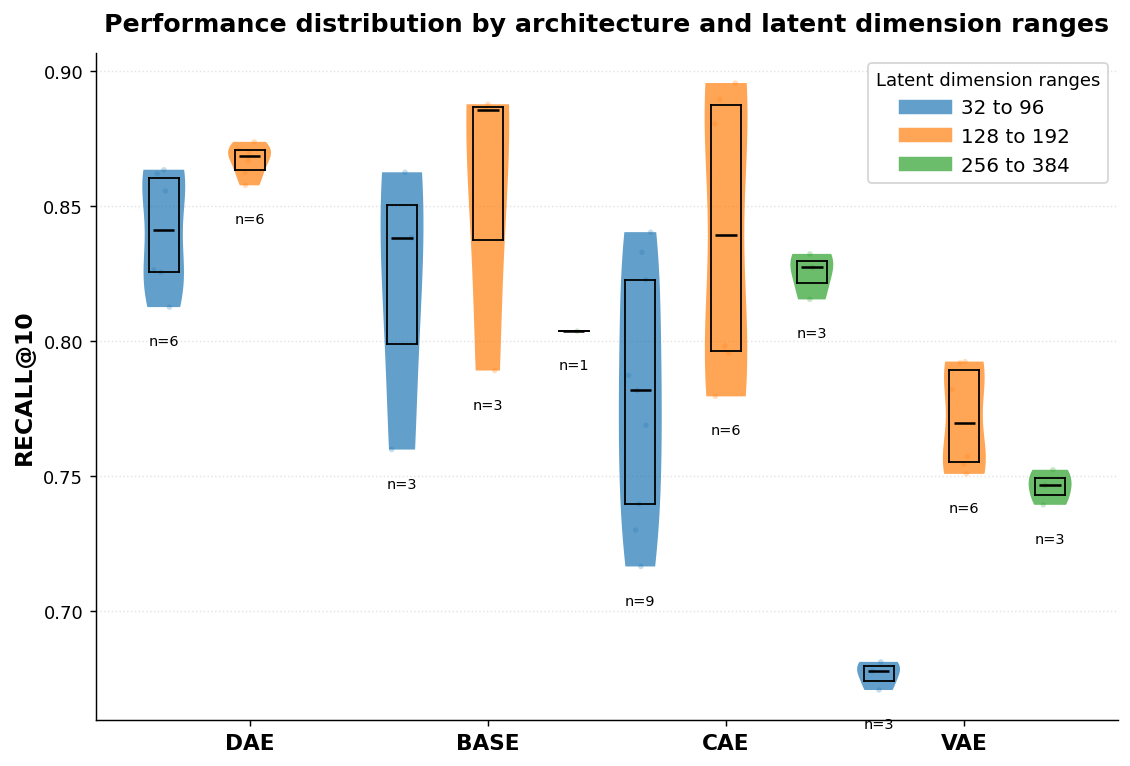

In [31]:
plot_violin_by_arch_latent_ranges(df, metric="recall@10")

### Chunking



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# =========================
# Preprocesado y utilidades
# =========================

def normalize_chunk_mode(series: pd.Series) -> pd.Series:
    """Normaliza chunk_mode:
       - NaN -> 'none'
       - Strip + lower
       - Mapea equivalentes a 'none'
       - Mantiene valores numéricos como cadenas ('128', '256', ...)
    """
    s = series.copy()
    s = s.astype(object)  # permitir mixto
    s = s.fillna("none")
    s = s.map(lambda x: str(x).strip().lower())
    none_alias = {"", "none", "false", "0", "no", "off", "nan"}
    s = s.map(lambda x: "none" if x in none_alias else x)
    # Quita posibles sufijos tipo "chunk_128" -> "128"
    s = s.map(lambda x: x.split("_")[-1] if x.startswith("chunk_") and x.split("_")[-1].isdigit() else x)
    return s

def order_chunk_modes(series: pd.Series) -> list:
    """Devuelve el orden: 'none' -> números ascendentes -> resto alfabético."""
    uniq = pd.unique(series)
    nums, others = [], []
    for v in uniq:
        try:
            nums.append(int(v))
        except ValueError:
            others.append(v)
    nums_sorted = sorted(set(nums))
    others = [o for o in others if o != "none"]
    others_sorted = sorted(set(others))
    out = ["none"] + [str(n) for n in nums_sorted] + others_sorted
    # Filtra por los que realmente existen en la serie
    present = set(uniq)
    return [m for m in out if m in present]

def prepare_df_for_chunk_plots(df: pd.DataFrame, metric="ndcg@10",
                               arch_col="arch", chunk_col="chunk_mode") -> pd.DataFrame:
    """Filtra VAE/CAE/DAE, asegura métrica numérica y añade 'chunk_mode_norm' ordenable."""
    req = [arch_col, chunk_col, metric]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns: {miss}")
    d = df[df[arch_col].isin(["VAE", "CAE", "DAE"])].copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d["chunk_mode_norm"] = normalize_chunk_mode(d[chunk_col])
    return d

# Colores consistentes por arquitectura
ARCH_COLORS = {"VAE": "#1f77b4", "CAE": "#ff7f0e", "DAE": "#2ca02c"}


# =========================
# 1) Strip plot con jitter
# =========================
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =========================
# Preprocesado y utilidades
# =========================

def normalize_chunk_mode(series: pd.Series) -> pd.Series:
    """Normaliza chunk_mode para graficado.

    Reglas:
        - NaN -> 'none'
        - strip + lower
        - Mapea equivalentes a 'none' ('false','0','off',...)
        - Convierte 'chunk_128' -> '128' cuando el sufijo es numérico
    """
    s = series.copy().astype(object)
    s = s.fillna("none")
    s = s.map(lambda x: str(x).strip().lower())
    none_alias = {"", "none", "false", "0", "no", "off", "nan"}
    s = s.map(lambda x: "none" if x in none_alias else x)
    s = s.map(lambda x: x.split("_")[-1] if x.startswith("chunk_")
              and x.split("_")[-1].isdigit() else x)
    return s


def order_chunk_modes(series: pd.Series) -> list[str]:
    """Devuelve el orden de chunking: 'none' → números ascendentes → resto alfabético."""
    uniq = pd.unique(series)
    nums, others = [], []
    for v in uniq:
        try:
            nums.append(int(v))
        except ValueError:
            others.append(v)
    nums_sorted = sorted(set(nums))
    others = [o for o in others if o != "none"]
    others_sorted = sorted(set(others))
    present = set(uniq)
    ordered = ["none"] + [str(n) for n in nums_sorted] + others_sorted
    return [m for m in ordered if m in present]


def prepare_df_for_chunk_plots(
    df: pd.DataFrame,
    metric: str = "ndcg@10",
    arch_col: str = "arch",
    chunk_col: str = "chunk_mode",
) -> pd.DataFrame:
    """Filtra VAE/CAE/DAE/BASE, fuerza métrica numérica y añade 'chunk_mode_norm'."""
    req = [arch_col, chunk_col, metric]
    miss = [c for c in req if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns: {miss}")
    d = df[df[arch_col].isin(["VAE", "CAE", "DAE", "BASE"])].copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d["chunk_mode_norm"] = normalize_chunk_mode(d[chunk_col])
    return d


# Paleta consistente por arquitectura (incluye BASE)
ARCH_COLORS = {
    "DAE":   "#1f77b4",  # azul
    "CAE":   "#ff7f0e",  # naranja
    "SBERT": "#2ca02c",  # verde
    "VAE":   "#d62728",  # rojo
    "BASE":  "#9467bd",  # morado
    "BM25":  "#8c564b",  # marrón
    "DPR":   "#e377c2",  # rosa
}



# ==============================
# Strip plot con jitter + medias
# ==============================

# ...existing code...
def plot_strip_chunking(
    df: pd.DataFrame,
    metric: str = "ndcg@10",
    arch_col: str = "arch",
    chunk_col: str = "chunk_mode_norm",
    title: str = "Dispersión de resultados por chunking y arquitectura",
) -> None:
    """Strip plot con jitter por modo de chunking y arquitectura, marcando la media.

    Args:
        df: DataFrame ya preparado (usar `prepare_df_for_chunk_plots`).
        metric: Columna de la métrica a representar (p. ej., 'ndcg@10').
        arch_col: Columna con la arquitectura ('VAE','CAE','DAE','BASE').
        chunk_col: Columna con el modo de chunking normalizado ('none','128','sliding',...).
        title: Título de la figura.
    """
    d = df.copy()

    # Orden de modos y arquitecturas presentes
    modes_order = order_chunk_modes(d[chunk_col])
    archs = [a for a in ["VAE", "CAE", "DAE", "BASE"] if a in d[arch_col].unique()]
    if not modes_order or not archs:
        raise ValueError("No hay datos suficientes para graficar.")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Desplazamiento lateral por arquitectura dentro de cada modo (centrado)
    offsets = {a: (i - (len(archs)-1)/2) * 0.18 for i, a in enumerate(archs)}

    # Para conectar las medias por arquitectura
    means_by_arch = {a: {"x": [], "y": []} for a in archs}

    for j, cmode in enumerate(modes_order):
        base_x = j
        for arch in archs:
            vals = d[(d[chunk_col] == cmode) & (d[arch_col] == arch)][metric].dropna().to_numpy()
            if vals.size == 0:
                continue
            x = base_x + offsets[arch] + 0.03 * np.random.randn(vals.size)
            ax.scatter(
                x, vals,
                color=ARCH_COLORS.get(arch, "#333333"),
                alpha=0.6, s=35
            )

            # Estadísticos
            m = float(np.mean(vals))
            sd = float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0
            x_mean = base_x + offsets[arch]

            # Barra de error (±1σ) y media (diamante)
            ax.errorbar(
                x_mean, m, yerr=sd, capsize=3,
                ecolor=ARCH_COLORS.get(arch, "#333333"),
                elinewidth=1.2, alpha=0.85, linestyle=""
            )
            ax.plot(
                x_mean, m,
                marker="D", markersize=9,
                markerfacecolor=ARCH_COLORS.get(arch, "#333333"),
                markeredgecolor="black", linestyle=""
            )

            # Acumular para línea de conexión
            means_by_arch[arch]["x"].append(x_mean)
            means_by_arch[arch]["y"].append(m)

    # Línea conectando medias por arquitectura
    for arch in archs:
        ax.plot(
            means_by_arch[arch]["x"], means_by_arch[arch]["y"],
            color=ARCH_COLORS.get(arch, "#333333"),
            linewidth=1.8, alpha=0.9
        )

    # Ejes y rejilla
    ax.set_xticks(range(len(modes_order)))
    ax.set_xticklabels(modes_order)
    ax.set_xlabel("Chunking mode")
    ax.set_ylabel(metric)
    ax.set_title(title, pad=10)
    ax.grid(True, linestyle="--", alpha=0.3, axis="y")
    ax.set_axisbelow(True)

    # ---- Leyenda (fuera, derecha) ----
    from matplotlib.lines import Line2D
    arch_handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=8,
               color=ARCH_COLORS[a], label=a)
        for a in archs
    ]
    mean_handle = Line2D(
        [0], [0], marker="D", linestyle="", markersize=8,
        markerfacecolor="white", markeredgecolor="black", label="Media"
    )
    line_handle = Line2D([0], [0], color="black", lw=1.8, label="Conexión medias")
    err_handle = Line2D([0], [0], color="black", marker="|", linestyle="", markersize=10, label="±1σ")

    ax.legend(
        handles=arch_handles + [mean_handle, line_handle, err_handle],
        title="Arquitectura / Indicador",
        frameon=True,
        ncol=1,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    # Margen para la leyenda externa
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


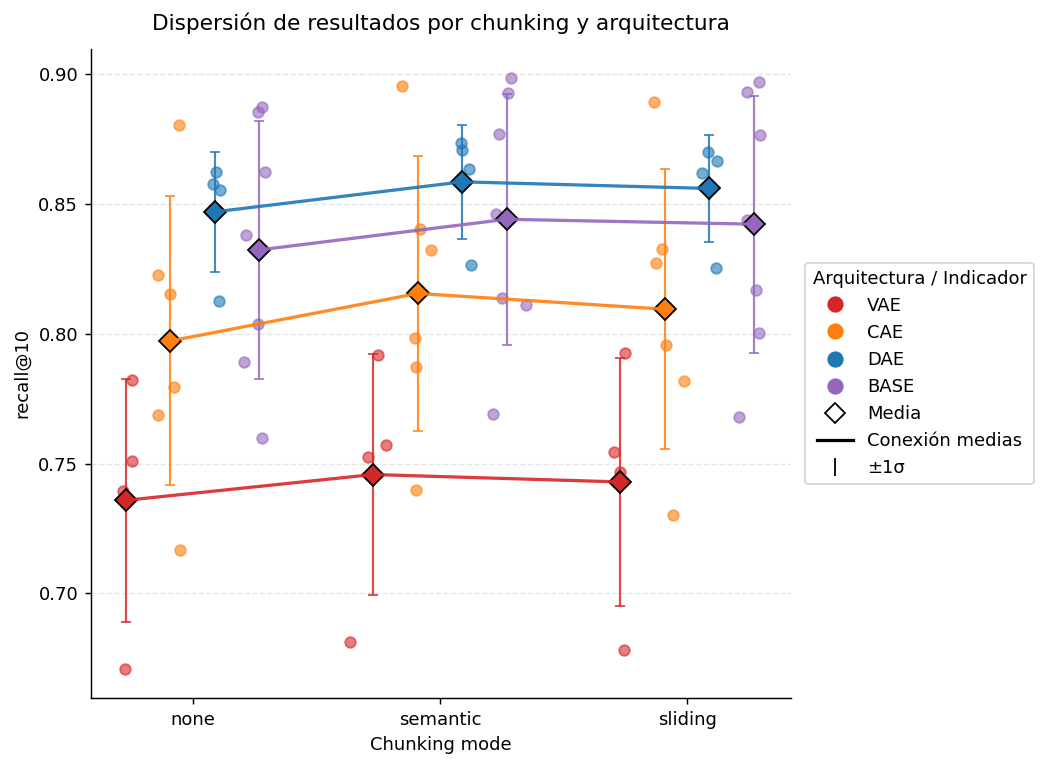

In [17]:
# 1) Prepara el DataFrame una vez
df_p = prepare_df_for_chunk_plots(df, metric="recall@10", arch_col="arch", chunk_col="chunk_mode")

# 2) Lanza las tres vistas (todas usan 'chunk_mode_norm')
plot_strip_chunking(df_p, metric="recall@10")


### Table

In [42]:

# --- Notebook cell 4: comparison table ---------------------------------------
def comparison_table(df: pd.DataFrame, top_n: Optional[int] = None) -> pd.DataFrame:
    """Build a comparison table with key metrics and Spanish headers.
       If any row has chunking_enabled == True, include chunk_mode column.
    """
    df_local = df.copy()

    # Detect whether to show chunk_mode
    show_chunk_mode = (
        "chunking_enabled" in df_local.columns
        and df_local["chunking_enabled"].astype(str).str.lower().eq("true").any()
        and "chunk_mode" in df_local.columns
    )

    base_cols = [
        "method_label", "arch", "latent_dim",
        "recall@10", "mrr@10", "ndcg@10",
        "qps", "storage_saving_pct", "compression_factor_real", "perf_score"
    ]
    if show_chunk_mode:
        # Insert chunk_mode just after latent_dim
        cols = ["method_label", "arch", "latent_dim", "chunk_mode"] + base_cols[3:]
    else:
        cols = base_cols

    present = [c for c in cols if c in df_local.columns]
    tab = df_local[present].copy()

    # Sort by main retrieval quality (nDCG@10) descending, then by QPS
    sort_cols = [c for c in ["ndcg@10", "qps"] if c in tab.columns]
    if sort_cols:
        tab = tab.sort_values(sort_cols, ascending=[False] * len(sort_cols))

    if top_n is not None:
        tab = tab.head(int(top_n))

    # Rounding
    round_map = {
        "recall@10": 3, "mrr@10": 3, "ndcg@10": 3,
        "qps": 3, "storage_saving_pct": 1,
        "compression_factor_real": 2, "perf_score": 3
    }
    for c, r in round_map.items():
        if c in tab.columns:
            tab[c] = pd.to_numeric(tab[c], errors="coerce").round(r)

    # Renames
    rename = {
        "method_label": "Método",
        "arch": "Tipo",
        "latent_dim": "Dim",
        "chunk_mode": "Modo Chunk",
        "recall@10": "Recall@10",
        "mrr@10": "MRR@10",
        "ndcg@10": "nDCG@10",
        "qps": "QPS",
        "storage_saving_pct": "Ahorro Storage (%)",
        "compression_factor_real": "Factor Compresión (×)",
        "perf_score": "Rendimiento (media 3 métricas)"
    }
    tab = tab.rename(columns=rename)

    # Column order
    desired = [
        "Método", "Tipo", "Dim"
    ]
    if show_chunk_mode:
        desired.append("Modo Chunk")
    desired += [
        "Recall@10", "MRR@10", "nDCG@10",
        "Rendimiento (media 3 métricas)", "QPS",
        "Ahorro Storage (%)", "Factor Compresión (×)"
    ]
    tab = tab[[c for c in desired if c in tab.columns]]

    return tab

# Default (chunking disabled)
tabla = comparison_table(df[df['chunking_enabled'] == "False"], top_n=None)
display(tabla)
tabla.to_excel("comparison_table_no_chunking.xlsx", index=False)




,Método,Tipo,Dim,Recall@10,MRR@10,nDCG@10,Rendimiento (media 3 métricas),QPS,Ahorro Storage (%),Factor Compresión (×)
10,SBERT-384,SBERT,384,0.917,0.727,0.773,0.806,30043.616,0.0,1.00
50,BASE,BASE,192,0.888,0.676,0.728,0.764,62462.439,50.0,2.00
48,BASE,BASE,128,0.886,0.668,0.721,0.758,83129.515,66.7,3.00
7,CAE-lat160,CAE,160,0.880,0.664,0.716,0.753,71530.225,58.3,2.40
11,BM25,BM25,384,0.829,0.679,0.715,0.741,NaN,0.0,1.00
47,BASE,BASE,96,0.862,0.639,0.693,0.731,105215.940,75.0,4.00
3,DAE-lat192,DAE,192,0.862,0.628,0.685,0.725,60888.765,50.0,2.00
2,DAE-lat128,DAE,128,0.858,0.624,0.681,0.721,84828.209,66.7,3.00
1,DAE-lat96,DAE,96,0.856,0.619,0.676,0.717,116829.144,75.0,4.00
46,BASE,BASE,64,0.838,0.592,0.652,0.694,141722.109,83.3,6.00


In [43]:
display(tabla)

,Método,Tipo,Dim,Recall@10,MRR@10,nDCG@10,Rendimiento (media 3 métricas),QPS,Ahorro Storage (%),Factor Compresión (×)
10,SBERT-384,SBERT,384,0.917,0.727,0.773,0.806,30043.616,0.0,1.00
50,BASE,BASE,192,0.888,0.676,0.728,0.764,62462.439,50.0,2.00
48,BASE,BASE,128,0.886,0.668,0.721,0.758,83129.515,66.7,3.00
7,CAE-lat160,CAE,160,0.880,0.664,0.716,0.753,71530.225,58.3,2.40
11,BM25,BM25,384,0.829,0.679,0.715,0.741,NaN,0.0,1.00
47,BASE,BASE,96,0.862,0.639,0.693,0.731,105215.940,75.0,4.00
3,DAE-lat192,DAE,192,0.862,0.628,0.685,0.725,60888.765,50.0,2.00
2,DAE-lat128,DAE,128,0.858,0.624,0.681,0.721,84828.209,66.7,3.00
1,DAE-lat96,DAE,96,0.856,0.619,0.676,0.717,116829.144,75.0,4.00
46,BASE,BASE,64,0.838,0.592,0.652,0.694,141722.109,83.3,6.00


In [44]:

tabla = comparison_table(df[df['chunking_enabled'] == "True"], top_n=None)
tabla

tabla.to_excel("comparison_table_chunking.xlsx", index=False)